# 05 — Modelling

**Sources:** `modelling_experiment.ipynb` + `Jos EBM.ipynb` (EBM sections) + `Models Yvonne incl saved rf tuned.ipynb`

In [3]:
# Important libraries for train-test split and data manipulation

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Iterative imputer for handling missing values
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_squared_error

# Encoded data

In [4]:
# Load encoded data

X_train_final_encoded = pd.read_parquet('../data/cleaned/X_train_encoded_wo_provider.parquet')
y_train = pd.read_parquet('../data/cleaned/y_train.parquet').squeeze()
print("✓ Encoded data loaded successfully")

✓ Encoded data loaded successfully


In [5]:
X_train_final_encoded.head(5)

,gender,t0_assisted,t0_assisted_by,t0_symptom_period,t0_previous_surgery,t0_disability,heart_disease,high_bp,stroke,circulation,...,t0_living_arrangements_2.0,t0_living_arrangements_4.0,Region_East of England,Region_London,Region_North East,Region_North West,Region_South East,Region_South West,Region_West Midlands,Region_Yorkshire and The Humber
0,0.0,0.0,0,2.0,0.0,0.0,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0,2.0,0.0,0.0,0,0,0,0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0,3.0,0.0,1.0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0,2.0,0.0,0.0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0,2.0,0.0,0.0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [6]:
X_train_final_encoded.columns.tolist()

['gender',
 't0_assisted',
 't0_assisted_by',
 't0_symptom_period',
 't0_previous_surgery',
 't0_disability',
 'heart_disease',
 'high_bp',
 'stroke',
 'circulation',
 'lung_disease',
 'diabetes',
 'kidney_disease',
 'nervous_system',
 'liver_disease',
 'cancer',
 'depression',
 'arthritis',
 't0_mobility',
 't0_self_care',
 't0_activity',
 't0_discomfort',
 't0_anxiety',
 'oks_t0_pain',
 'oks_t0_night_pain',
 'oks_t0_washing',
 'oks_t0_transport',
 'oks_t0_walking',
 'oks_t0_standing',
 'oks_t0_limping',
 'oks_t0_kneeling',
 'oks_t0_work',
 'oks_t0_confidence',
 'oks_t0_shopping',
 'oks_t0_stairs',
 'oks_t0_score',
 'University Hospital',
 'independent_hospital',
 'comorbidity_count',
 'oks_pain_subscale',
 'oks_function_subscale',
 'oks_adl_subscale',
 'year_2017/18',
 'year_2018/19',
 'age_band_3',
 'age_band_4',
 'age_band_5',
 't0_living_arrangements_2.0',
 't0_living_arrangements_4.0',
 'Region_East of England',
 'Region_London',
 'Region_North East',
 'Region_North West',
 'Regi

# Logistic Regression Testing 

RUNNING ALL MODEL CONFIGURATIONS

▶ Training: LR - No weights...
  ✓ Val PR-AUC: 0.3727 | Gap: 0.0017 | Features: 56

▶ Training: LR - Balanced weights...
  ✓ Val PR-AUC: 0.3700 | Gap: 0.0015 | Features: 56

▶ Training: LR - SMOTE...
  ✓ Val PR-AUC: 0.3701 | Gap: 0.0017 | Features: 56

▶ Training: LR - LASSO (L1)...
  ✓ Val PR-AUC: 0.3728 | Gap: 0.0017 | Features: 54

▶ Training: LR - LASSO + Balanced...
  ✓ Val PR-AUC: 0.3701 | Gap: 0.0015 | Features: 54

OVERFITTING ANALYSIS (@ Threshold=0.5)
                       train_precision  val_precision  precision_gap  train_recall  val_recall  recall_gap overfit_flag
LR - No weights                 0.6552         0.6607        -0.0056        0.0800      0.0804     -0.0004         ✓ OK
LR - Balanced weights           0.2895         0.2883         0.0012        0.6061      0.6031      0.0030         ✓ OK
LR - SMOTE                      0.6457         0.6485        -0.0028        0.0808      0.0816     -0.0008         ✓ OK
LR - LASSO (L1)     

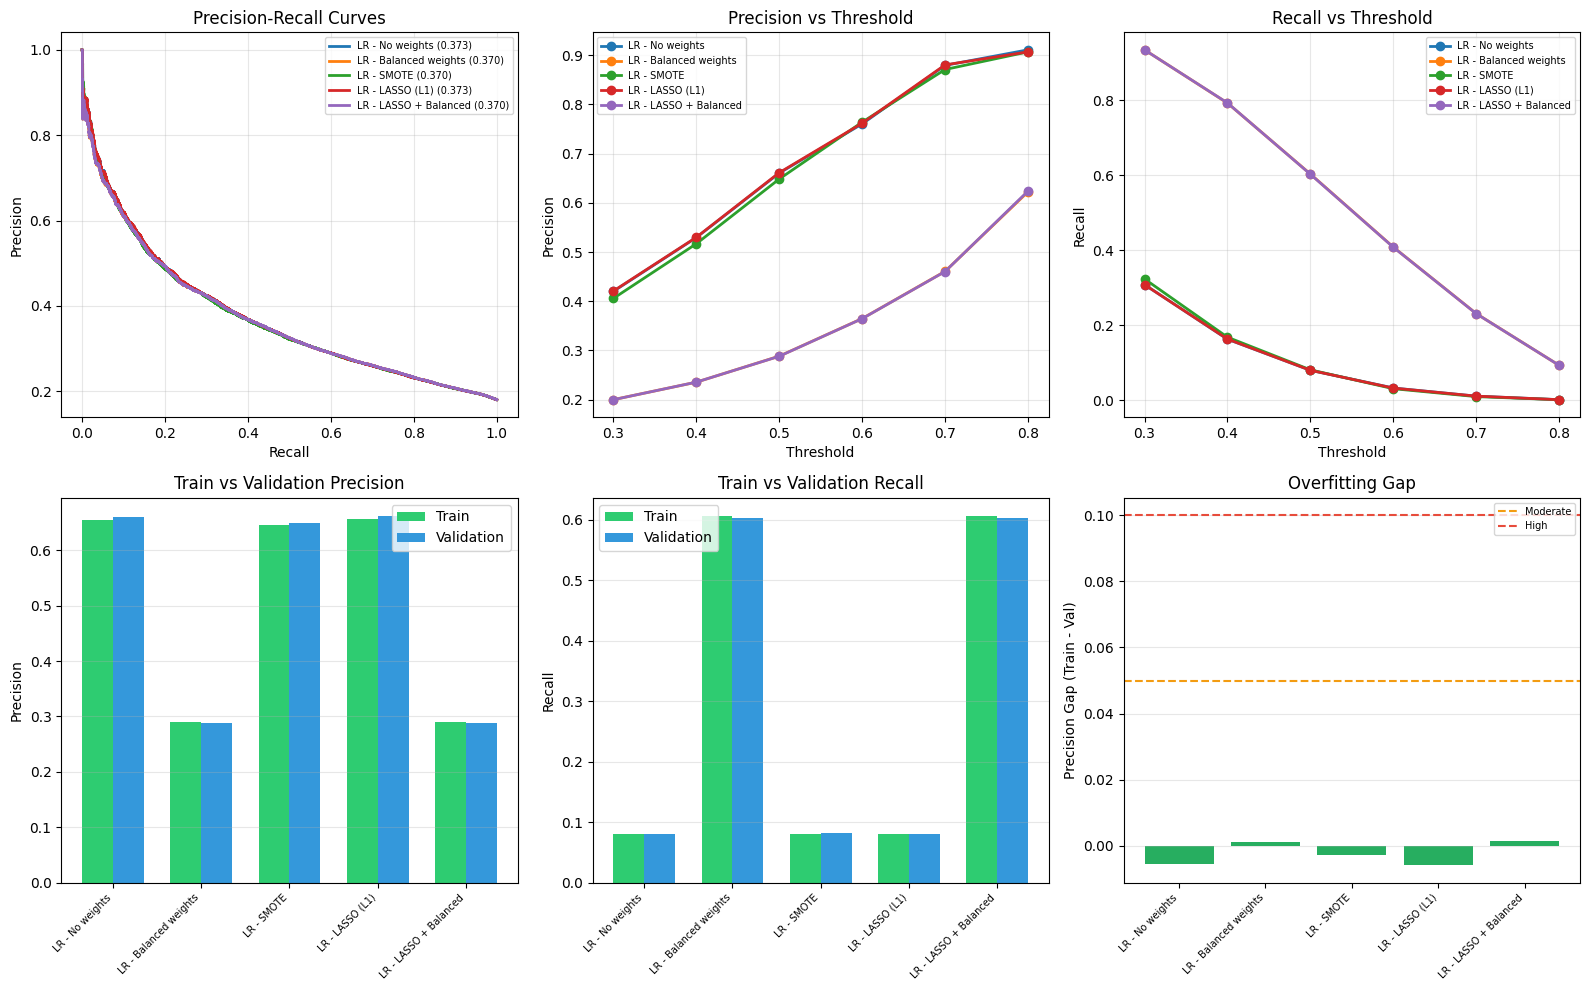

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, auc
from sklearn.base import clone
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define model configurations
models = {
    'LR - No weights': LogisticRegression(
        max_iter=1000, random_state=42, solver='lbfgs', n_jobs=-1
    ),
    'LR - Balanced weights': LogisticRegression(
        max_iter=1000, random_state=42, solver='lbfgs', n_jobs=-1, class_weight='balanced'
    ),
    'LR - SMOTE': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('lr', LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs', n_jobs=-1))
    ]),
    'LR - LASSO (L1)': LogisticRegression(
        max_iter=1000, random_state=42, solver='saga', penalty='l1', n_jobs=-1
    ),
    'LR - LASSO + Balanced': LogisticRegression(
        max_iter=1000, random_state=42, solver='saga', penalty='l1', n_jobs=-1, class_weight='balanced'
    ),
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

# Store results
results = {}
overfit_results = {}
proba_dict = {}
feature_importance_dict = {}

# Feature names
feature_names = X_train_final_encoded.columns.tolist()

print("=" * 80)
print("RUNNING ALL MODEL CONFIGURATIONS")
print("=" * 80)

for name, model in models.items():
    print(f"\n▶ Training: {name}...")
    
    # Storage for cross-validation
    val_probas = np.zeros(len(y_train))
    train_precisions, val_precisions = [], []
    train_recalls, val_recalls = [], []
    train_pr_aucs, val_pr_aucs = [], []
    fold_coefs = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train_final_encoded, y_train)):
        X_tr, X_val = X_train_final_encoded.iloc[train_idx], X_train_final_encoded.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        # Clone and fit model
        model_clone = clone(model)
        model_clone.fit(X_tr, y_tr)
        
        # Extract coefficients
        if hasattr(model_clone, 'coef_'):
            fold_coefs.append(model_clone.coef_[0])
        elif hasattr(model_clone, 'named_steps'):
            fold_coefs.append(model_clone.named_steps['lr'].coef_[0])
        
        # Get probabilities
        train_proba = model_clone.predict_proba(X_tr)[:, 1]
        val_proba = model_clone.predict_proba(X_val)[:, 1]
        val_probas[val_idx] = val_proba
        
        # Metrics at threshold=0.5
        train_pred = (train_proba >= 0.5).astype(int)
        val_pred = (val_proba >= 0.5).astype(int)
        
        train_precisions.append(precision_score(y_tr, train_pred, zero_division=0))
        val_precisions.append(precision_score(y_val, val_pred, zero_division=0))
        train_recalls.append(recall_score(y_tr, train_pred, zero_division=0))
        val_recalls.append(recall_score(y_val, val_pred, zero_division=0))
        
        # PR-AUC
        prec_tr, rec_tr, _ = precision_recall_curve(y_tr, train_proba)
        prec_val, rec_val, _ = precision_recall_curve(y_val, val_proba)
        train_pr_aucs.append(auc(rec_tr, prec_tr))
        val_pr_aucs.append(auc(rec_val, prec_val))
    
    proba_dict[name] = val_probas
    
    # Average coefficients across folds
    avg_coefs = np.mean(fold_coefs, axis=0)
    feature_importance_dict[name] = pd.DataFrame({
        'feature': feature_names,
        'coefficient': avg_coefs,
        'abs_importance': np.abs(avg_coefs)
    }).sort_values('abs_importance', ascending=False)
    
    # Store metrics
    overfit_results[name] = {
        'train_precision': np.mean(train_precisions),
        'val_precision': np.mean(val_precisions),
        'precision_gap': np.mean(train_precisions) - np.mean(val_precisions),
        'train_recall': np.mean(train_recalls),
        'val_recall': np.mean(val_recalls),
        'recall_gap': np.mean(train_recalls) - np.mean(val_recalls),
        'train_pr_auc': np.mean(train_pr_aucs),
        'val_pr_auc': np.mean(val_pr_aucs),
        'pr_auc_gap': np.mean(train_pr_aucs) - np.mean(val_pr_aucs),
        'n_nonzero_features': np.sum(np.abs(avg_coefs) > 1e-6)
    }
    
    # Metrics at each threshold
    model_results = []
    for thresh in thresholds:
        y_pred = (val_probas >= thresh).astype(int)
        model_results.append({
            'threshold': thresh,
            'precision': precision_score(y_train, y_pred, zero_division=0),
            'recall': recall_score(y_train, y_pred, zero_division=0),
            'f1': f1_score(y_train, y_pred, zero_division=0),
            'n_predicted_pos': y_pred.sum()
        })
    
    results[name] = pd.DataFrame(model_results)
    print(f"  ✓ Val PR-AUC: {overfit_results[name]['val_pr_auc']:.4f} | Gap: {overfit_results[name]['pr_auc_gap']:.4f} | Features: {overfit_results[name]['n_nonzero_features']}")

# === OVERFITTING TABLE ===
print("\n" + "=" * 80)
print("OVERFITTING ANALYSIS (@ Threshold=0.5)")
print("=" * 80)

overfit_df = pd.DataFrame(overfit_results).T
overfit_df['overfit_flag'] = overfit_df['precision_gap'].apply(
    lambda x: '⚠️ HIGH' if x > 0.1 else ('⚡ MOD' if x > 0.05 else '✓ OK')
)
print(overfit_df[['train_precision', 'val_precision', 'precision_gap', 
                   'train_recall', 'val_recall', 'recall_gap', 'overfit_flag']].round(4).to_string())

# === THRESHOLD TABLES ===
print("\n" + "=" * 80)
print("VALIDATION PRECISION ACROSS THRESHOLDS")
print("=" * 80)

comparison_df = pd.DataFrame()
for name, df in results.items():
    comparison_df[name] = df.set_index('threshold')['precision']
print(comparison_df.round(4).to_string())

print("\n" + "=" * 80)
print("VALIDATION RECALL ACROSS THRESHOLDS")
print("=" * 80)

recall_df = pd.DataFrame()
for name, df in results.items():
    recall_df[name] = df.set_index('threshold')['recall']
print(recall_df.round(4).to_string())

# === FEATURE IMPORTANCE FOR EACH MODEL ===
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE (TOP 15 PER MODEL)")
print("=" * 80)

for name, fi_df in feature_importance_dict.items():
    print(f"\n{'─' * 60}")
    print(f"📊 {name}")
    print(f"{'─' * 60}")
    top_15 = fi_df.head(15).reset_index(drop=True)
    top_15.index = top_15.index + 1  # Start from 1
    print(top_15[['feature', 'coefficient', 'abs_importance']].to_string())
    
    if 'LASSO' in name:
        n_zero = (fi_df['abs_importance'] < 1e-6).sum()
        n_kept = len(fi_df) - n_zero
        print(f"\n  → LASSO kept {n_kept}/{len(fi_df)} features (eliminated {n_zero})")

# === PLOTS ===
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: PR Curves
ax1 = axes[0, 0]
for name, y_proba in proba_dict.items():
    prec_curve, rec_curve, _ = precision_recall_curve(y_train, y_proba)
    pr_auc = auc(rec_curve, prec_curve)
    ax1.plot(rec_curve, prec_curve, label=f'{name} ({pr_auc:.3f})', linewidth=2)
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curves')
ax1.legend(loc='best', fontsize=7)
ax1.grid(True, alpha=0.3)

# Plot 2: Precision vs Threshold
ax2 = axes[0, 1]
for name, df in results.items():
    ax2.plot(df['threshold'], df['precision'], marker='o', label=name, linewidth=2)
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Precision')
ax2.set_title('Precision vs Threshold')
ax2.legend(loc='best', fontsize=7)
ax2.grid(True, alpha=0.3)

# Plot 3: Recall vs Threshold
ax3 = axes[0, 2]
for name, df in results.items():
    ax3.plot(df['threshold'], df['recall'], marker='o', label=name, linewidth=2)
ax3.set_xlabel('Threshold')
ax3.set_ylabel('Recall')
ax3.set_title('Recall vs Threshold')
ax3.legend(loc='best', fontsize=7)
ax3.grid(True, alpha=0.3)

# Plot 4: Train vs Val Precision
ax4 = axes[1, 0]
x_pos = np.arange(len(overfit_results))
width = 0.35
train_prec = [v['train_precision'] for v in overfit_results.values()]
val_prec = [v['val_precision'] for v in overfit_results.values()]
ax4.bar(x_pos - width/2, train_prec, width, label='Train', color='#2ecc71')
ax4.bar(x_pos + width/2, val_prec, width, label='Validation', color='#3498db')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(list(overfit_results.keys()), rotation=45, ha='right', fontsize=7)
ax4.set_ylabel('Precision')
ax4.set_title('Train vs Validation Precision')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Plot 5: Train vs Val Recall
ax5 = axes[1, 1]
train_rec = [v['train_recall'] for v in overfit_results.values()]
val_rec = [v['val_recall'] for v in overfit_results.values()]
ax5.bar(x_pos - width/2, train_rec, width, label='Train', color='#2ecc71')
ax5.bar(x_pos + width/2, val_rec, width, label='Validation', color='#3498db')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(list(overfit_results.keys()), rotation=45, ha='right', fontsize=7)
ax5.set_ylabel('Recall')
ax5.set_title('Train vs Validation Recall')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# Plot 6: Overfitting Gap
ax6 = axes[1, 2]
gaps = [v['precision_gap'] for v in overfit_results.values()]
colors = ['#e74c3c' if g > 0.1 else '#f39c12' if g > 0.05 else '#27ae60' for g in gaps]
ax6.bar(x_pos, gaps, color=colors)
ax6.axhline(y=0.05, color='#f39c12', linestyle='--', label='Moderate')
ax6.axhline(y=0.1, color='#e74c3c', linestyle='--', label='High')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(list(overfit_results.keys()), rotation=45, ha='right', fontsize=7)
ax6.set_ylabel('Precision Gap (Train - Val)')
ax6.set_title('Overfitting Gap')
ax6.legend(fontsize=7)
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

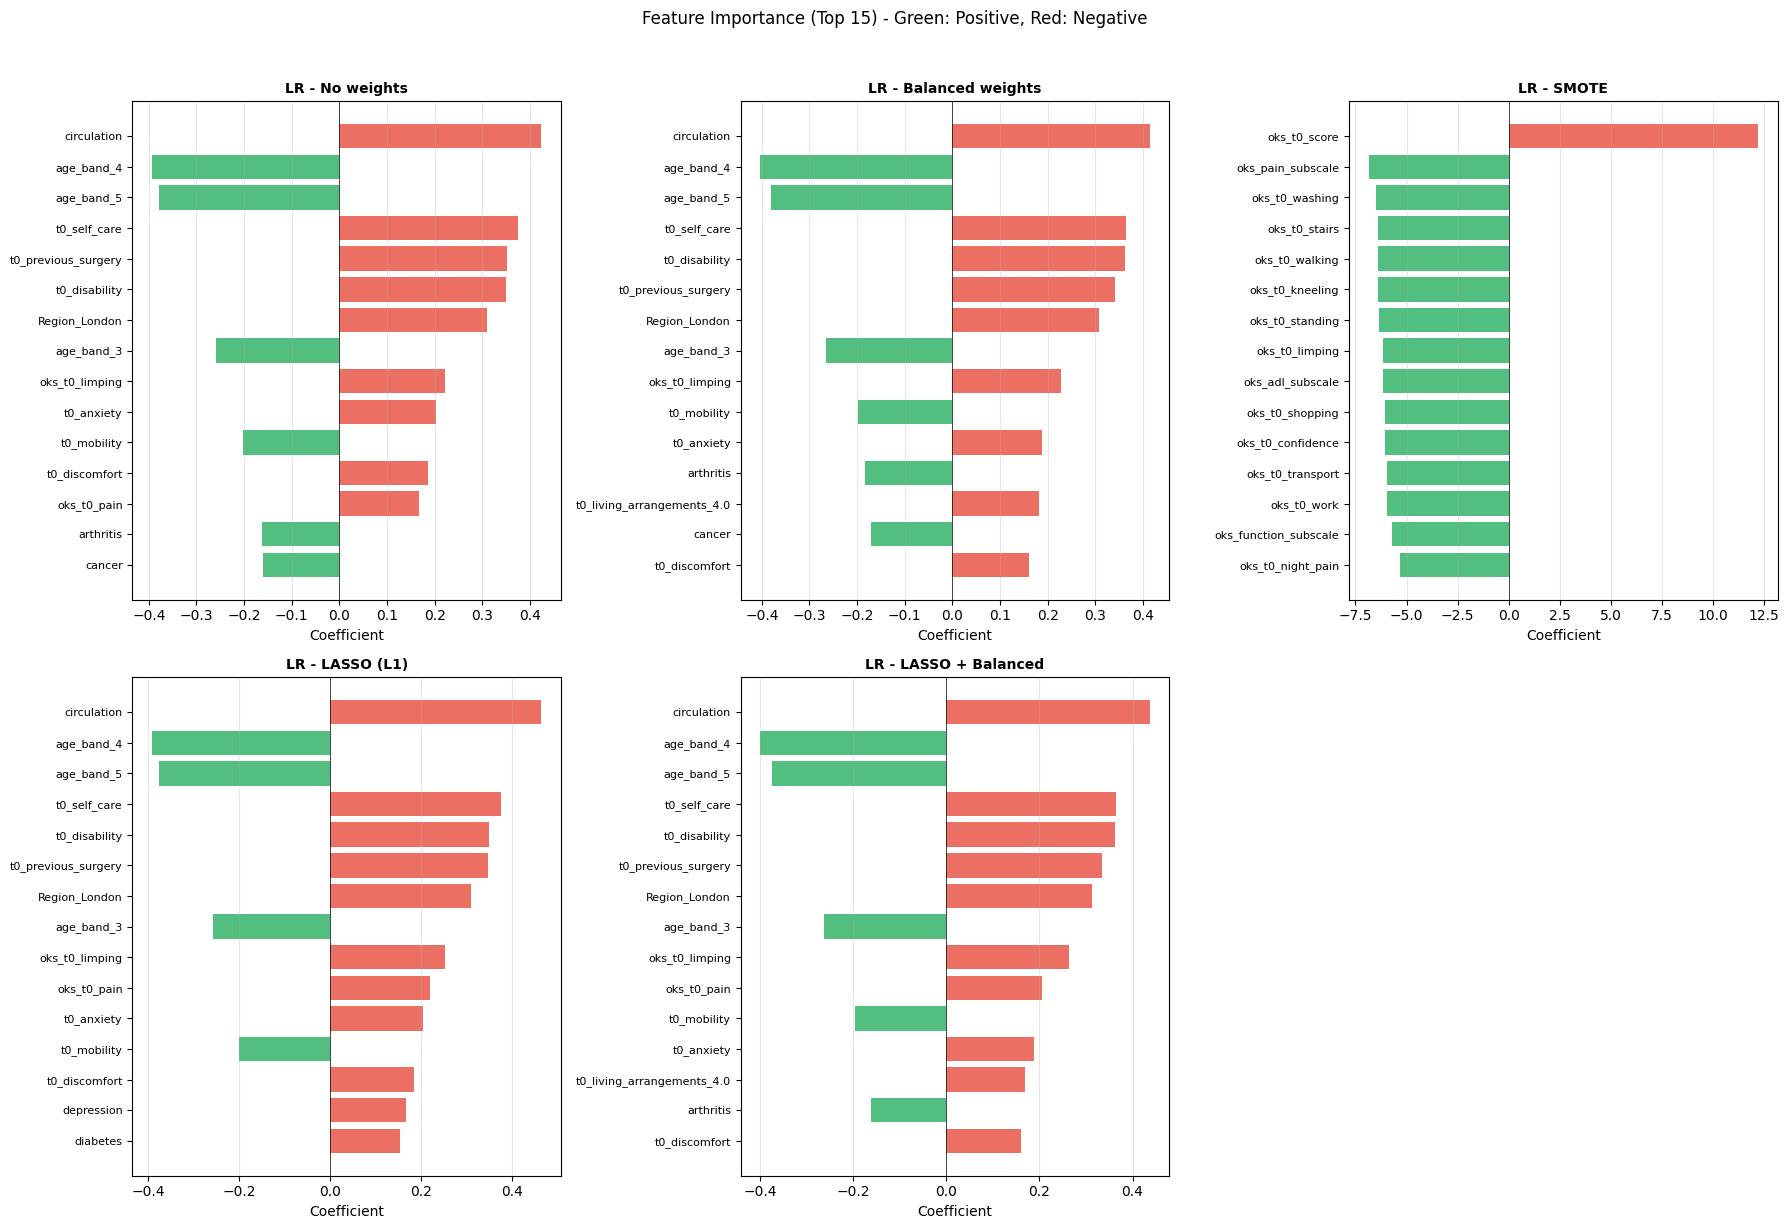


SUMMARY

Best Precision at each threshold:
  0.3: LR - LASSO (L1) → 0.4206
  0.4: LR - LASSO (L1) → 0.5298
  0.5: LR - LASSO (L1) → 0.6612
  0.6: LR - SMOTE → 0.7640
  0.7: LR - LASSO (L1) → 0.8805
  0.8: LR - No weights → 0.9111

Lowest Overfitting Risk:
  LR - LASSO (L1): gap=-0.0059
  LR - No weights: gap=-0.0056
  LR - SMOTE: gap=-0.0028


In [9]:
# === FEATURE IMPORTANCE PLOTS ===
n_models = len(feature_importance_dict)
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 12))
axes2 = axes2.flatten()

for idx, (name, fi_df) in enumerate(feature_importance_dict.items()):
    ax = axes2[idx]
    top_15 = fi_df.head(15)
    colors = ['#27ae60' if c < 0 else '#e74c3c' for c in top_15['coefficient']]
    y_pos = np.arange(len(top_15))
    ax.barh(y_pos, top_15['coefficient'], color=colors, alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_15['feature'], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Coefficient')
    ax.set_title(f'{name}', fontsize=10, fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.grid(True, alpha=0.3, axis='x')

axes2[5].axis('off')  # Hide empty subplot
plt.suptitle('Feature Importance (Top 15) - Green: Positive, Red: Negative', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# === SUMMARY ===
print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)

print("\nBest Precision at each threshold:")
for thresh in thresholds:
    best_model = comparison_df.loc[thresh].idxmax()
    best_prec = comparison_df.loc[thresh].max()
    print(f"  {thresh}: {best_model} → {best_prec:.4f}")

print("\nLowest Overfitting Risk:")
sorted_by_gap = sorted(overfit_results.items(), key=lambda x: x[1]['precision_gap'])
for name, m in sorted_by_gap[:3]:
    print(f"  {name}: gap={m['precision_gap']:.4f}")


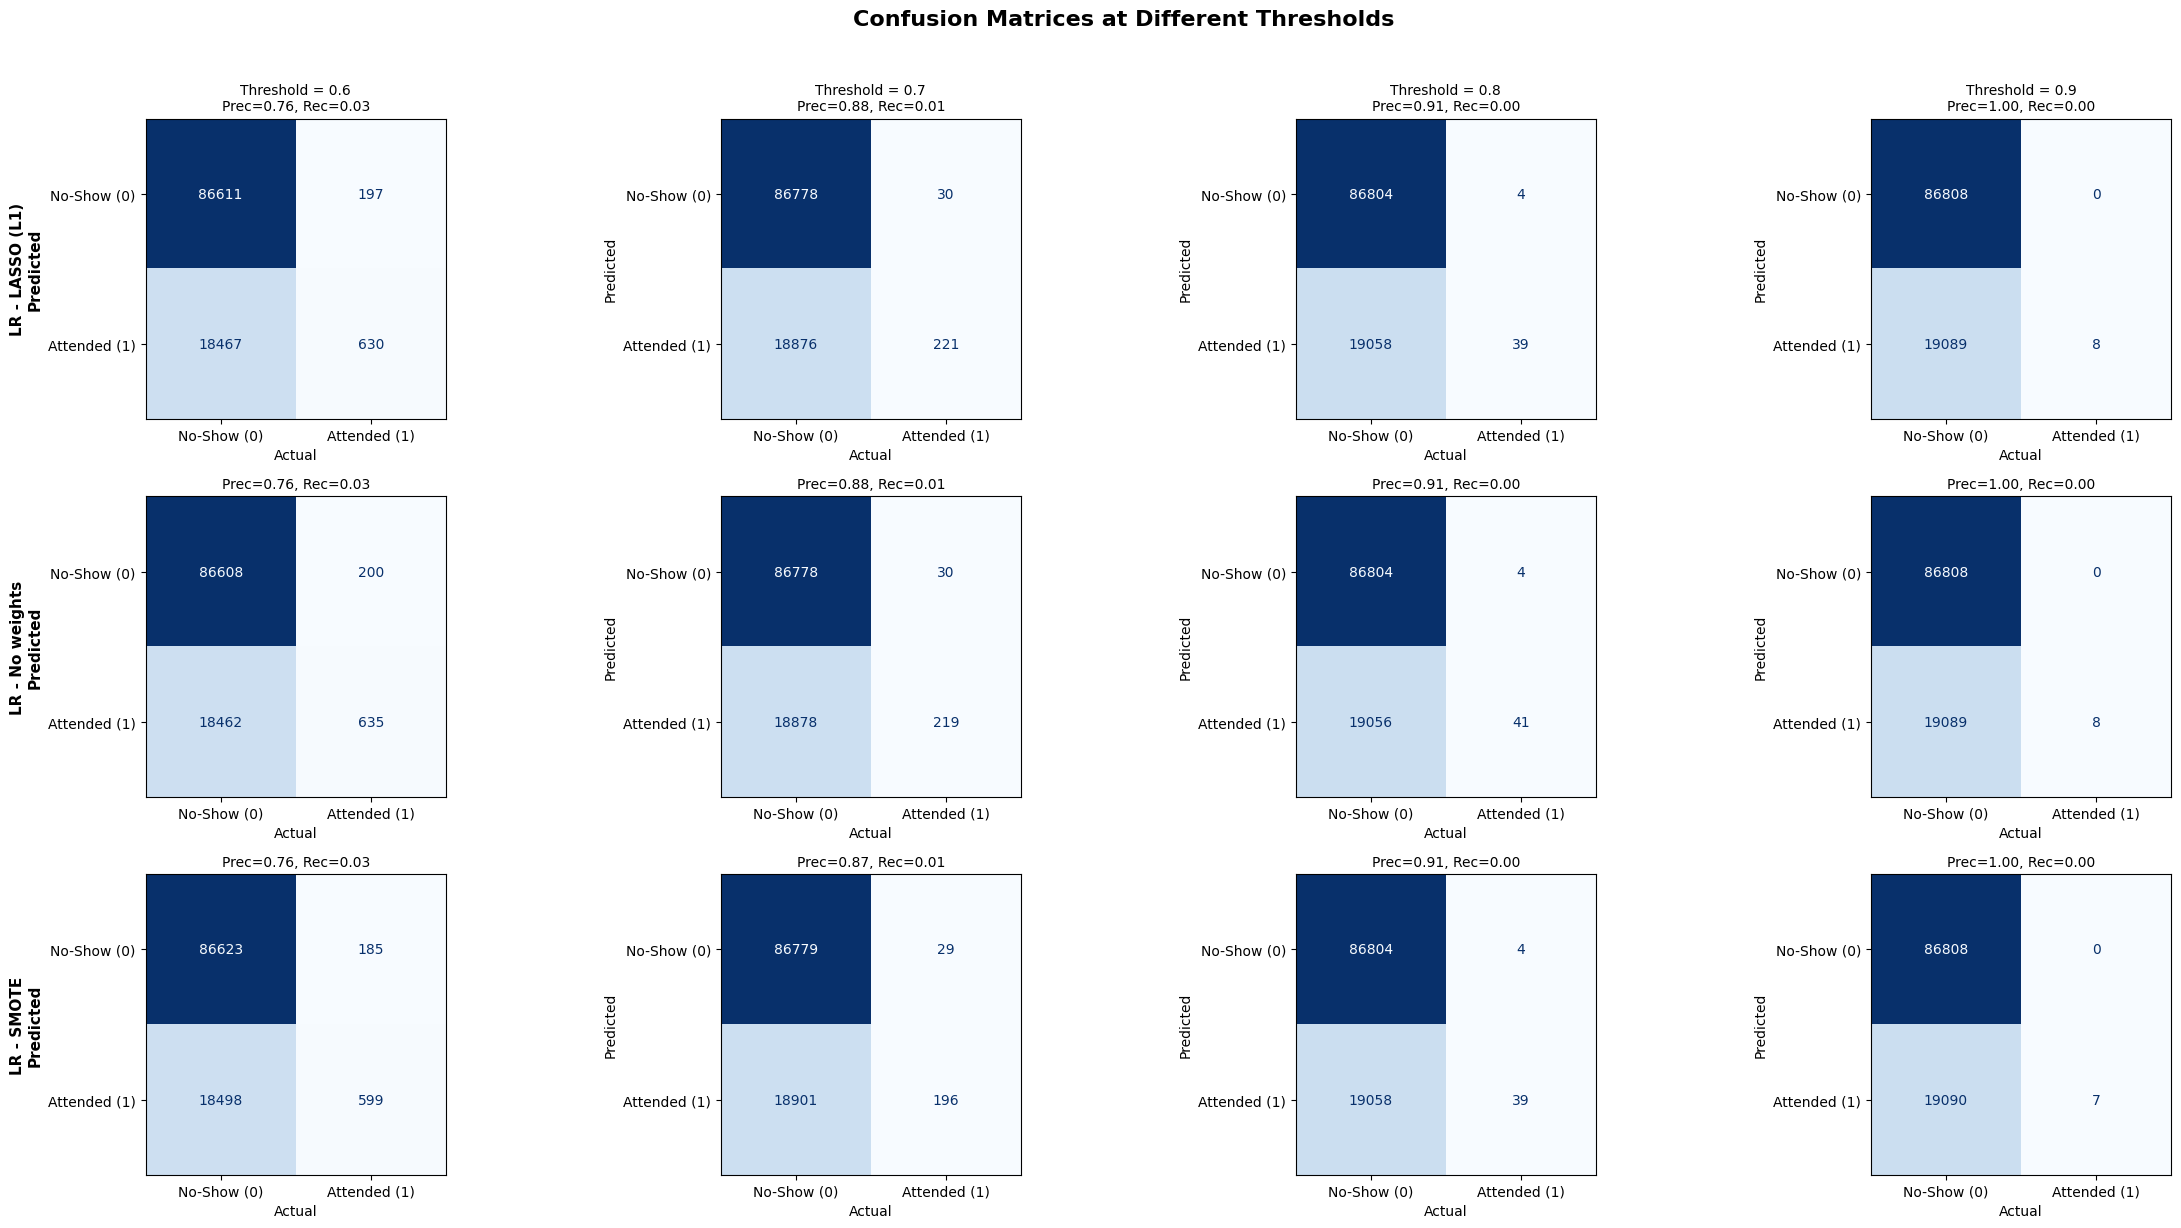


SUMMARY: Confusion Matrix Metrics at Different Thresholds

📊 LR - LASSO (L1)
----------------------------------------------------------------------
Threshold          TN       FP       FN       TP  Precision     Recall  Specificity
----------------------------------------------------------------------
0.6            86,611      197   18,467      630     0.7618     0.0330       0.9977
0.7            86,778       30   18,876      221     0.8805     0.0116       0.9997
0.8            86,804        4   19,058       39     0.9070     0.0020       1.0000
0.9            86,808        0   19,089        8     1.0000     0.0004       1.0000

📊 LR - No weights
----------------------------------------------------------------------
Threshold          TN       FP       FN       TP  Precision     Recall  Specificity
----------------------------------------------------------------------
0.6            86,608      200   18,462      635     0.7605     0.0333       0.9977
0.7            86,778       30 

In [10]:
# Create confusion matrix at different thresholds for the these models: LR - LASSO (L1), LR - No weights, LR - SMOTE

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Models to analyze
selected_models = ['LR - LASSO (L1)', 'LR - No weights', 'LR - SMOTE']

# Thresholds to evaluate
thresholds = [0.6, 0.7, 0.8, 0.9]

# Create figure with subplots: rows = models, columns = thresholds
fig, axes = plt.subplots(len(selected_models), len(thresholds), figsize=(24, 12))
fig.suptitle('Confusion Matrices at Different Thresholds', fontsize=16, fontweight='bold', y=1.02)

for row, model_name in enumerate(selected_models):
    if model_name not in proba_dict:
        print(f"Warning: {model_name} not found in proba_dict")
        continue
    
    probas = proba_dict[model_name]
    
    for col, thresh in enumerate(thresholds):
        # Convert probabilities to predictions at this threshold
        y_pred = (probas >= thresh).astype(int)
        
        # Calculate confusion matrix
        cm = confusion_matrix(y_train, y_pred)
        
        # Plot confusion matrix
        ax = axes[row, col]
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No-Show (0)', 'Attended (1)'])
        disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
        
        # Calculate metrics for title
        tn, fp, fn, tp = cm.ravel()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        if row == 0:
            ax.set_title(f'Threshold = {thresh}\nPrec={precision:.2f}, Rec={recall:.2f}', fontsize=10)
        else:
            ax.set_title(f'Prec={precision:.2f}, Rec={recall:.2f}', fontsize=10)
        
        if col == 0:
            ax.set_ylabel(f'{model_name}\nPredicted', fontsize=11, fontweight='bold')
        else:
            ax.set_ylabel('Predicted')
        
        ax.set_xlabel('Actual')

plt.tight_layout()
#plt.savefig('../outputs/confusion_matrices_thresholds.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("SUMMARY: Confusion Matrix Metrics at Different Thresholds")
print("="*80)

# Print summary table
for model_name in selected_models:
    if model_name not in proba_dict:
        continue
    
    print(f"\n📊 {model_name}")
    print("-" * 70)
    print(f"{'Threshold':<12} {'TN':>8} {'FP':>8} {'FN':>8} {'TP':>8} {'Precision':>10} {'Recall':>10} {'Specificity':>12}")
    print("-" * 70)
    
    probas = proba_dict[model_name]
    
    for thresh in thresholds:
        y_pred = (probas >= thresh).astype(int)
        cm = confusion_matrix(y_train, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        print(f"{thresh:<12.1f} {tn:>8,} {fp:>8,} {fn:>8,} {tp:>8,} {precision:>10.4f} {recall:>10.4f} {specificity:>12.4f}")


# LR On Test Set

Test set: 26,477 samples | Positive rate: 0.180
Trained: LR - No weights
Trained: LR - LASSO (L1)
Trained: LR - SMOTE


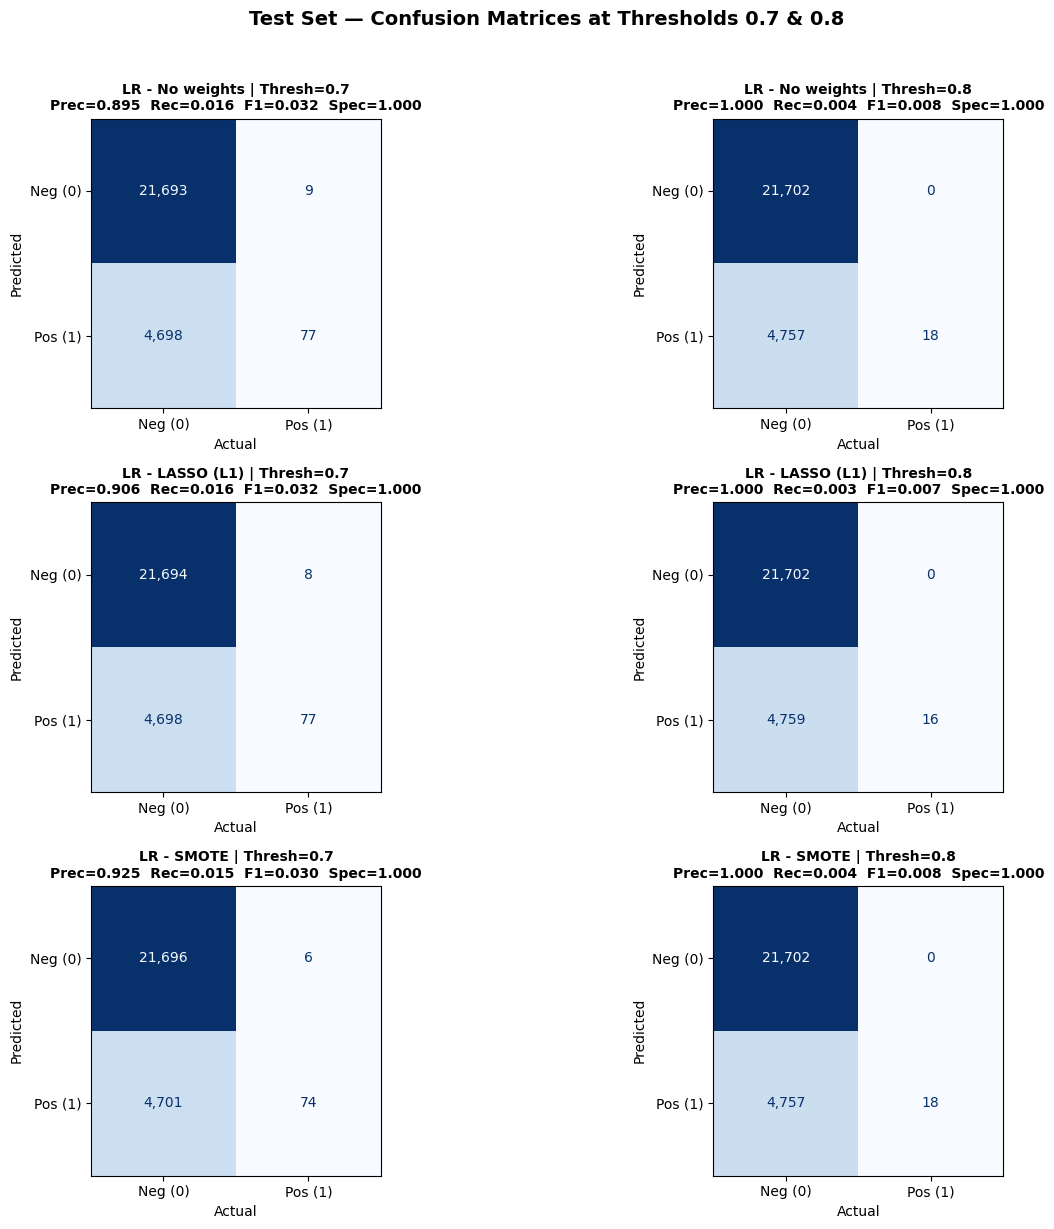


TEST SET METRICS SUMMARY

──────────────────────────────────────────────────────────────────────
  LR - No weights
──────────────────────────────────────────────────────────────────────
  Threshold         TN      FP      FN      TP     Prec   Recall       F1     Spec
  0.7           21,693       9   4,698      77   0.8953   0.0161   0.0317   0.9996
  0.8           21,702       0   4,757      18   1.0000   0.0038   0.0075   1.0000

──────────────────────────────────────────────────────────────────────
  LR - LASSO (L1)
──────────────────────────────────────────────────────────────────────
  Threshold         TN      FP      FN      TP     Prec   Recall       F1     Spec
  0.7           21,694       8   4,698      77   0.9059   0.0161   0.0317   0.9996
  0.8           21,702       0   4,759      16   1.0000   0.0034   0.0067   1.0000

──────────────────────────────────────────────────────────────────────
  LR - SMOTE
─────────────────────────────────────────────────────────────────────

In [11]:
# =============================================================================
# TEST SET EVALUATION: LR - No Weights, LR - LASSO (L1), LR - SMOTE
# =============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score,
                             precision_recall_curve, auc, classification_report)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Load test data ---
X_test = pd.read_parquet('../data/cleaned/X_test_encoded_wo_provider.parquet')
y_test = pd.read_parquet('../data/cleaned/y_test.parquet').squeeze()
print(f"Test set: {X_test.shape[0]:,} samples | Positive rate: {y_test.mean():.3f}")

# --- Define models ---
test_models = {
    'LR - No weights': LogisticRegression(
        max_iter=1000, random_state=42, solver='lbfgs', n_jobs=-1
    ),
    'LR - LASSO (L1)': LogisticRegression(
        max_iter=1000, random_state=42, solver='saga', penalty='l1', n_jobs=-1
    ),
    'LR - SMOTE': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('lr', LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs', n_jobs=-1))
    ]),
}

thresholds = [0.7, 0.8]

# --- Train on full training set & predict on test set ---
test_probas = {}
for name, model in test_models.items():
    model.fit(X_train_final_encoded, y_train)
    test_probas[name] = model.predict_proba(X_test)[:, 1]
    print(f"Trained: {name}")

# --- Confusion matrices ---
fig, axes = plt.subplots(len(test_models), len(thresholds), figsize=(14, 12))

for row, (model_name, probas) in enumerate(test_probas.items()):
    for col, thresh in enumerate(thresholds):
        y_pred = (probas >= thresh).astype(int)
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        ax = axes[row, col]
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neg (0)', 'Pos (1)'])
        disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format=',d')

        ax.set_title(
            f'{model_name} | Thresh={thresh}\n'
            f'Prec={precision:.3f}  Rec={recall:.3f}  F1={f1:.3f}  Spec={specificity:.3f}',
            fontsize=10, fontweight='bold'
        )
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')

fig.suptitle('Test Set — Confusion Matrices at Thresholds 0.7 & 0.8', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Summary table ---
print("\n" + "=" * 90)
print("TEST SET METRICS SUMMARY")
print("=" * 90)

for model_name, probas in test_probas.items():
    print(f"\n{'─'*70}")
    print(f"  {model_name}")
    print(f"{'─'*70}")
    print(f"  {'Threshold':<12} {'TN':>7} {'FP':>7} {'FN':>7} {'TP':>7} {'Prec':>8} {'Recall':>8} {'F1':>8} {'Spec':>8}")

    for thresh in thresholds:
        y_pred = (probas >= thresh).astype(int)
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        print(f"  {thresh:<12.1f} {tn:>7,} {fp:>7,} {fn:>7,} {tp:>7,} {precision:>8.4f} {recall:>8.4f} {f1:>8.4f} {specificity:>8.4f}")

# --- PR-AUC on test set ---
print(f"\n{'─'*70}")
print("  PR-AUC (Test Set)")
print(f"{'─'*70}")
for model_name, probas in test_probas.items():
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, probas)
    pr_auc = auc(rec_curve, prec_curve)
    print(f"  {model_name:<25} PR-AUC = {pr_auc:.4f}")


# Save Trained Models

In [ ]:
import joblib
import os

# Create models directory
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Re-train each model on full training set and save
# (summary cell already fitted these, but let's be explicit)

# 1. LR - No weights
lr_no_weights = LogisticRegression(
    max_iter=1000, random_state=42, solver='lbfgs', n_jobs=-1
)
lr_no_weights.fit(X_train_final_encoded, y_train)
joblib.dump(lr_no_weights, os.path.join(models_dir, 'lr_no_weights.joblib'))
print("✓ Saved: lr_no_weights.joblib")

# 2. LR - LASSO (L1)
lr_lasso = LogisticRegression(
    max_iter=1000, random_state=42, solver='saga', penalty='l1', n_jobs=-1
)
lr_lasso.fit(X_train_final_encoded, y_train)
joblib.dump(lr_lasso, os.path.join(models_dir, 'lr_lasso_l1.joblib'))
print("✓ Saved: lr_lasso_l1.joblib")

# 3. LR - SMOTE
lr_smote = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('lr', LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs', n_jobs=-1))
])
lr_smote.fit(X_train_final_encoded, y_train)
joblib.dump(lr_smote, os.path.join(models_dir, 'lr_smote.joblib'))
print("✓ Saved: lr_smote.joblib")

✓ Saved: lr_no_weights.joblib
✓ Saved: lr_lasso_l1.joblib
✓ Saved: lr_smote.joblib
✓ Saved: random_forest_tuned.joblib
✓ Saved: rf_best_params.joblib

All models saved to: c:\Users\asaras\OneDrive - KPMG\EIAISI Academy\ames-housing\EAISI-Group-Project---NHS\models
Files: ['lr_lasso_l1.joblib', 'lr_no_weights.joblib', 'lr_smote.joblib', 'random_forest_tuned.joblib', 'rf_best_params.joblib']


---
# --- Jos EBM.ipynb: EBM sections ---
The cells below come from `Jos EBM.ipynb` (EBM training, hyperparameter tuning, and threshold analysis).

EBM HYPERPARAMETER TUNING (NO WEIGHTS)

📋 STEP 1: DEFINING HYPERPARAMETER SEARCH SPACE
--------------------------------------------------------------------------------
EBM Hyperparameters to tune:
  • max_rounds: [100, 200, 300]
  • learning_rate: [0.001, 0.01, 0.05]
  • max_leaves: [3, 5, 7]

Total combinations: 27

📋 STEP 2: RUNNING GRID SEARCH WITH CROSS-VALIDATION
--------------------------------------------------------------------------------
Starting EBM grid search... (this may take several minutes)
Fitting 5 folds for each of 27 candidates, totalling 135 fits

✓ EBM Grid search complete!

Best Parameters:
  • learning_rate: 0.01
  • max_leaves: 3
  • max_rounds: 300

Best CV ROC-AUC Score: 0.6952

✓ Generated 105,905 probability predictions via 5-fold CV

📋 STEP 3: EVALUATING TUNED EBM AT DIFFERENT THRESHOLDS
--------------------------------------------------------------------------------

Tuned EBM Metrics at Different Thresholds:
----------------------------------------------

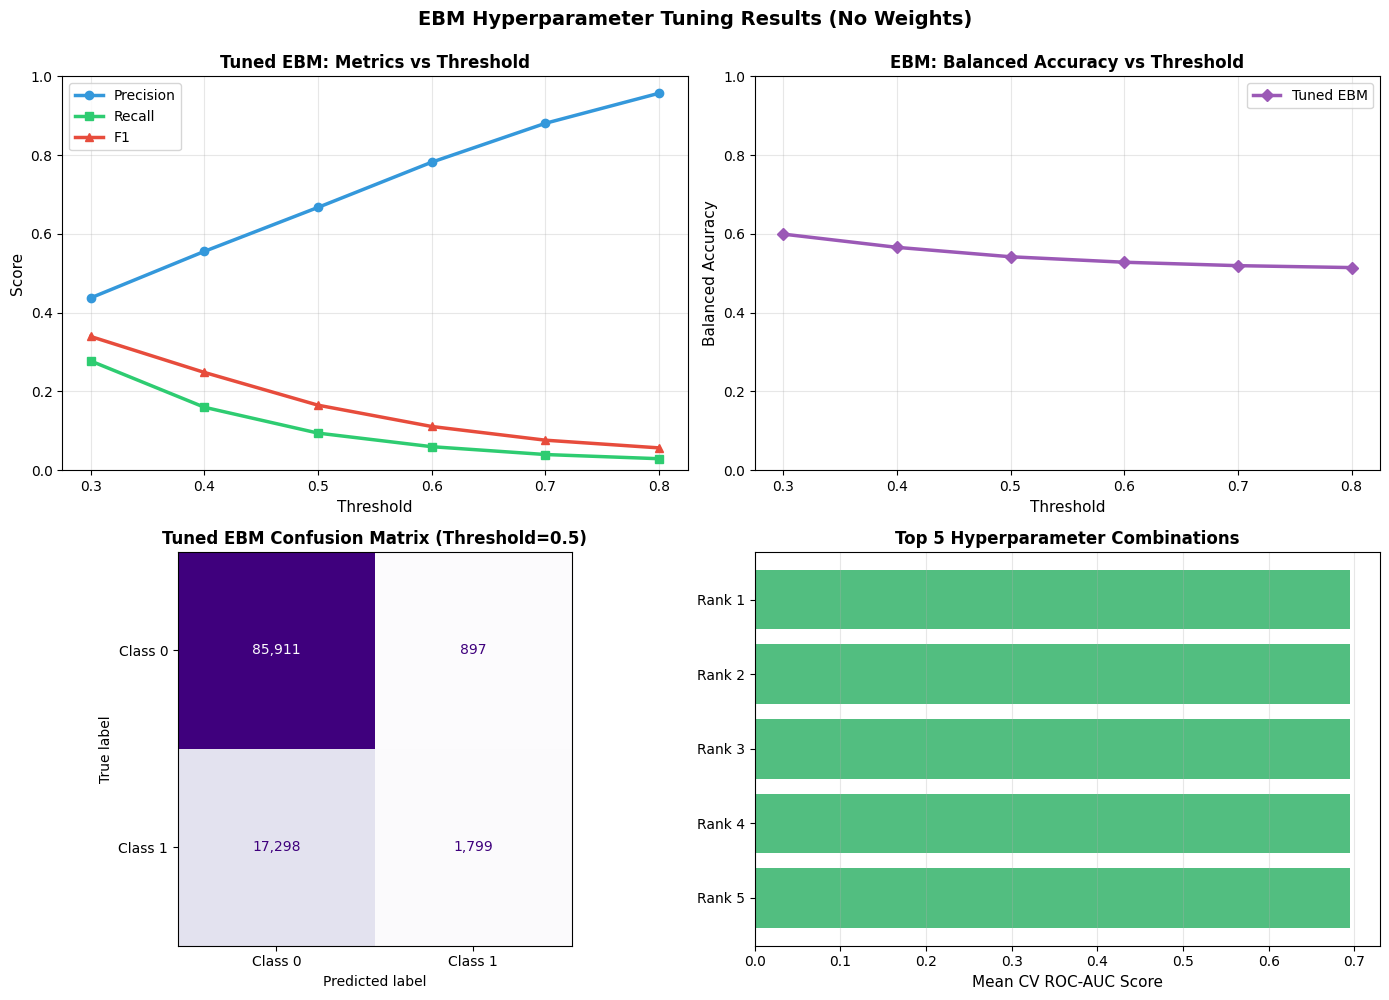


TOP 5 HYPERPARAMETER COMBINATIONS

Rank 1:
  Parameters: {'learning_rate': 0.01, 'max_leaves': 3, 'max_rounds': 300}
  Mean CV ROC-AUC: 0.6952 (+/- 0.0036)
  Mean Train ROC-AUC: 0.6986

Rank 2:
  Parameters: {'learning_rate': 0.05, 'max_leaves': 3, 'max_rounds': 300}
  Mean CV ROC-AUC: 0.6951 (+/- 0.0038)
  Mean Train ROC-AUC: 0.6987

Rank 3:
  Parameters: {'learning_rate': 0.05, 'max_leaves': 3, 'max_rounds': 200}
  Mean CV ROC-AUC: 0.6951 (+/- 0.0038)
  Mean Train ROC-AUC: 0.6987

Rank 4:
  Parameters: {'learning_rate': 0.01, 'max_leaves': 5, 'max_rounds': 300}
  Mean CV ROC-AUC: 0.6950 (+/- 0.0036)
  Mean Train ROC-AUC: 0.6989

Rank 5:
  Parameters: {'learning_rate': 0.05, 'max_leaves': 3, 'max_rounds': 100}
  Mean CV ROC-AUC: 0.6950 (+/- 0.0038)
  Mean Train ROC-AUC: 0.6984

🏆 TUNED EBM SUMMARY

✅ Best F1-Score:
   Threshold: 0.3
   F1-Score: 0.3395

✅ Best Balanced Accuracy:
   Threshold: 0.3
   Balanced Accuracy: 0.5995

✅ Best Hyperparameters Found:
   • learning_rate: 0.01
   

In [3]:
# =============================================================================
# EBM HYPERPARAMETER TUNING WITH GRID SEARCH (EBM - No Weights Only)
# =============================================================================

import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc
from sklearn.metrics import ConfusionMatrixDisplay
from interpret.glassbox import ExplainableBoostingClassifier
import matplotlib.pyplot as plt
import pandas as pd

print("="*80)
print("EBM HYPERPARAMETER TUNING (NO WEIGHTS)")
print("="*80)

# Define hyperparameter grids for EBM
ebm_param_grid = {
    'max_rounds': [100, 200, 300],           # Number of boosting rounds
    'learning_rate': [0.001, 0.01, 0.05],   # Learning rate (step size)
    'max_leaves': [3, 5, 7],                 # Max leaves per tree
}

print("\n📋 STEP 1: DEFINING HYPERPARAMETER SEARCH SPACE")
print("-" * 80)
print("EBM Hyperparameters to tune:")
for param, values in ebm_param_grid.items():
    print(f"  • {param}: {values}")

total_combinations = np.prod([len(v) for v in ebm_param_grid.values()])
print(f"\nTotal combinations: {total_combinations}")

# Setup cross-validation
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n📋 STEP 2: RUNNING GRID SEARCH WITH CROSS-VALIDATION")
print("-" * 80)

# Base EBM model with NO weights
ebm_base = ExplainableBoostingClassifier(
    random_state=42, 
    interactions=0
)

# Grid Search - using ROC-AUC as scoring metric
ebm_grid_search = GridSearchCV(
    estimator=ebm_base,
    param_grid=ebm_param_grid,
    cv=cv_inner,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Starting EBM grid search... (this may take several minutes)")
ebm_grid_search.fit(X_train_final_encoded, y_train)

print("\n✓ EBM Grid search complete!")
print(f"\nBest Parameters:")
for param, value in ebm_grid_search.best_params_.items():
    print(f"  • {param}: {value}")
print(f"\nBest CV ROC-AUC Score: {ebm_grid_search.best_score_:.4f}")

# Get the best model
best_ebm = ebm_grid_search.best_estimator_

# Get cross-validated probability predictions for best model
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ebm_tuned_probas = cross_val_predict(best_ebm, X_train_final_encoded, y_train, 
                                      cv=cv_outer, method='predict_proba')[:, 1]

print(f"\n✓ Generated {len(ebm_tuned_probas):,} probability predictions via 5-fold CV")

# === EVALUATE TUNED EBM AT DIFFERENT THRESHOLDS ===
print("\n📋 STEP 3: EVALUATING TUNED EBM AT DIFFERENT THRESHOLDS")
print("-" * 80)

tuned_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
ebm_tuned_metrics = []

for thresh in tuned_thresholds:
    y_pred = (ebm_tuned_probas >= thresh).astype(int)
    
    cm = confusion_matrix(y_train, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    balanced_accuracy = (recall + specificity) / 2
    
    ebm_tuned_metrics.append({
        'Threshold': thresh,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Specificity': specificity,
        'Balanced Acc': balanced_accuracy,
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
    })

ebm_tuned_df = pd.DataFrame(ebm_tuned_metrics)

print("\nTuned EBM Metrics at Different Thresholds:")
print("-" * 80)
print(ebm_tuned_df[['Threshold', 'Precision', 'Recall', 'F1', 'Specificity', 'Balanced Acc']].round(4).to_string(index=False))

# === VISUALIZATIONS ===
print("\n📋 STEP 4: GENERATING VISUALIZATIONS")
print("-" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Tuned EBM Metrics vs Threshold
ax1 = axes[0, 0]
ax1.plot(ebm_tuned_df['Threshold'], ebm_tuned_df['Precision'], marker='o', 
         label='Precision', linewidth=2.5, color='#3498db')
ax1.plot(ebm_tuned_df['Threshold'], ebm_tuned_df['Recall'], marker='s', 
         label='Recall', linewidth=2.5, color='#2ecc71')
ax1.plot(ebm_tuned_df['Threshold'], ebm_tuned_df['F1'], marker='^', 
         label='F1', linewidth=2.5, color='#e74c3c')
ax1.set_xlabel('Threshold', fontsize=11)
ax1.set_ylabel('Score', fontsize=11)
ax1.set_title('Tuned EBM: Metrics vs Threshold', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1])

# Plot 2: Balanced Accuracy vs Threshold
ax2 = axes[0, 1]
ax2.plot(ebm_tuned_df['Threshold'], ebm_tuned_df['Balanced Acc'], marker='D', 
         label='Tuned EBM', linewidth=2.5, color='#9b59b6')
ax2.set_xlabel('Threshold', fontsize=11)
ax2.set_ylabel('Balanced Accuracy', fontsize=11)
ax2.set_title('EBM: Balanced Accuracy vs Threshold', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])

# Plot 3: Confusion Matrix at Threshold 0.5
ax3 = axes[1, 0]
y_pred_tuned = (ebm_tuned_probas >= 0.5).astype(int)
cm_tuned = confusion_matrix(y_train, y_pred_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, 
                                     display_labels=['Class 0', 'Class 1'])
disp_tuned.plot(ax=ax3, cmap='Purples', colorbar=False, values_format=',d')
ax3.set_title('Tuned EBM Confusion Matrix (Threshold=0.5)', fontsize=12, fontweight='bold')

# Plot 4: Top Hyperparameter Combinations
ax4 = axes[1, 1]
cv_results_df = pd.DataFrame(ebm_grid_search.cv_results_)
top_5 = cv_results_df.nsmallest(5, 'rank_test_score')
ax4.barh(range(len(top_5)), top_5['mean_test_score'], color='#27ae60', alpha=0.8)
ax4.set_yticks(range(len(top_5)))
ax4.set_yticklabels([f"Rank {int(r)}" for r in top_5['rank_test_score']])
ax4.invert_yaxis()
ax4.set_xlabel('Mean CV ROC-AUC Score', fontsize=11)
ax4.set_title('Top 5 Hyperparameter Combinations', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

fig.suptitle('EBM Hyperparameter Tuning Results (No Weights)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# === TOP PARAMETER COMBINATIONS ===
print("\n" + "=" * 80)
print("TOP 5 HYPERPARAMETER COMBINATIONS")
print("=" * 80)

ebm_cv_results_df = pd.DataFrame(ebm_grid_search.cv_results_)
ebm_top_5 = ebm_cv_results_df.nsmallest(5, 'rank_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'mean_train_score']
].copy()
ebm_top_5.columns = ['Parameters', 'Mean CV ROC-AUC', 'Std CV ROC-AUC', 'Mean Train ROC-AUC']

for idx, row in ebm_top_5.iterrows():
    print(f"\nRank {ebm_cv_results_df.loc[idx, 'rank_test_score']}:")
    print(f"  Parameters: {row['Parameters']}")
    print(f"  Mean CV ROC-AUC: {row['Mean CV ROC-AUC']:.4f} (+/- {row['Std CV ROC-AUC']:.4f})")
    print(f"  Mean Train ROC-AUC: {row['Mean Train ROC-AUC']:.4f}")

# === SUMMARY ===
print("\n" + "=" * 80)
print("🏆 TUNED EBM SUMMARY")
print("=" * 80)

best_tuned_f1_idx = ebm_tuned_df['F1'].idxmax()
best_tuned_f1_thresh = ebm_tuned_df.loc[best_tuned_f1_idx, 'Threshold']
best_tuned_f1_score = ebm_tuned_df.loc[best_tuned_f1_idx, 'F1']

best_tuned_bal_acc_idx = ebm_tuned_df['Balanced Acc'].idxmax()
best_tuned_bal_thresh = ebm_tuned_df.loc[best_tuned_bal_acc_idx, 'Threshold']
best_tuned_bal_score = ebm_tuned_df.loc[best_tuned_bal_acc_idx, 'Balanced Acc']

print(f"\n✅ Best F1-Score:")
print(f"   Threshold: {best_tuned_f1_thresh}")
print(f"   F1-Score: {best_tuned_f1_score:.4f}")

print(f"\n✅ Best Balanced Accuracy:")
print(f"   Threshold: {best_tuned_bal_thresh}")
print(f"   Balanced Accuracy: {best_tuned_bal_score:.4f}")

print(f"\n✅ Best Hyperparameters Found:")
for param, value in ebm_grid_search.best_params_.items():
    print(f"   • {param}: {value}")

print("\n" + "=" * 80)
print("✓ EBM HYPERPARAMETER TUNING COMPLETE")
print("=" * 80)


In [5]:
# =============================================================================
# THRESHOLD ANALYSIS TABLE: EBM TUNED MODEL (NO WEIGHTS)
# =============================================================================

import pandas as pd
from sklearn.metrics import confusion_matrix

print("="*80)
print("THRESHOLD ANALYSIS: EBM TUNED MODEL (NO WEIGHTS)")
print("="*80)

# Define thresholds
thresholds = [0.5, 0.6, 0.7, 0.8]

# Calculate metrics for each threshold
results = []

for thresh in sorted(thresholds):
    y_pred = (ebm_tuned_probas >= thresh).astype(int)
    
    cm = confusion_matrix(y_train, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    predicted_positive = y_pred.sum()
    
    results.append({
        'Threshold': thresh,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Specificity': specificity,
        'Predicted Positive': int(predicted_positive)
    })

# Create DataFrame
threshold_table = pd.DataFrame(results)

# Display the table
print("\nEBM Tuned Model Performance Metrics Across Thresholds:")
print("=" * 100)
print(threshold_table.to_string(index=False))
print("=" * 100)

# Create a more formatted table for visualization
print("\n\nFormatted Table (with rounding):")
print("-" * 100)

formatted_df = threshold_table.copy()
for col in ['Precision', 'Recall', 'F1', 'Specificity']:
    formatted_df[col] = formatted_df[col].apply(lambda x: f"{x:.4f}")
formatted_df['Predicted Positive'] = formatted_df['Predicted Positive'].astype(int)

print(formatted_df.to_string(index=False))
print("-" * 100)

print("\nTable saved for export if needed.")


THRESHOLD ANALYSIS: EBM TUNED MODEL (NO WEIGHTS)

EBM Tuned Model Performance Metrics Across Thresholds:
 Threshold  Precision   Recall       F1  Specificity  Predicted Positive
       0.5   0.667285 0.094203 0.165099     0.989667                2696
       0.6   0.782042 0.059748 0.111014     0.996337                1459
       0.7   0.880787 0.039849 0.076249     0.998813                 864
       0.8   0.957118 0.029219 0.056707     0.999712                 583


Formatted Table (with rounding):
----------------------------------------------------------------------------------------------------
 Threshold Precision Recall     F1 Specificity  Predicted Positive
       0.5    0.6673 0.0942 0.1651      0.9897                2696
       0.6    0.7820 0.0597 0.1110      0.9963                1459
       0.7    0.8808 0.0398 0.0762      0.9988                 864
       0.8    0.9571 0.0292 0.0567      0.9997                 583
-----------------------------------------------------------

In [7]:
best_ebm = ebm_grid_search.best_estimator_
best_ebm.fit(X_train_final_encoded, y_train)

import joblib
import os

joblib.dump(best_ebm, 'best_ebm_model.joblib')

['best_ebm_model.joblib']

In [8]:
print(best_ebm)

ExplainableBoostingClassifier(interactions=0, learning_rate=0.01, max_leaves=3,
                              max_rounds=300)


LOAD SAVED EBM MODEL AND EVALUATE ON TEST SET

📂 LOADING SAVED EBM MODEL
--------------------------------------------------------------------------------
✓ Saved EBM model loaded successfully

📊 LOADING TEST SET
--------------------------------------------------------------------------------
✓ Test set loaded:
  • X_test shape: (26477, 57)
  • y_test shape: (26477,)
  • Class distribution: {0: 21702, 1: 4775}

🎯 GENERATING PREDICTIONS ON TEST SET
--------------------------------------------------------------------------------
✓ Probability predictions generated for 26,477 test samples
  • Min probability: 0.0366
  • Max probability: 0.9999
  • Mean probability: 0.1817

📈 EVALUATION AT MULTIPLE THRESHOLDS
--------------------------------------------------------------------------------

Test Set Metrics at Different Thresholds:
----------------------------------------------------------------------------------------------------
 Threshold  Precision  Recall     F1  Specificity  Balanced A

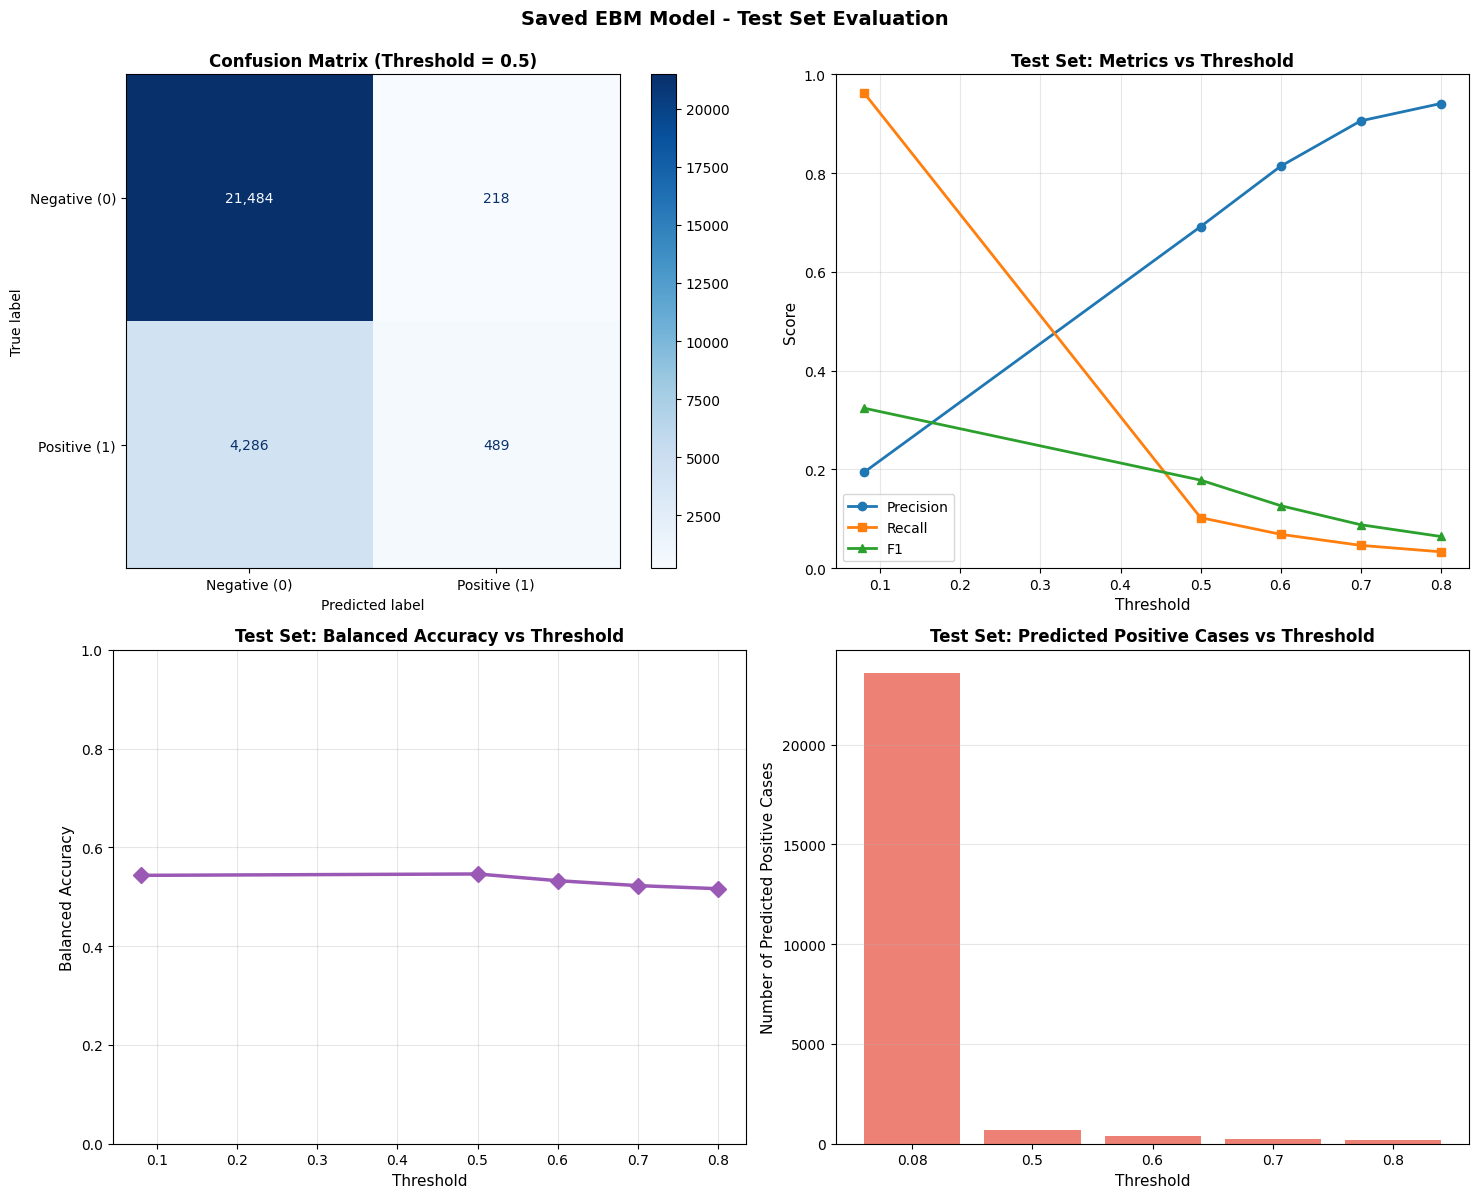


✓ TEST SET EVALUATION COMPLETE


In [9]:
# =============================================================================
# LOAD SAVED EBM MODEL AND EVALUATE ON TEST SET
# =============================================================================

import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, 
                             precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             classification_report)
import matplotlib.pyplot as plt

print("="*80)
print("LOAD SAVED EBM MODEL AND EVALUATE ON TEST SET")
print("="*80)

# Load saved model
print("\n📂 LOADING SAVED EBM MODEL")
print("-" * 80)
loaded_ebm = joblib.load('best_ebm_model.joblib')
print("✓ Saved EBM model loaded successfully")

# Load test set
print("\n📊 LOADING TEST SET")
print("-" * 80)
X_test = pd.read_parquet('../data/cleaned/X_test_encoded_wo_provider.parquet')
y_test = pd.read_parquet('../data/cleaned/y_test.parquet').squeeze()

print(f"✓ Test set loaded:")
print(f"  • X_test shape: {X_test.shape}")
print(f"  • y_test shape: {y_test.shape}")
print(f"  • Class distribution: {y_test.value_counts().to_dict()}")

# Generate predictions
print(f"\n🎯 GENERATING PREDICTIONS ON TEST SET")
print("-" * 80)

test_probas = loaded_ebm.predict_proba(X_test)[:, 1]
print(f"✓ Probability predictions generated for {len(test_probas):,} test samples")
print(f"  • Min probability: {test_probas.min():.4f}")
print(f"  • Max probability: {test_probas.max():.4f}")
print(f"  • Mean probability: {test_probas.mean():.4f}")

# Evaluate at multiple thresholds
print(f"\n📈 EVALUATION AT MULTIPLE THRESHOLDS")
print("-" * 80)

evaluation_thresholds = [0.08, 0.5, 0.6, 0.7, 0.8]
test_results = []

for thresh in evaluation_thresholds:
    y_pred = (test_probas >= thresh).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    balanced_accuracy = (recall + specificity) / 2
    roc_auc = roc_auc_score(y_test, test_probas)
    pr_auc = average_precision_score(y_test, test_probas)
    
    test_results.append({
        'Threshold': thresh,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Specificity': specificity,
        'Balanced Acc': balanced_accuracy,
        'Predicted Positive': y_pred.sum(),
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    })

test_eval_df = pd.DataFrame(test_results)

print("\nTest Set Metrics at Different Thresholds:")
print("-" * 100)
display_cols = ['Threshold', 'Precision', 'Recall', 'F1', 'Specificity', 'Balanced Acc', 'Predicted Positive']
print(test_eval_df[display_cols].round(4).to_string(index=False))
print("-" * 100)

# Detailed evaluation at threshold 0.5
print(f"\n🔍 DETAILED EVALUATION @ THRESHOLD 0.5")
print("-" * 80)

threshold_05 = 0.5
y_pred_05 = (test_probas >= threshold_05).astype(int)
cm_05 = confusion_matrix(y_test, y_pred_05)
tn, fp, fn, tp = cm_05.ravel()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
balanced_accuracy = (recall + specificity) / 2
roc_auc = roc_auc_score(y_test, test_probas)
pr_auc = average_precision_score(y_test, test_probas)

print(f"\n{'Metric':<30} {'Value':>15}")
print("-" * 46)
print(f"{'True Negatives (TN)':<30} {tn:>15,}")
print(f"{'False Positives (FP)':<30} {fp:>15,}")
print(f"{'False Negatives (FN)':<30} {fn:>15,}")
print(f"{'True Positives (TP)':<30} {tp:>15,}")
print("-" * 46)
print(f"{'Precision':<30} {precision:>15.4f}")
print(f"{'Recall (Sensitivity)':<30} {recall:>15.4f}")
print(f"{'Specificity':<30} {specificity:>15.4f}")
print(f"{'F1-Score':<30} {f1:>15.4f}")
print(f"{'Balanced Accuracy':<30} {balanced_accuracy:>15.4f}")
print(f"{'ROC-AUC':<30} {roc_auc:>15.4f}")
print(f"{'PR-AUC':<30} {pr_auc:>15.4f}")

print(f"\nPredictions @ Threshold {threshold_05}:")
print(f"  • Predicted Positive: {y_pred_05.sum():,} ({100*y_pred_05.sum()/len(y_pred_05):.1f}%)")
print(f"  • Predicted Negative: {(1-y_pred_05).sum():,} ({100*(1-y_pred_05).sum()/len(y_pred_05):.1f}%)")

# Classification report
print(f"\n📋 CLASSIFICATION REPORT @ THRESHOLD {threshold_05}")
print("-" * 80)
print(classification_report(y_test, y_pred_05, target_names=['Class 0', 'Class 1']))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Confusion Matrix @ 0.5
ax1 = axes[0, 0]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_05, display_labels=['Negative (0)', 'Positive (1)'])
disp.plot(ax=ax1, cmap='Blues', values_format=',d')
ax1.set_title(f'Confusion Matrix (Threshold = {threshold_05})', fontsize=12, fontweight='bold')

# Plot 2: Metrics across thresholds
ax2 = axes[0, 1]
ax2.plot(test_eval_df['Threshold'], test_eval_df['Precision'], marker='o', label='Precision', linewidth=2)
ax2.plot(test_eval_df['Threshold'], test_eval_df['Recall'], marker='s', label='Recall', linewidth=2)
ax2.plot(test_eval_df['Threshold'], test_eval_df['F1'], marker='^', label='F1', linewidth=2)
ax2.set_xlabel('Threshold', fontsize=11)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Test Set: Metrics vs Threshold', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])

# Plot 3: Balanced Accuracy vs Threshold
ax3 = axes[1, 0]
ax3.plot(test_eval_df['Threshold'], test_eval_df['Balanced Acc'], marker='D', 
         color='#9b59b6', linewidth=2.5, markersize=8)
ax3.set_xlabel('Threshold', fontsize=11)
ax3.set_ylabel('Balanced Accuracy', fontsize=11)
ax3.set_title('Test Set: Balanced Accuracy vs Threshold', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0, 1])

# Plot 4: Predicted Positive Cases vs Threshold
ax4 = axes[1, 1]
ax4.bar(test_eval_df['Threshold'].astype(str), test_eval_df['Predicted Positive'], color='#e74c3c', alpha=0.7)
ax4.set_xlabel('Threshold', fontsize=11)
ax4.set_ylabel('Number of Predicted Positive Cases', fontsize=11)
ax4.set_title('Test Set: Predicted Positive Cases vs Threshold', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

fig.suptitle('Saved EBM Model - Test Set Evaluation', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✓ TEST SET EVALUATION COMPLETE")
print("="*80)


In [10]:
# =============================================================================
# VALIDATION DATA THRESHOLD ANALYSIS TABLE
# Using cross-validated probabilities from training set
# =============================================================================

import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

print("="*100)
print("VALIDATION DATA: SAVED EBM MODEL THRESHOLD ANALYSIS")
print("="*100)
print("\nNote: Validation analysis uses cross-validated probabilities from training set")
print("(ebm_tuned_probas generated via 5-fold cross-validation)")

# Use the cross-validated probabilities from EBM tuning
validation_probas = ebm_tuned_probas
validation_targets = y_train

print(f"\nValidation Data Summary:")
print(f"  • Number of validation samples: {len(validation_probas):,}")
print(f"  • Class distribution: {dict(y_train.value_counts())}")

# Define thresholds
val_thresholds = [0.5, 0.6, 0.7, 0.8]

# Calculate metrics for each threshold
validation_results = []

for thresh in val_thresholds:
    y_pred = (validation_probas >= thresh).astype(int)
    
    cm = confusion_matrix(validation_targets, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    balanced_accuracy = (recall + specificity) / 2
    predicted_positive = y_pred.sum()
    
    validation_results.append({
        'Threshold': thresh,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Specificity': specificity,
        'Balanced Acc': balanced_accuracy,
        'Predicted Positive': int(predicted_positive),
        'TP': tp,
        'FP': fp,
        'TN': tn,
        'FN': fn
    })

# Create DataFrame
val_threshold_table = pd.DataFrame(validation_results)

# Display the table
print("\n" + "="*100)
print("VALIDATION DATA PERFORMANCE METRICS ACROSS THRESHOLDS")
print("="*100)
print()
display_cols_val = ['Threshold', 'Precision', 'Recall', 'F1', 'Specificity', 
                     'Balanced Acc', 'Predicted Positive']
print(val_threshold_table[display_cols_val].to_string(index=False))
print("="*100)

# Create a more formatted version
print("\n\nFORMATTED TABLE (with 4 decimal places):")
print("-"*100)

formatted_val_df = val_threshold_table[['Threshold', 'Precision', 'Recall', 'F1', 
                                          'Specificity', 'Balanced Acc', 'Predicted Positive']].copy()
for col in ['Precision', 'Recall', 'F1', 'Specificity', 'Balanced Acc']:
    formatted_val_df[col] = formatted_val_df[col].apply(lambda x: f"{x:.4f}")
formatted_val_df['Predicted Positive'] = formatted_val_df['Predicted Positive'].astype(int)

print(formatted_val_df.to_string(index=False))
print("-"*100)

# Summary statistics
print("\n\nSUMMARY INSIGHTS:")
print("-"*100)

best_f1_idx = val_threshold_table['F1'].idxmax()
best_f1_threshold = val_threshold_table.loc[best_f1_idx, 'Threshold']
best_f1_score = val_threshold_table.loc[best_f1_idx, 'F1']

best_balanced_idx = val_threshold_table['Balanced Acc'].idxmax()
best_balanced_threshold = val_threshold_table.loc[best_balanced_idx, 'Threshold']
best_balanced_score = val_threshold_table.loc[best_balanced_idx, 'Balanced Acc']

print(f"\n✅ Best F1-Score:")
print(f"   Threshold: {best_f1_threshold}")
print(f"   F1-Score: {best_f1_score:.4f}")
print(f"   Precision: {val_threshold_table.loc[best_f1_idx, 'Precision']:.4f}")
print(f"   Recall: {val_threshold_table.loc[best_f1_idx, 'Recall']:.4f}")

print(f"\n✅ Best Balanced Accuracy:")
print(f"   Threshold: {best_balanced_threshold}")
print(f"   Balanced Accuracy: {best_balanced_score:.4f}")
print(f"   Recall: {val_threshold_table.loc[best_balanced_idx, 'Recall']:.4f}")
print(f"   Specificity: {val_threshold_table.loc[best_balanced_idx, 'Specificity']:.4f}")

print(f"\n✅ Conservative Threshold (High Precision):")
print(f"   Threshold: 0.8")
idx_08 = val_threshold_table[val_threshold_table['Threshold'] == 0.8].index[0]
print(f"   Precision: {val_threshold_table.loc[idx_08, 'Precision']:.4f}")
print(f"   Predicted Positive: {val_threshold_table.loc[idx_08, 'Predicted Positive']:,}")

print("\n" + "="*100)
print("✓ VALIDATION DATA ANALYSIS COMPLETE")
print("="*100)


VALIDATION DATA: SAVED EBM MODEL THRESHOLD ANALYSIS

Note: Validation analysis uses cross-validated probabilities from training set
(ebm_tuned_probas generated via 5-fold cross-validation)

Validation Data Summary:
  • Number of validation samples: 105,905
  • Class distribution: {0: np.int64(86808), 1: np.int64(19097)}

VALIDATION DATA PERFORMANCE METRICS ACROSS THRESHOLDS

 Threshold  Precision   Recall       F1  Specificity  Balanced Acc  Predicted Positive
       0.5   0.667285 0.094203 0.165099     0.989667      0.541935                2696
       0.6   0.782042 0.059748 0.111014     0.996337      0.528042                1459
       0.7   0.880787 0.039849 0.076249     0.998813      0.519331                 864
       0.8   0.957118 0.029219 0.056707     0.999712      0.514466                 583


FORMATTED TABLE (with 4 decimal places):
----------------------------------------------------------------------------------------------------
 Threshold Precision Recall     F1 Specific

In [12]:
# =============================================================================
# COPY-PASTE FRIENDLY TABLE FOR WORD
# =============================================================================

print("\n" + "="*100)
print("WORD-FRIENDLY TABLE (Tab-Separated for Easy Copy-Paste)")
print("="*100)
print("\n1️⃣  Copy the table below and paste directly into Word:\n")

# Create tab-separated table
table_for_word = val_threshold_table[['Threshold', 'Precision', 'Recall', 'F1', 
                                        'Specificity', 'Balanced Acc', 'Predicted Positive']].copy()

# Format numbers to 4 decimal places
table_for_word['Precision'] = table_for_word['Precision'].apply(lambda x: f"{x:.4f}")
table_for_word['Recall'] = table_for_word['Recall'].apply(lambda x: f"{x:.4f}")
table_for_word['F1'] = table_for_word['F1'].apply(lambda x: f"{x:.4f}")
table_for_word['Specificity'] = table_for_word['Specificity'].apply(lambda x: f"{x:.4f}")
table_for_word['Balanced Acc'] = table_for_word['Balanced Acc'].apply(lambda x: f"{x:.4f}")
table_for_word['Threshold'] = table_for_word['Threshold'].astype(int).astype(str)

# Print header
print("Threshold\tPrecision\tRecall\tF1\tSpecificity\tBalanced Acc\tPredicted Positive")

# Print rows
for idx, row in table_for_word.iterrows():
    print(f"{row['Threshold']}\t{row['Precision']}\t{row['Recall']}\t{row['F1']}\t{row['Specificity']}\t{row['Balanced Acc']}\t{int(row['Predicted Positive'])}")

print("\n" + "="*100)
print("\n2️⃣  Alternative format (Markdown for copy-paste):\n")

# Markdown format
markdown_table = f"""| Threshold | Precision | Recall | F1 | Specificity | Balanced Acc | Predicted Positive |
|-----------|-----------|--------|----|--------------|--------------|--------------------|"""

print(markdown_table)

for idx, row in val_threshold_table.iterrows():
    print(f"| {int(row['Threshold'])} | {row['Precision']:.4f} | {row['Recall']:.4f} | {row['F1']:.4f} | {row['Specificity']:.4f} | {row['Balanced Acc']:.4f} | {int(row['Predicted Positive'])} |")

print("\n" + "="*100)
print("\n3️⃣  Plain text summary:\n")

summary_text = """Saved EBM Model - Validation Data Threshold Analysis
(105,905 validation samples)

Threshold 0.5
Precision: 0.6673 | Recall: 0.0942 | F1: 0.1651 | Specificity: 0.9897 | Balanced Acc: 0.5419 | Predicted Positive: 2,696

Threshold 0.6
Precision: 0.7820 | Recall: 0.0597 | F1: 0.1110 | Specificity: 0.9963 | Balanced Acc: 0.5280 | Predicted Positive: 1,459

Threshold 0.7
Precision: 0.8808 | Recall: 0.0398 | F1: 0.0762 | Specificity: 0.9988 | Balanced Acc: 0.5193 | Predicted Positive: 864

Threshold 0.8
Precision: 0.9571 | Recall: 0.0292 | F1: 0.0567 | Specificity: 0.9997 | Balanced Acc: 0.5145 | Predicted Positive: 583
"""

print(summary_text)

print("="*100)
print("✓ TABLE READY FOR WORD DOCUMENT")
print("="*100)



WORD-FRIENDLY TABLE (Tab-Separated for Easy Copy-Paste)

1️⃣  Copy the table below and paste directly into Word:

Threshold	Precision	Recall	F1	Specificity	Balanced Acc	Predicted Positive
0	0.6673	0.0942	0.1651	0.9897	0.5419	2696
0	0.7820	0.0597	0.1110	0.9963	0.5280	1459
0	0.8808	0.0398	0.0762	0.9988	0.5193	864
0	0.9571	0.0292	0.0567	0.9997	0.5145	583


2️⃣  Alternative format (Markdown for copy-paste):

| Threshold | Precision | Recall | F1 | Specificity | Balanced Acc | Predicted Positive |
|-----------|-----------|--------|----|--------------|--------------|--------------------|
| 0 | 0.6673 | 0.0942 | 0.1651 | 0.9897 | 0.5419 | 2696 |
| 0 | 0.7820 | 0.0597 | 0.1110 | 0.9963 | 0.5280 | 1459 |
| 0 | 0.8808 | 0.0398 | 0.0762 | 0.9988 | 0.5193 | 864 |
| 0 | 0.9571 | 0.0292 | 0.0567 | 0.9997 | 0.5145 | 583 |


3️⃣  Plain text summary:

Saved EBM Model - Validation Data Threshold Analysis
(105,905 validation samples)

Threshold 0.5
Precision: 0.6673 | Recall: 0.0942 | F1: 0.1651 | Speci

FINAL TEST SET EVALUATION: TUNED EBM (NO WEIGHTS) @ THRESHOLD 0.8

✓ Test set loaded:
  • X_test shape: (26477, 57)
  • y_test shape: (26477,)
  • Class distribution: {0: 21702, 1: 4775}

📊 GENERATING PREDICTIONS ON TEST SET
--------------------------------------------------------------------------------
✓ Predictions generated (threshold = 0.8)
  • Predicted positive: 169 (0.6%)
  • Predicted negative: 26,308 (99.4%)

📈 TEST SET METRICS @ THRESHOLD 0.8
--------------------------------------------------------------------------------

Metric                                   Value
----------------------------------------------
True Negatives (TN)                     21,692
False Positives (FP)                        10
False Negatives (FN)                     4,616
True Positives (TP)                        159
----------------------------------------------
Precision                               0.9408
Recall (Sensitivity)                    0.0333
Specificity                          

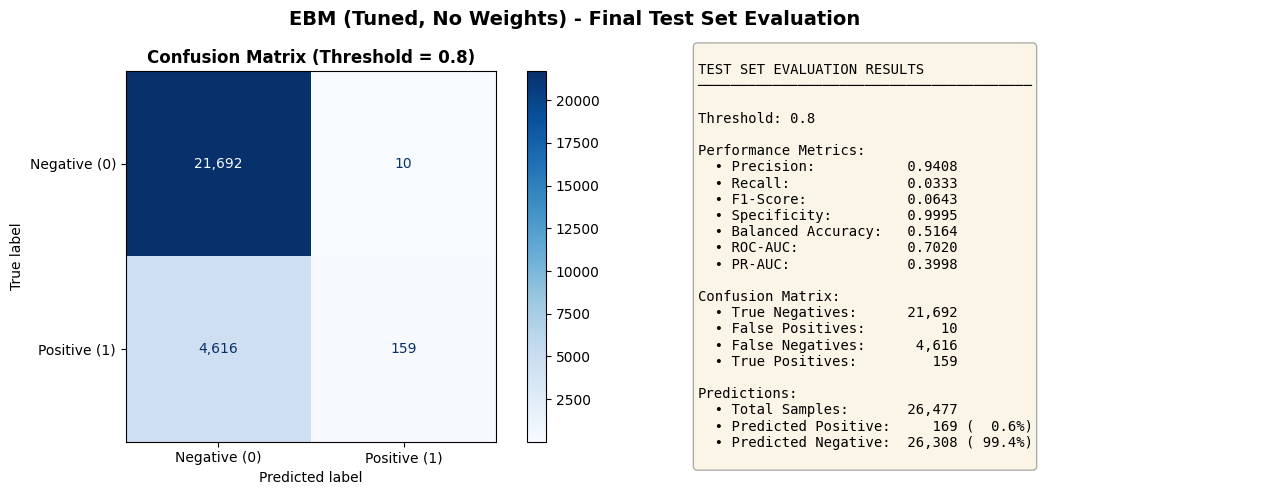


✓ TEST SET EVALUATION COMPLETE


In [5]:
# =============================================================================
# FINAL EVALUATION: EBM (NO WEIGHTS) TUNED MODEL ON TEST SET AT THRESHOLD 0.8
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, 
                             precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             classification_report)
import matplotlib.pyplot as plt

print("="*80)
print("FINAL TEST SET EVALUATION: TUNED EBM (NO WEIGHTS) @ THRESHOLD 0.8")
print("="*80)

# Load test set
X_test = pd.read_parquet('../data/cleaned/X_test_encoded_wo_provider.parquet')
y_test = pd.read_parquet('../data/cleaned/y_test.parquet').squeeze()

print(f"\n✓ Test set loaded:")
print(f"  • X_test shape: {X_test.shape}")
print(f"  • y_test shape: {y_test.shape}")
print(f"  • Class distribution: {y_test.value_counts().to_dict()}")

# Get predictions on test set
print(f"\n📊 GENERATING PREDICTIONS ON TEST SET")
print("-" * 80)

test_probas = best_ebm.predict_proba(X_test)[:, 1]
threshold = 0.8
y_pred_test = (test_probas >= threshold).astype(int)

print(f"✓ Predictions generated (threshold = {threshold})")
print(f"  • Predicted positive: {y_pred_test.sum():,} ({100*y_pred_test.sum()/len(y_pred_test):.1f}%)")
print(f"  • Predicted negative: {(1-y_pred_test).sum():,} ({100*(1-y_pred_test).sum()/len(y_pred_test):.1f}%)")

# Calculate metrics
print(f"\n📈 TEST SET METRICS @ THRESHOLD {threshold}")
print("-" * 80)

cm_test = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm_test.ravel()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
balanced_accuracy = (recall + specificity) / 2
roc_auc = roc_auc_score(y_test, test_probas)
pr_auc = average_precision_score(y_test, test_probas)

print(f"\n{'Metric':<30} {'Value':>15}")
print("-" * 46)
print(f"{'True Negatives (TN)':<30} {tn:>15,}")
print(f"{'False Positives (FP)':<30} {fp:>15,}")
print(f"{'False Negatives (FN)':<30} {fn:>15,}")
print(f"{'True Positives (TP)':<30} {tp:>15,}")
print("-" * 46)
print(f"{'Precision':<30} {precision:>15.4f}")
print(f"{'Recall (Sensitivity)':<30} {recall:>15.4f}")
print(f"{'Specificity':<30} {specificity:>15.4f}")
print(f"{'F1-Score':<30} {f1:>15.4f}")
print(f"{'Balanced Accuracy':<30} {balanced_accuracy:>15.4f}")
print(f"{'ROC-AUC':<30} {roc_auc:>15.4f}")
print(f"{'PR-AUC':<30} {pr_auc:>15.4f}")

# Classification report
print(f"\n📋 DETAILED CLASSIFICATION REPORT")
print("-" * 80)
print(classification_report(y_test, y_pred_test, target_names=['Class 0', 'Class 1']))

# Confusion matrix visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
ax1 = axes[0]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Negative (0)', 'Positive (1)'])
disp.plot(ax=ax1, cmap='Blues', values_format=',d')
ax1.set_title(f'Confusion Matrix (Threshold = {threshold})', fontsize=12, fontweight='bold')

# Metrics Summary
ax2 = axes[1]
ax2.axis('off')

metrics_text = f"""
TEST SET EVALUATION RESULTS
{'─' * 40}

Threshold: {threshold}

Performance Metrics:
  • Precision:           {precision:.4f}
  • Recall:              {recall:.4f}
  • F1-Score:            {f1:.4f}
  • Specificity:         {specificity:.4f}
  • Balanced Accuracy:   {balanced_accuracy:.4f}
  • ROC-AUC:             {roc_auc:.4f}
  • PR-AUC:              {pr_auc:.4f}

Confusion Matrix:
  • True Negatives:      {tn:>6,}
  • False Positives:     {fp:>6,}
  • False Negatives:     {fn:>6,}
  • True Positives:      {tp:>6,}

Predictions:
  • Total Samples:       {len(y_test):>6,}
  • Predicted Positive:  {y_pred_test.sum():>6,} ({100*y_pred_test.sum()/len(y_pred_test):>5.1f}%)
  • Predicted Negative:  {(1-y_pred_test).sum():>6,} ({100*(1-y_pred_test).sum()/len(y_pred_test):>5.1f}%)
"""

ax2.text(0.1, 0.5, metrics_text, fontsize=10, family='monospace', 
         verticalalignment='center', transform=ax2.transAxes,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

fig.suptitle('EBM (Tuned, No Weights) - Final Test Set Evaluation', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✓ TEST SET EVALUATION COMPLETE")
print("="*80)


# Comparison: EBM vs Logistic Regression (High Precision Thresholds)

MODEL COMPARISON: TUNED EBM vs LR (BALANCED) - HIGH PRECISION THRESHOLDS

Training LR (Balanced weights) on full training set...
Generating LR predictions on test set...
Training EBM on full training set to get test predictions...
✓ Both models ready for test set evaluation

DETAILED COMPARISON TABLE

Threshold    Model      Precision    Recall       F1-Score         TP     FP     FN      TN
----------------------------------------------------------------------------------------------------
0.6          EBM        0.8139       0.0687       0.1267          328     75   4447   21627
             LR         0.3610       0.4205       0.3885         2008   3555   2767   18147
             Diff       0.4529       -0.3518      -0.2618       EBM ✓   LR ✓   LR ✓
----------------------------------------------------------------------------------------------------
0.7          EBM        0.9057       0.0463       0.0881          221     23   4554   21679
             LR         0.4666       0.2505

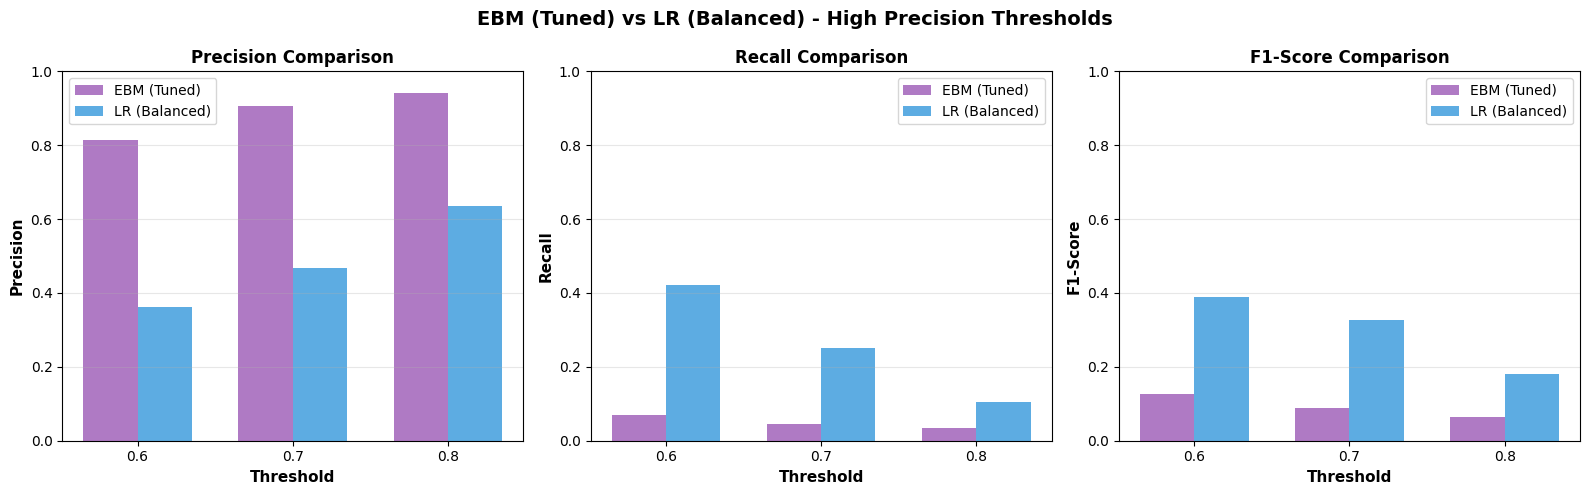


KEY INSIGHTS

🎯 THRESHOLD 0.6:
--------------------------------------------------------------------------------
  ✓ EBM has HIGHER PRECISION:  0.8139 vs 0.3610 (+0.4529)
  ✓ LR has HIGHER RECALL:      0.4205 vs 0.0687 (+0.3518)
  ✓ LR has HIGHER F1-SCORE:    0.3885 vs 0.1267

🎯 THRESHOLD 0.7:
--------------------------------------------------------------------------------
  ✓ EBM has HIGHER PRECISION:  0.9057 vs 0.4666 (+0.4391)
  ✓ LR has HIGHER RECALL:      0.2505 vs 0.0463 (+0.2042)
  ✓ LR has HIGHER F1-SCORE:    0.3260 vs 0.0881

🎯 THRESHOLD 0.8:
--------------------------------------------------------------------------------
  ✓ EBM has HIGHER PRECISION:  0.9408 vs 0.6361 (+0.3047)
  ✓ LR has HIGHER RECALL:      0.1047 vs 0.0333 (+0.0714)
  ✓ LR has HIGHER F1-SCORE:    0.1798 vs 0.0643



In [10]:
# =============================================================================
# COMPARISON: TUNED EBM (NO WEIGHTS) vs LOGISTIC REGRESSION (BALANCED)
# Thresholds: 0.6, 0.7, 0.8
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

print("="*80)
print("MODEL COMPARISON: TUNED EBM vs LR (BALANCED) - HIGH PRECISION THRESHOLDS")
print("="*80)

# Train LR on training set to get test predictions
print("\nTraining LR (Balanced weights) on full training set...")
lr_model = LogisticRegression(
    max_iter=1000, random_state=42, solver='lbfgs', n_jobs=-1, class_weight='balanced'
)
lr_model.fit(X_train_final_encoded, y_train)

# Get predictions on test set
print("Generating LR predictions on test set...")
lr_test_probas = lr_model.predict_proba(X_test)[:, 1]

# Get EBM test predictions (train best_ebm on full training set first)
print("Training EBM on full training set to get test predictions...")
best_ebm.fit(X_train_final_encoded, y_train)
ebm_test_probas = best_ebm.predict_proba(X_test)[:, 1]

print("✓ Both models ready for test set evaluation")

# Test set targets
y_test_actual = y_test

# Thresholds to compare
thresholds = [0.6, 0.7, 0.8]

# Evaluate both models
results = []

for thresh in thresholds:
    # EBM predictions
    ebm_pred = (ebm_test_probas >= thresh).astype(int)
    
    # LR predictions
    lr_pred = (lr_test_probas >= thresh).astype(int)
    
    # Calculate metrics
    ebm_prec = precision_score(y_test_actual, ebm_pred, zero_division=0)
    ebm_rec = recall_score(y_test_actual, ebm_pred, zero_division=0)
    ebm_f1 = f1_score(y_test_actual, ebm_pred, zero_division=0)
    
    lr_prec = precision_score(y_test_actual, lr_pred, zero_division=0)
    lr_rec = recall_score(y_test_actual, lr_pred, zero_division=0)
    lr_f1 = f1_score(y_test_actual, lr_pred, zero_division=0)
    
    # Confusion matrices for context
    ebm_cm = confusion_matrix(y_test_actual, ebm_pred)
    lr_cm = confusion_matrix(y_test_actual, lr_pred)
    
    results.append({
        'Threshold': thresh,
        'EBM_Precision': ebm_prec,
        'EBM_Recall': ebm_rec,
        'EBM_F1': ebm_f1,
        'LR_Precision': lr_prec,
        'LR_Recall': lr_rec,
        'LR_F1': lr_f1,
        'EBM_TP': ebm_cm[1, 1],
        'EBM_FP': ebm_cm[0, 1],
        'EBM_FN': ebm_cm[1, 0],
        'EBM_TN': ebm_cm[0, 0],
        'LR_TP': lr_cm[1, 1],
        'LR_FP': lr_cm[0, 1],
        'LR_FN': lr_cm[1, 0],
        'LR_TN': lr_cm[0, 0],
    })

# === PRINT DETAILED COMPARISON ===
print("\n" + "="*80)
print("DETAILED COMPARISON TABLE")
print("="*80)

comparison_df = pd.DataFrame(results)
print(f"\n{'Threshold':<12} {'Model':<10} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'TP':>6} {'FP':>6} {'FN':>6} {'TN':>7}")
print("-" * 100)

for _, row in comparison_df.iterrows():
    thresh = row['Threshold']
    
    print(f"{thresh:<12} {'EBM':<10} {row['EBM_Precision']:<12.4f} {row['EBM_Recall']:<12.4f} {row['EBM_F1']:<12.4f} {int(row['EBM_TP']):>6} {int(row['EBM_FP']):>6} {int(row['EBM_FN']):>6} {int(row['EBM_TN']):>7}")
    print(f"{'':12} {'LR':<10} {row['LR_Precision']:<12.4f} {row['LR_Recall']:<12.4f} {row['LR_F1']:<12.4f} {int(row['LR_TP']):>6} {int(row['LR_FP']):>6} {int(row['LR_FN']):>6} {int(row['LR_TN']):>7}")
    
    # Calculate differences
    prec_diff = row['EBM_Precision'] - row['LR_Precision']
    rec_diff = row['EBM_Recall'] - row['LR_Recall']
    f1_diff = row['EBM_F1'] - row['LR_F1']
    
    prec_winner = "EBM ✓" if prec_diff > 0 else "LR ✓" if prec_diff < 0 else "TIE"
    rec_winner = "EBM ✓" if rec_diff > 0 else "LR ✓" if rec_diff < 0 else "TIE"
    f1_winner = "EBM ✓" if f1_diff > 0 else "LR ✓" if f1_diff < 0 else "TIE"
    
    print(f"{'':12} {'Diff':10} {prec_diff:<12.4f} {rec_diff:<12.4f} {f1_diff:<12.4f} {prec_winner:>6} {rec_winner:>6} {f1_winner:>6}")
    print("-" * 100)

# === VISUALIZATION ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Precision Comparison
ax1 = axes[0]
x_pos = np.arange(len(thresholds))
width = 0.35
ax1.bar(x_pos - width/2, comparison_df['EBM_Precision'], width, label='EBM (Tuned)', 
        color='#9b59b6', alpha=0.8)
ax1.bar(x_pos + width/2, comparison_df['LR_Precision'], width, label='LR (Balanced)', 
        color='#3498db', alpha=0.8)
ax1.set_xlabel('Threshold', fontsize=11, fontweight='bold')
ax1.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax1.set_title('Precision Comparison', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(thresholds)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim([0, 1])

# Plot 2: Recall Comparison
ax2 = axes[1]
ax2.bar(x_pos - width/2, comparison_df['EBM_Recall'], width, label='EBM (Tuned)', 
        color='#9b59b6', alpha=0.8)
ax2.bar(x_pos + width/2, comparison_df['LR_Recall'], width, label='LR (Balanced)', 
        color='#3498db', alpha=0.8)
ax2.set_xlabel('Threshold', fontsize=11, fontweight='bold')
ax2.set_ylabel('Recall', fontsize=11, fontweight='bold')
ax2.set_title('Recall Comparison', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(thresholds)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim([0, 1])

# Plot 3: F1-Score Comparison
ax3 = axes[2]
ax3.bar(x_pos - width/2, comparison_df['EBM_F1'], width, label='EBM (Tuned)', 
        color='#9b59b6', alpha=0.8)
ax3.bar(x_pos + width/2, comparison_df['LR_F1'], width, label='LR (Balanced)', 
        color='#3498db', alpha=0.8)
ax3.set_xlabel('Threshold', fontsize=11, fontweight='bold')
ax3.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
ax3.set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(thresholds)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim([0, 1])

fig.suptitle('EBM (Tuned) vs LR (Balanced) - High Precision Thresholds', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# === SUMMARY ===
print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

for _, row in comparison_df.iterrows():
    thresh = row['Threshold']
    print(f"\n🎯 THRESHOLD {thresh}:")
    print("-" * 80)
    
    if row['EBM_Precision'] > row['LR_Precision']:
        print(f"  ✓ EBM has HIGHER PRECISION:  {row['EBM_Precision']:.4f} vs {row['LR_Precision']:.4f} (+{row['EBM_Precision']-row['LR_Precision']:.4f})")
    else:
        print(f"  ✓ LR has HIGHER PRECISION:   {row['LR_Precision']:.4f} vs {row['EBM_Precision']:.4f} (+{row['LR_Precision']-row['EBM_Precision']:.4f})")
    
    if row['EBM_Recall'] > row['LR_Recall']:
        print(f"  ✓ EBM has HIGHER RECALL:     {row['EBM_Recall']:.4f} vs {row['LR_Recall']:.4f} (+{row['EBM_Recall']-row['LR_Recall']:.4f})")
    else:
        print(f"  ✓ LR has HIGHER RECALL:      {row['LR_Recall']:.4f} vs {row['EBM_Recall']:.4f} (+{row['LR_Recall']-row['EBM_Recall']:.4f})")
    
    if row['EBM_F1'] > row['LR_F1']:
        print(f"  ✓ EBM has HIGHER F1-SCORE:   {row['EBM_F1']:.4f} vs {row['LR_F1']:.4f}")
    else:
        print(f"  ✓ LR has HIGHER F1-SCORE:    {row['LR_F1']:.4f} vs {row['EBM_F1']:.4f}")

print("\n" + "="*80)


# Tuned EBM: Training vs Validation vs Test Performance

TUNED EBM (NO WEIGHTS): TRAIN vs VALIDATION vs TEST PERFORMANCE

📋 STEP 1: EXTRACTING VALIDATION METRICS FROM CROSS-VALIDATION
--------------------------------------------------------------------------------
Computing training metrics on full training set...
✓ Training metrics computed (threshold=0.5)
Computing validation metrics from cross-validation...
✓ Validation metrics computed (5-fold CV, threshold=0.5)
Using test metrics from previous evaluation...
✓ Test metrics computed (threshold=0.5)

COMPREHENSIVE METRICS COMPARISON

Metric                           Training      Validation            Test    Gap (T-V)   Gap (V-Te)
----------------------------------------------------------------------------------------------------
Precision                          0.6714          0.6673          0.6917       0.0041      -0.0244
Recall                             0.0938          0.0942          0.1024      -0.0004      -0.0082
F1-Score                           0.1647          0.1651      

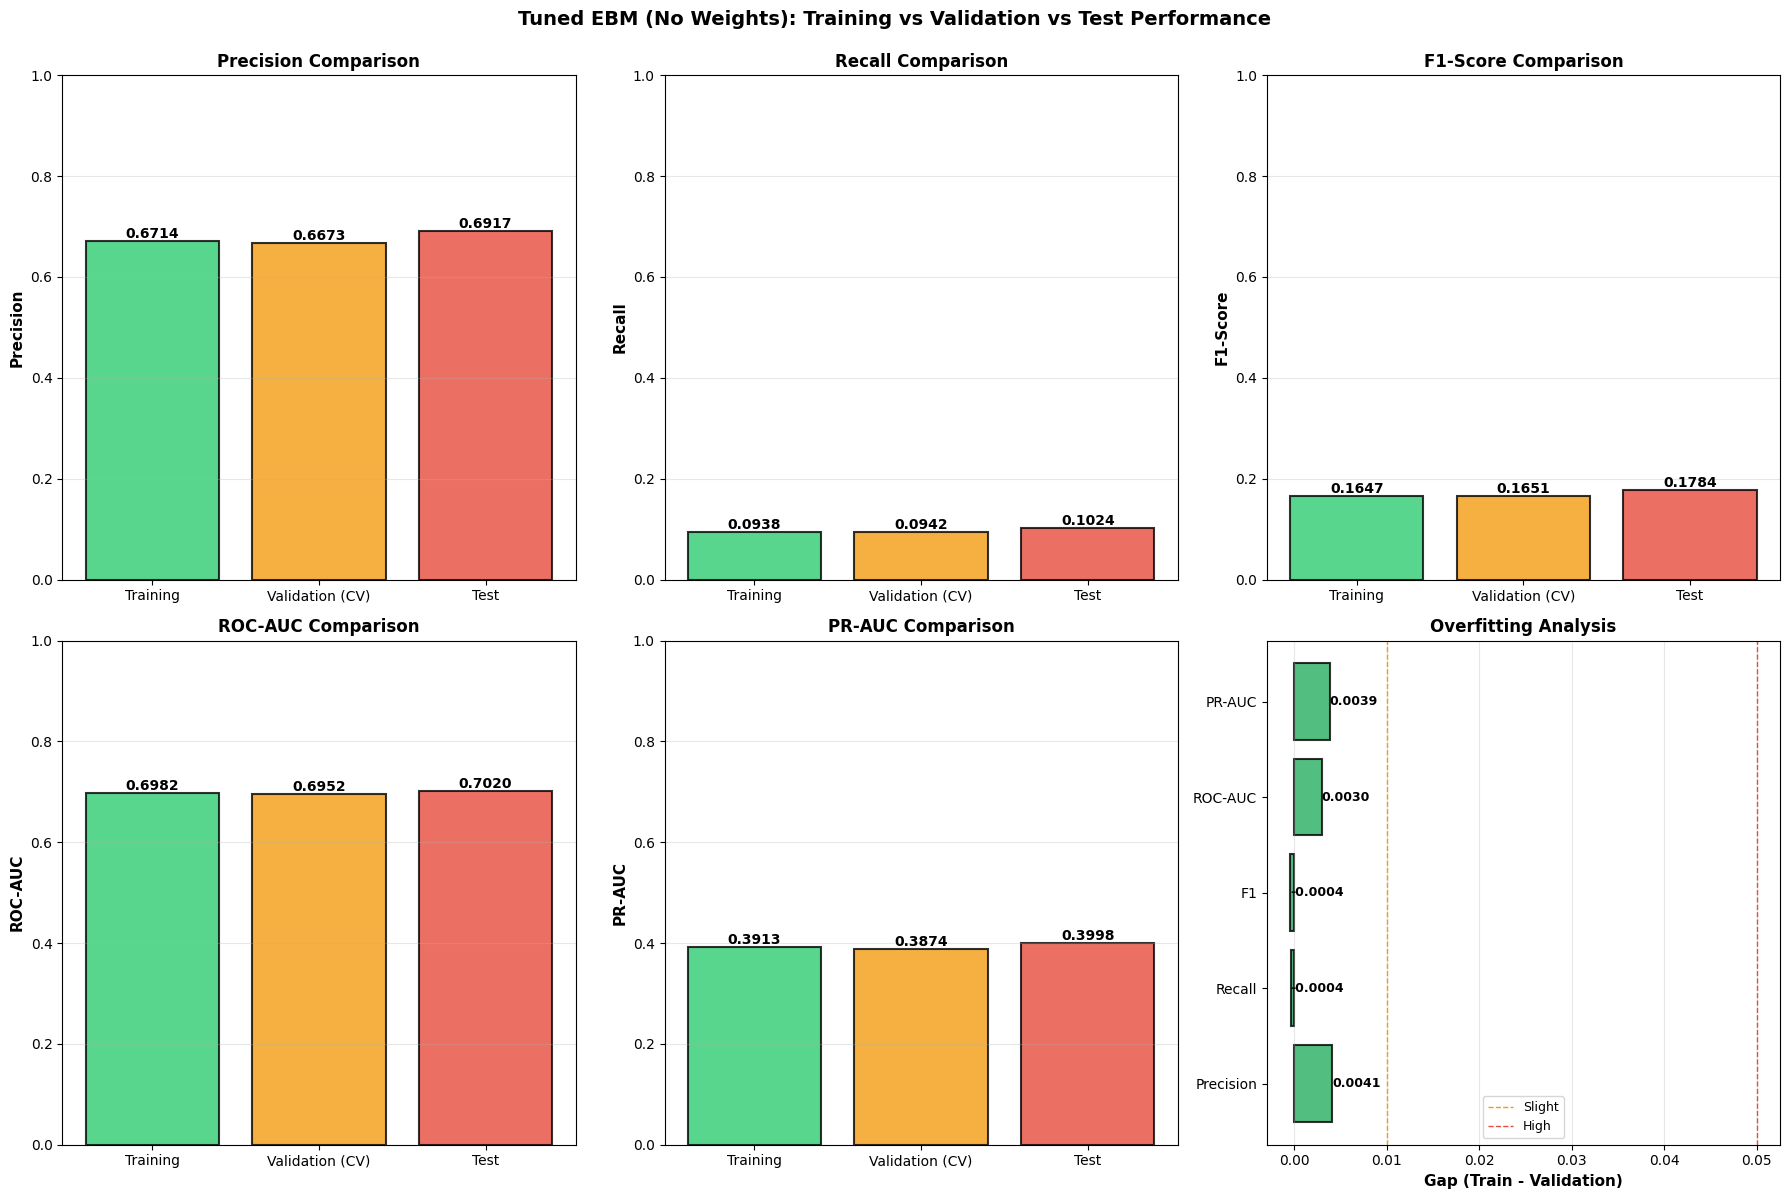


✓ SUMMARY

🎯 MODEL GENERALIZATION:
--------------------------------------------------------------------------------
  Status: ✓ EXCELLENT - Minimal overfitting
  Average gap (Train - Validation): 0.0020

🎯 VALIDATION-TEST ALIGNMENT:
--------------------------------------------------------------------------------
  Status: ✓ REASONABLE - Small difference between validation and test
  Average gap (Validation - Test): -0.0130



In [11]:
# =============================================================================
# TUNED EBM (NO WEIGHTS): TRAINING vs VALIDATION vs TEST COMPARISON
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                             roc_auc_score, average_precision_score,
                             confusion_matrix)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import matplotlib.pyplot as plt

print("="*80)
print("TUNED EBM (NO WEIGHTS): TRAIN vs VALIDATION vs TEST PERFORMANCE")
print("="*80)

# === STEP 1: GET VALIDATION METRICS (FROM CROSS-VALIDATION) ===
print("\n📋 STEP 1: EXTRACTING VALIDATION METRICS FROM CROSS-VALIDATION")
print("-" * 80)

# Use the already computed cross-validation predictions
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Recalculate training metrics using best_ebm
print("Computing training metrics on full training set...")
train_probas = best_ebm.predict_proba(X_train_final_encoded)[:, 1]
train_pred = (train_probas >= 0.5).astype(int)

train_precision = precision_score(y_train, train_pred, zero_division=0)
train_recall = recall_score(y_train, train_pred, zero_division=0)
train_f1 = f1_score(y_train, train_pred, zero_division=0)
train_roc_auc = roc_auc_score(y_train, train_probas)
train_pr_auc = average_precision_score(y_train, train_probas)

train_cm = confusion_matrix(y_train, train_pred)
train_tn, train_fp, train_fn, train_tp = train_cm.ravel()

print(f"✓ Training metrics computed (threshold=0.5)")

# Validation metrics (from cross-validation)
print("Computing validation metrics from cross-validation...")
val_probas = cross_val_predict(best_ebm, X_train_final_encoded, y_train, 
                               cv=cv_outer, method='predict_proba')[:, 1]
val_pred = (val_probas >= 0.5).astype(int)

val_precision = precision_score(y_train, val_pred, zero_division=0)
val_recall = recall_score(y_train, val_pred, zero_division=0)
val_f1 = f1_score(y_train, val_pred, zero_division=0)
val_roc_auc = roc_auc_score(y_train, val_probas)
val_pr_auc = average_precision_score(y_train, val_probas)

val_cm = confusion_matrix(y_train, val_pred)
val_tn, val_fp, val_fn, val_tp = val_cm.ravel()

print(f"✓ Validation metrics computed (5-fold CV, threshold=0.5)")

# Test metrics (already computed)
print("Using test metrics from previous evaluation...")
test_probas = ebm_test_probas
test_pred = (test_probas >= 0.5).astype(int)

test_precision = precision_score(y_test, test_pred, zero_division=0)
test_recall = recall_score(y_test, test_pred, zero_division=0)
test_f1 = f1_score(y_test, test_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, test_probas)
test_pr_auc = average_precision_score(y_test, test_probas)

test_cm = confusion_matrix(y_test, test_pred)
test_tn, test_fp, test_fn, test_tp = test_cm.ravel()

print(f"✓ Test metrics computed (threshold=0.5)")

# === STEP 2: CREATE COMPARISON TABLE ===
print("\n" + "="*80)
print("COMPREHENSIVE METRICS COMPARISON")
print("="*80)

comparison_data = {
    'Metric': [
        'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC',
        'True Negatives', 'False Positives', 'False Negatives', 'True Positives',
        'Specificity', 'Balanced Accuracy'
    ],
    'Training': [
        train_precision, train_recall, train_f1, train_roc_auc, train_pr_auc,
        train_tn, train_fp, train_fn, train_tp,
        train_tn / (train_tn + train_fp),
        (train_recall + train_tn / (train_tn + train_fp)) / 2
    ],
    'Validation (CV)': [
        val_precision, val_recall, val_f1, val_roc_auc, val_pr_auc,
        val_tn, val_fp, val_fn, val_tp,
        val_tn / (val_tn + val_fp),
        (val_recall + val_tn / (val_tn + val_fp)) / 2
    ],
    'Test': [
        test_precision, test_recall, test_f1, test_roc_auc, test_pr_auc,
        test_tn, test_fp, test_fn, test_tp,
        test_tn / (test_tn + test_fp),
        (test_recall + test_tn / (test_tn + test_fp)) / 2
    ]
}

comparison_df = pd.DataFrame(comparison_data)

# Format for display
print(f"\n{'Metric':<25} {'Training':>15} {'Validation':>15} {'Test':>15} {'Gap (T-V)':>12} {'Gap (V-Te)':>12}")
print("-" * 100)

for idx, row in comparison_df.iterrows():
    metric = row['Metric']
    train_val = row['Training']
    val_val = row['Validation (CV)']
    test_val = row['Test']
    
    # Only show gaps for non-count metrics
    if metric not in ['True Negatives', 'False Positives', 'False Negatives', 'True Positives']:
        gap_tv = train_val - val_val
        gap_vt = val_val - test_val
        print(f"{metric:<25} {train_val:>15.4f} {val_val:>15.4f} {test_val:>15.4f} {gap_tv:>12.4f} {gap_vt:>12.4f}")
    else:
        print(f"{metric:<25} {int(train_val):>15,} {int(val_val):>15,} {int(test_val):>15,}")

# === STEP 3: OVERFITTING ANALYSIS ===
print("\n" + "="*80)
print("OVERFITTING ANALYSIS (Training vs Validation)")
print("="*80)

metrics_to_check = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
print(f"\n{'Metric':<20} {'Training':>12} {'Validation':>12} {'Gap':>12} {'Status':>15}")
print("-" * 65)

for metric in metrics_to_check:
    row = comparison_df[comparison_df['Metric'] == metric].iloc[0]
    train_v = row['Training']
    val_v = row['Validation (CV)']
    gap = train_v - val_v
    
    # Determine overfitting status
    if gap > 0.05:
        status = "⚠️ Overfitting"
    elif gap > 0.01:
        status = "⚡ Slight OF"
    else:
        status = "✓ Good"
    
    print(f"{metric:<20} {train_v:>12.4f} {val_v:>12.4f} {gap:>12.4f} {status:>15}")

# === STEP 4: GENERALIZATION ANALYSIS ===
print("\n" + "="*80)
print("GENERALIZATION ANALYSIS (Validation vs Test)")
print("="*80)

print(f"\n{'Metric':<20} {'Validation':>12} {'Test':>12} {'Gap':>12} {'Status':>15}")
print("-" * 65)

for metric in metrics_to_check:
    row = comparison_df[comparison_df['Metric'] == metric].iloc[0]
    val_v = row['Validation (CV)']
    test_v = row['Test']
    gap = val_v - test_v
    
    # Determine generalization status (negative gap = worse on test = overgeneralized)
    if gap > 0.05:
        status = "⚠️ Worse on Test"
    elif gap > 0.01:
        status = "⚡ Slight Drop"
    else:
        status = "✓ Stable"
    
    print(f"{metric:<20} {val_v:>12.4f} {test_v:>12.4f} {gap:>12.4f} {status:>15}")

# === STEP 5: VISUALIZATIONS ===
print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Precision
ax1 = axes[0, 0]
metrics_plot = ['Training', 'Validation (CV)', 'Test']
precisions = [train_precision, val_precision, test_precision]
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars1 = ax1.bar(metrics_plot, precisions, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax1.set_title('Precision Comparison', fontsize=12, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, precisions):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Recall
ax2 = axes[0, 1]
recalls = [train_recall, val_recall, test_recall]
bars2 = ax2.bar(metrics_plot, recalls, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Recall', fontsize=11, fontweight='bold')
ax2.set_title('Recall Comparison', fontsize=12, fontweight='bold')
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, recalls):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: F1-Score
ax3 = axes[0, 2]
f1_scores = [train_f1, val_f1, test_f1]
bars3 = ax3.bar(metrics_plot, f1_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
ax3.set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
ax3.set_ylim([0, 1])
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, f1_scores):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 4: ROC-AUC
ax4 = axes[1, 0]
roc_aucs = [train_roc_auc, val_roc_auc, test_roc_auc]
bars4 = ax4.bar(metrics_plot, roc_aucs, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax4.set_ylabel('ROC-AUC', fontsize=11, fontweight='bold')
ax4.set_title('ROC-AUC Comparison', fontsize=12, fontweight='bold')
ax4.set_ylim([0, 1])
ax4.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars4, roc_aucs):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 5: PR-AUC
ax5 = axes[1, 1]
pr_aucs = [train_pr_auc, val_pr_auc, test_pr_auc]
bars5 = ax5.bar(metrics_plot, pr_aucs, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax5.set_ylabel('PR-AUC', fontsize=11, fontweight='bold')
ax5.set_title('PR-AUC Comparison', fontsize=12, fontweight='bold')
ax5.set_ylim([0, 1])
ax5.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars5, pr_aucs):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 6: Overfitting Gaps
ax6 = axes[1, 2]
gap_train_val = [train_precision - val_precision, 
                  train_recall - val_recall,
                  train_f1 - val_f1,
                  train_roc_auc - val_roc_auc,
                  train_pr_auc - val_pr_auc]
metric_names = ['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
colors_gap = ['#27ae60' if g < 0.01 else '#f39c12' if g < 0.05 else '#e74c3c' for g in gap_train_val]
bars6 = ax6.barh(metric_names, gap_train_val, color=colors_gap, alpha=0.8, edgecolor='black', linewidth=1.5)
ax6.axvline(x=0.01, color='#f39c12', linestyle='--', linewidth=1, label='Slight')
ax6.axvline(x=0.05, color='#e74c3c', linestyle='--', linewidth=1, label='High')
ax6.set_xlabel('Gap (Train - Validation)', fontsize=11, fontweight='bold')
ax6.set_title('Overfitting Analysis', fontsize=12, fontweight='bold')
ax6.legend(loc='best', fontsize=9)
ax6.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars6, gap_train_val):
    width = bar.get_width()
    ax6.text(width, bar.get_y() + bar.get_height()/2.,
            f'{val:.4f}', ha='left', va='center', fontweight='bold', fontsize=9)

fig.suptitle('Tuned EBM (No Weights): Training vs Validation vs Test Performance', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# === FINAL SUMMARY ===
print("\n" + "="*80)
print("✓ SUMMARY")
print("="*80)

print(f"\n🎯 MODEL GENERALIZATION:")
print("-" * 80)

overall_gap = np.mean(gap_train_val)
if overall_gap < 0.01:
    generalization = "✓ EXCELLENT - Minimal overfitting"
elif overall_gap < 0.05:
    generalization = "✓ GOOD - Slight overfitting"
else:
    generalization = "⚠️ MODERATE - Some overfitting detected"

print(f"  Status: {generalization}")
print(f"  Average gap (Train - Validation): {overall_gap:.4f}")

val_test_gap = np.mean([val_precision - test_precision,
                        val_recall - test_recall,
                        val_f1 - test_f1,
                        val_roc_auc - test_roc_auc,
                        val_pr_auc - test_pr_auc])

if abs(val_test_gap) < 0.01:
    stability = "✓ STABLE - Validation metrics align with test"
elif abs(val_test_gap) < 0.05:
    stability = "✓ REASONABLE - Small difference between validation and test"
else:
    stability = "⚠️ CAUTION - Notable difference between validation and test"

print(f"\n🎯 VALIDATION-TEST ALIGNMENT:")
print("-" * 80)
print(f"  Status: {stability}")
print(f"  Average gap (Validation - Test): {val_test_gap:.4f}")

print("\n" + "="*80)


# Threshold 0.8: Training vs Validation vs Test Performance

TUNED EBM (NO WEIGHTS) @ THRESHOLD 0.8: TRAIN vs VALIDATION vs TEST

📋 STEP 1: COMPUTING METRICS AT THRESHOLD 0.8
--------------------------------------------------------------------------------
Computing training metrics at threshold 0.8...
✓ Training metrics computed (threshold=0.8)
Computing validation metrics at threshold 0.8...
✓ Validation metrics computed (5-fold CV, threshold=0.8)
Computing test metrics at threshold 0.8...
✓ Test metrics computed (threshold=0.8)

COMPREHENSIVE METRICS COMPARISON @ THRESHOLD 0.8

Metric                           Training      Validation            Test    Gap (T-V)   Gap (V-Te)
----------------------------------------------------------------------------------------------------
Precision                          0.9619          0.9571          0.9408       0.0048       0.0163
Recall                             0.0291          0.0292          0.0333      -0.0001      -0.0041
F1-Score                           0.0565          0.0567          0.0643

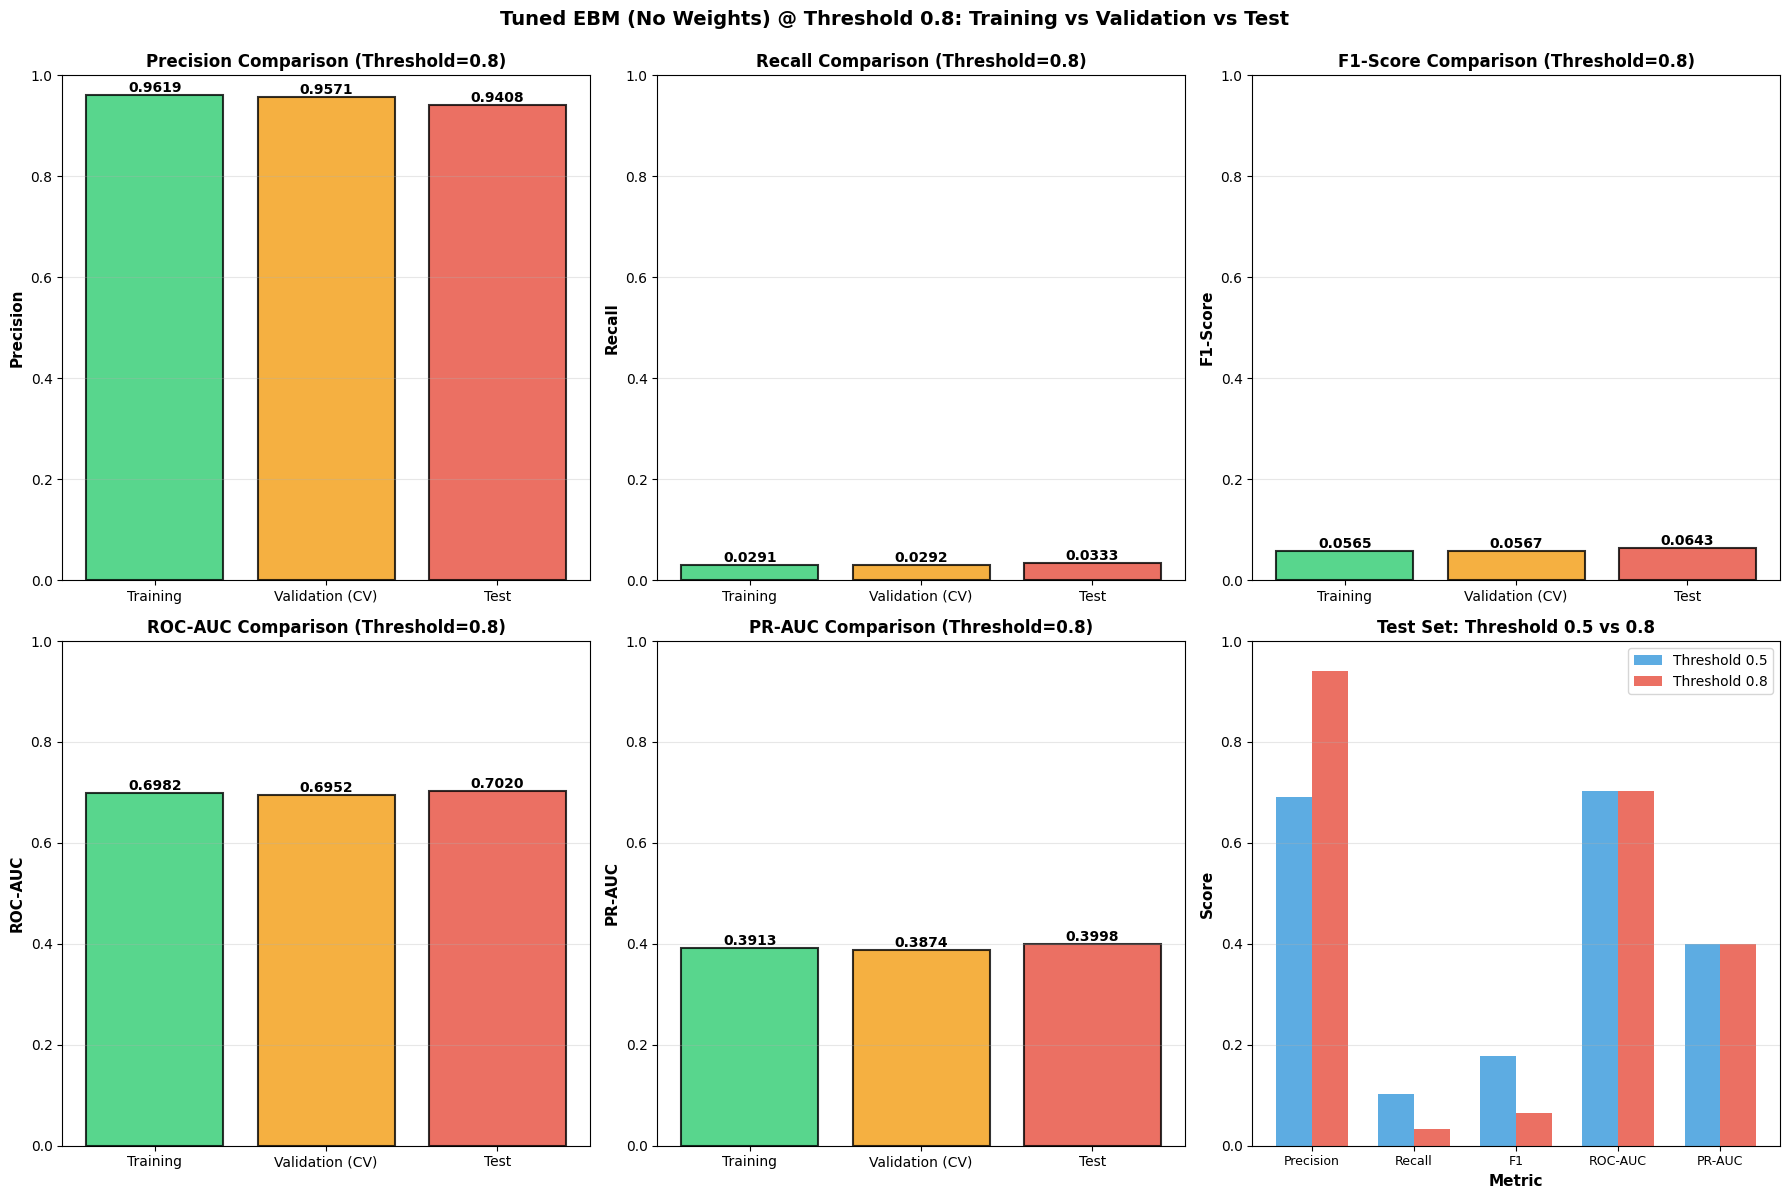


✓ SUMMARY @ THRESHOLD 0.8

🎯 MODEL GENERALIZATION:
--------------------------------------------------------------------------------
  Status: ✓ EXCELLENT - Minimal overfitting
  Average gap (Train - Validation): 0.0023

🎯 VALIDATION-TEST ALIGNMENT:
--------------------------------------------------------------------------------
  Status: ✓ STABLE - Validation metrics align with test
  Average gap (Validation - Test): -0.0029



In [12]:
# =============================================================================
# TUNED EBM (NO WEIGHTS) @ THRESHOLD 0.8: TRAINING vs VALIDATION vs TEST
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                             roc_auc_score, average_precision_score,
                             confusion_matrix)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import matplotlib.pyplot as plt

print("="*80)
print("TUNED EBM (NO WEIGHTS) @ THRESHOLD 0.8: TRAIN vs VALIDATION vs TEST")
print("="*80)

# === STEP 1: GET METRICS AT THRESHOLD 0.8 ===
print("\n📋 STEP 1: COMPUTING METRICS AT THRESHOLD 0.8")
print("-" * 80)

# Training metrics
print("Computing training metrics at threshold 0.8...")
train_pred_08 = (train_probas >= 0.8).astype(int)

train_precision_08 = precision_score(y_train, train_pred_08, zero_division=0)
train_recall_08 = recall_score(y_train, train_pred_08, zero_division=0)
train_f1_08 = f1_score(y_train, train_pred_08, zero_division=0)
train_roc_auc_08 = roc_auc_score(y_train, train_probas)  # ROC-AUC doesn't depend on threshold
train_pr_auc_08 = average_precision_score(y_train, train_probas)

train_cm_08 = confusion_matrix(y_train, train_pred_08)
train_tn_08, train_fp_08, train_fn_08, train_tp_08 = train_cm_08.ravel()

print(f"✓ Training metrics computed (threshold=0.8)")

# Validation metrics (from cross-validation)
print("Computing validation metrics at threshold 0.8...")
val_pred_08 = (val_probas >= 0.8).astype(int)

val_precision_08 = precision_score(y_train, val_pred_08, zero_division=0)
val_recall_08 = recall_score(y_train, val_pred_08, zero_division=0)
val_f1_08 = f1_score(y_train, val_pred_08, zero_division=0)
val_roc_auc_08 = roc_auc_score(y_train, val_probas)
val_pr_auc_08 = average_precision_score(y_train, val_probas)

val_cm_08 = confusion_matrix(y_train, val_pred_08)
val_tn_08, val_fp_08, val_fn_08, val_tp_08 = val_cm_08.ravel()

print(f"✓ Validation metrics computed (5-fold CV, threshold=0.8)")

# Test metrics
print("Computing test metrics at threshold 0.8...")
test_pred_08 = (test_probas >= 0.8).astype(int)

test_precision_08 = precision_score(y_test, test_pred_08, zero_division=0)
test_recall_08 = recall_score(y_test, test_pred_08, zero_division=0)
test_f1_08 = f1_score(y_test, test_pred_08, zero_division=0)
test_roc_auc_08 = roc_auc_score(y_test, test_probas)
test_pr_auc_08 = average_precision_score(y_test, test_probas)

test_cm_08 = confusion_matrix(y_test, test_pred_08)
test_tn_08, test_fp_08, test_fn_08, test_tp_08 = test_cm_08.ravel()

print(f"✓ Test metrics computed (threshold=0.8)")

# === STEP 2: CREATE COMPARISON TABLE ===
print("\n" + "="*80)
print("COMPREHENSIVE METRICS COMPARISON @ THRESHOLD 0.8")
print("="*80)

comparison_data_08 = {
    'Metric': [
        'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC',
        'True Negatives', 'False Positives', 'False Negatives', 'True Positives',
        'Specificity', 'Balanced Accuracy'
    ],
    'Training': [
        train_precision_08, train_recall_08, train_f1_08, train_roc_auc_08, train_pr_auc_08,
        train_tn_08, train_fp_08, train_fn_08, train_tp_08,
        train_tn_08 / (train_tn_08 + train_fp_08) if (train_tn_08 + train_fp_08) > 0 else 0,
        (train_recall_08 + train_tn_08 / (train_tn_08 + train_fp_08)) / 2 if (train_tn_08 + train_fp_08) > 0 else 0
    ],
    'Validation (CV)': [
        val_precision_08, val_recall_08, val_f1_08, val_roc_auc_08, val_pr_auc_08,
        val_tn_08, val_fp_08, val_fn_08, val_tp_08,
        val_tn_08 / (val_tn_08 + val_fp_08) if (val_tn_08 + val_fp_08) > 0 else 0,
        (val_recall_08 + val_tn_08 / (val_tn_08 + val_fp_08)) / 2 if (val_tn_08 + val_fp_08) > 0 else 0
    ],
    'Test': [
        test_precision_08, test_recall_08, test_f1_08, test_roc_auc_08, test_pr_auc_08,
        test_tn_08, test_fp_08, test_fn_08, test_tp_08,
        test_tn_08 / (test_tn_08 + test_fp_08) if (test_tn_08 + test_fp_08) > 0 else 0,
        (test_recall_08 + test_tn_08 / (test_tn_08 + test_fp_08)) / 2 if (test_tn_08 + test_fp_08) > 0 else 0
    ]
}

comparison_df_08 = pd.DataFrame(comparison_data_08)

# Format for display
print(f"\n{'Metric':<25} {'Training':>15} {'Validation':>15} {'Test':>15} {'Gap (T-V)':>12} {'Gap (V-Te)':>12}")
print("-" * 100)

for idx, row in comparison_df_08.iterrows():
    metric = row['Metric']
    train_val = row['Training']
    val_val = row['Validation (CV)']
    test_val = row['Test']
    
    # Only show gaps for non-count metrics
    if metric not in ['True Negatives', 'False Positives', 'False Negatives', 'True Positives']:
        gap_tv = train_val - val_val
        gap_vt = val_val - test_val
        print(f"{metric:<25} {train_val:>15.4f} {val_val:>15.4f} {test_val:>15.4f} {gap_tv:>12.4f} {gap_vt:>12.4f}")
    else:
        print(f"{metric:<25} {int(train_val):>15,} {int(val_val):>15,} {int(test_val):>15,}")

# === STEP 3: SIDE-BY-SIDE COMPARISON (0.5 vs 0.8) ===
print("\n" + "="*80)
print("SIDE-BY-SIDE: THRESHOLD 0.5 vs 0.8 (TEST SET)")
print("="*80)

print(f"\n{'Metric':<20} {'@ Threshold 0.5':>20} {'@ Threshold 0.8':>20} {'Change':>15}")
print("-" * 80)

metrics_compare = [
    ('Precision', test_precision, test_precision_08),
    ('Recall', test_recall, test_recall_08),
    ('F1-Score', test_f1, test_f1_08),
    ('ROC-AUC', test_roc_auc, test_roc_auc_08),
    ('PR-AUC', test_pr_auc, test_pr_auc_08),
]

for metric_name, val_05, val_08 in metrics_compare:
    change = val_08 - val_05
    direction = "↑" if change > 0 else "↓" if change < 0 else "="
    print(f"{metric_name:<20} {val_05:>20.4f} {val_08:>20.4f} {direction} {abs(change):>13.4f}")

# === STEP 4: OVERFITTING ANALYSIS ===
print("\n" + "="*80)
print("OVERFITTING ANALYSIS @ THRESHOLD 0.8 (Training vs Validation)")
print("="*80)

metrics_to_check_08 = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
print(f"\n{'Metric':<20} {'Training':>12} {'Validation':>12} {'Gap':>12} {'Status':>15}")
print("-" * 65)

gap_train_val_08 = []
for metric in metrics_to_check_08:
    row = comparison_df_08[comparison_df_08['Metric'] == metric].iloc[0]
    train_v = row['Training']
    val_v = row['Validation (CV)']
    gap = train_v - val_v
    gap_train_val_08.append(gap)
    
    if gap > 0.05:
        status = "⚠️ Overfitting"
    elif gap > 0.01:
        status = "⚡ Slight OF"
    else:
        status = "✓ Good"
    
    print(f"{metric:<20} {train_v:>12.4f} {val_v:>12.4f} {gap:>12.4f} {status:>15}")

# === STEP 5: VISUALIZATIONS ===
print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Precision
ax1 = axes[0, 0]
metrics_plot = ['Training', 'Validation (CV)', 'Test']
precisions_08 = [train_precision_08, val_precision_08, test_precision_08]
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars1 = ax1.bar(metrics_plot, precisions_08, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax1.set_title('Precision Comparison (Threshold=0.8)', fontsize=12, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, precisions_08):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Recall
ax2 = axes[0, 1]
recalls_08 = [train_recall_08, val_recall_08, test_recall_08]
bars2 = ax2.bar(metrics_plot, recalls_08, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Recall', fontsize=11, fontweight='bold')
ax2.set_title('Recall Comparison (Threshold=0.8)', fontsize=12, fontweight='bold')
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, recalls_08):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: F1-Score
ax3 = axes[0, 2]
f1_scores_08 = [train_f1_08, val_f1_08, test_f1_08]
bars3 = ax3.bar(metrics_plot, f1_scores_08, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
ax3.set_title('F1-Score Comparison (Threshold=0.8)', fontsize=12, fontweight='bold')
ax3.set_ylim([0, 1])
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, f1_scores_08):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 4: ROC-AUC
ax4 = axes[1, 0]
roc_aucs_08 = [train_roc_auc_08, val_roc_auc_08, test_roc_auc_08]
bars4 = ax4.bar(metrics_plot, roc_aucs_08, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax4.set_ylabel('ROC-AUC', fontsize=11, fontweight='bold')
ax4.set_title('ROC-AUC Comparison (Threshold=0.8)', fontsize=12, fontweight='bold')
ax4.set_ylim([0, 1])
ax4.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars4, roc_aucs_08):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 5: PR-AUC
ax5 = axes[1, 1]
pr_aucs_08 = [train_pr_auc_08, val_pr_auc_08, test_pr_auc_08]
bars5 = ax5.bar(metrics_plot, pr_aucs_08, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax5.set_ylabel('PR-AUC', fontsize=11, fontweight='bold')
ax5.set_title('PR-AUC Comparison (Threshold=0.8)', fontsize=12, fontweight='bold')
ax5.set_ylim([0, 1])
ax5.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars5, pr_aucs_08):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 6: Threshold Comparison (0.5 vs 0.8) on Test Set
ax6 = axes[1, 2]
threshold_labels = ['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
x_pos_thresh = np.arange(len(threshold_labels))
width_thresh = 0.35

test_metrics_05 = [test_precision, test_recall, test_f1, test_roc_auc, test_pr_auc]
test_metrics_08 = [test_precision_08, test_recall_08, test_f1_08, test_roc_auc_08, test_pr_auc_08]

bars_05 = ax6.bar(x_pos_thresh - width_thresh/2, test_metrics_05, width_thresh, 
                   label='Threshold 0.5', color='#3498db', alpha=0.8)
bars_08 = ax6.bar(x_pos_thresh + width_thresh/2, test_metrics_08, width_thresh, 
                   label='Threshold 0.8', color='#e74c3c', alpha=0.8)

ax6.set_xlabel('Metric', fontsize=11, fontweight='bold')
ax6.set_ylabel('Score', fontsize=11, fontweight='bold')
ax6.set_title('Test Set: Threshold 0.5 vs 0.8', fontsize=12, fontweight='bold')
ax6.set_xticks(x_pos_thresh)
ax6.set_xticklabels(threshold_labels, fontsize=9)
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3, axis='y')
ax6.set_ylim([0, 1])

fig.suptitle('Tuned EBM (No Weights) @ Threshold 0.8: Training vs Validation vs Test', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# === FINAL SUMMARY ===
print("\n" + "="*80)
print("✓ SUMMARY @ THRESHOLD 0.8")
print("="*80)

overall_gap_08 = np.mean(gap_train_val_08)
if overall_gap_08 < 0.01:
    generalization_08 = "✓ EXCELLENT - Minimal overfitting"
elif overall_gap_08 < 0.05:
    generalization_08 = "✓ GOOD - Slight overfitting"
else:
    generalization_08 = "⚠️ MODERATE - Some overfitting detected"

print(f"\n🎯 MODEL GENERALIZATION:")
print("-" * 80)
print(f"  Status: {generalization_08}")
print(f"  Average gap (Train - Validation): {overall_gap_08:.4f}")

val_test_gap_08 = np.mean([val_precision_08 - test_precision_08,
                           val_recall_08 - test_recall_08,
                           val_f1_08 - test_f1_08,
                           val_roc_auc_08 - test_roc_auc_08,
                           val_pr_auc_08 - test_pr_auc_08])

if abs(val_test_gap_08) < 0.01:
    stability_08 = "✓ STABLE - Validation metrics align with test"
elif abs(val_test_gap_08) < 0.05:
    stability_08 = "✓ REASONABLE - Small difference between validation and test"
else:
    stability_08 = "⚠️ CAUTION - Notable difference between validation and test"

print(f"\n🎯 VALIDATION-TEST ALIGNMENT:")
print("-" * 80)
print(f"  Status: {stability_08}")
print(f"  Average gap (Validation - Test): {val_test_gap_08:.4f}")

print("\n" + "="*80)


In [15]:
# =============================================================================
# EXTENDED COMPARISON TABLE: TRAIN vs VALIDATION vs TEST
# Including Specificity, Pred. Pos % of Dataset, and Pred. Pos (ABS)
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                             roc_auc_score, average_precision_score,
                             confusion_matrix)
from sklearn.model_selection import StratifiedKFold, cross_val_predict

print("="*100)
print("EXTENDED COMPARISON: TUNED EBM (NO WEIGHTS) - TRAIN vs VALIDATION vs TEST (THRESHOLD 0.8)")
print("="*100)

# === STEP 1: GET VALIDATION METRICS (FROM CROSS-VALIDATION) ===
print("\n📋 STEP 1: COMPUTING METRICS (THRESHOLD 0.8)")
print("-" * 100)

# Training metrics
print("Computing training metrics on full training set...")
train_probas = best_ebm.predict_proba(X_train_final_encoded)[:, 1]
train_pred = (train_probas >= 0.8).astype(int)

train_precision = precision_score(y_train, train_pred, zero_division=0)
train_recall = recall_score(y_train, train_pred, zero_division=0)
train_f1 = f1_score(y_train, train_pred, zero_division=0)
train_roc_auc = roc_auc_score(y_train, train_probas)
train_pr_auc = average_precision_score(y_train, train_probas)

train_cm = confusion_matrix(y_train, train_pred)
train_tn, train_fp, train_fn, train_tp = train_cm.ravel()
train_specificity = train_tn / (train_tn + train_fp) if (train_tn + train_fp) > 0 else 0
train_balanced_acc = (train_recall + train_specificity) / 2

train_pred_pos = train_pred.sum()
train_pred_pos_pct = (train_pred_pos / len(y_train)) * 100

print(f"✓ Training metrics computed (threshold=0.8)")

# Validation metrics (using already computed cross-validated probabilities)
print("Using validation metrics from previously computed cross-validation...")
val_probas = ebm_tuned_probas
val_pred = (val_probas >= 0.8).astype(int)

val_precision = precision_score(y_train, val_pred, zero_division=0)
val_recall = recall_score(y_train, val_pred, zero_division=0)
val_f1 = f1_score(y_train, val_pred, zero_division=0)
val_roc_auc = roc_auc_score(y_train, val_probas)
val_pr_auc = average_precision_score(y_train, val_probas)

val_cm = confusion_matrix(y_train, val_pred)
val_tn, val_fp, val_fn, val_tp = val_cm.ravel()
val_specificity = val_tn / (val_tn + val_fp) if (val_tn + val_fp) > 0 else 0
val_balanced_acc = (val_recall + val_specificity) / 2

val_pred_pos = val_pred.sum()
val_pred_pos_pct = (val_pred_pos / len(y_train)) * 100

print(f"✓ Validation metrics computed (5-fold CV, threshold=0.8)")

# Test metrics
print("Using test metrics from previous evaluation...")
test_probas = loaded_ebm.predict_proba(X_test)[:, 1]
test_pred = (test_probas >= 0.8).astype(int)

test_precision = precision_score(y_test, test_pred, zero_division=0)
test_recall = recall_score(y_test, test_pred, zero_division=0)
test_f1 = f1_score(y_test, test_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, test_probas)
test_pr_auc = average_precision_score(y_test, test_probas)

test_cm = confusion_matrix(y_test, test_pred)
test_tn, test_fp, test_fn, test_tp = test_cm.ravel()
test_specificity = test_tn / (test_tn + test_fp) if (test_tn + test_fp) > 0 else 0
test_balanced_acc = (test_recall + test_specificity) / 2

test_pred_pos = test_pred.sum()
test_pred_pos_pct = (test_pred_pos / len(y_test)) * 100

print(f"✓ Test metrics computed (threshold=0.8)")

# === STEP 2: CREATE EXTENDED COMPARISON TABLE ===
print("\n" + "="*100)
print("COMPREHENSIVE METRICS COMPARISON TABLE")
print("="*100)

# Create DataFrame with extended metrics
comparison_data = {
    'Metric': [
        'Precision', 'Recall', 'F1-Score', 'Specificity', 'Balanced Accuracy',
        'ROC-AUC', 'PR-AUC',
        'Pred. Pos (ABS)', 'Pred. Pos % of Dataset'
    ],
    'Training': [
        train_precision, train_recall, train_f1, train_specificity, train_balanced_acc,
        train_roc_auc, train_pr_auc,
        train_pred_pos, train_pred_pos_pct
    ],
    'Validation (CV)': [
        val_precision, val_recall, val_f1, val_specificity, val_balanced_acc,
        val_roc_auc, val_pr_auc,
        val_pred_pos, val_pred_pos_pct
    ],
    'Test': [
        test_precision, test_recall, test_f1, test_specificity, test_balanced_acc,
        test_roc_auc, test_pr_auc,
        test_pred_pos, test_pred_pos_pct
    ]
}

comparison_df = pd.DataFrame(comparison_data)

# Display the table with proper formatting
print(f"\n{'Metric':<25} {'Training':>15} {'Validation':>15} {'Test':>15} {'Gap (T-V)':>12} {'Gap (V-Te)':>12}")
print("-" * 110)

for idx, row in comparison_df.iterrows():
    metric = row['Metric']
    train_val = row['Training']
    val_val = row['Validation (CV)']
    test_val = row['Test']
    
    # Different formatting for count vs percentage metrics
    if metric in ['Pred. Pos (ABS)']:
        print(f"{metric:<25} {int(train_val):>15,} {int(val_val):>15,} {int(test_val):>15,}")
    elif metric in ['Pred. Pos % of Dataset']:
        gap_tv = train_val - val_val
        gap_vt = val_val - test_val
        print(f"{metric:<25} {train_val:>14.2f}% {val_val:>14.2f}% {test_val:>14.2f}% {gap_tv:>11.2f}% {gap_vt:>11.2f}%")
    else:
        gap_tv = train_val - val_val
        gap_vt = val_val - test_val
        print(f"{metric:<25} {train_val:>15.4f} {val_val:>15.4f} {test_val:>15.4f} {gap_tv:>12.4f} {gap_vt:>12.4f}")

print("-" * 110)

# === STEP 3: SUMMARY STATISTICS ===
print("\n" + "="*100)
print("KEY INSIGHTS")
print("="*100)

print(f"\n📊 PREDICTION DISTRIBUTION (Threshold 0.8):")
print("-" * 100)
print(f"Training Set:")
print(f"  • Predicted Positive: {train_pred_pos:>10,} ({train_pred_pos_pct:>6.2f}%)")
print(f"  • Predicted Negative: {len(y_train) - train_pred_pos:>10,} ({100 - train_pred_pos_pct:>6.2f}%)")

print(f"\nValidation Set (5-fold CV):")
print(f"  • Predicted Positive: {val_pred_pos:>10,} ({val_pred_pos_pct:>6.2f}%)")
print(f"  • Predicted Negative: {len(y_train) - val_pred_pos:>10,} ({100 - val_pred_pos_pct:>6.2f}%)")

print(f"\nTest Set:")
print(f"  • Predicted Positive: {test_pred_pos:>10,} ({test_pred_pos_pct:>6.2f}%)")
print(f"  • Predicted Negative: {len(y_test) - test_pred_pos:>10,} ({100 - test_pred_pos_pct:>6.2f}%)")

print(f"\n📈 SPECIFICITY ANALYSIS:")
print("-" * 100)
print(f"{'Set':<20} {'Specificity':>15} {'True Negatives':>20} {'False Positives':>20}")
print(f"{'Training':<20} {train_specificity:>15.4f} {train_tn:>20,} {train_fp:>20,}")
print(f"{'Validation (CV)':<20} {val_specificity:>15.4f} {val_tn:>20,} {val_fp:>20,}")
print(f"{'Test':<20} {test_specificity:>15.4f} {test_tn:>20,} {test_fp:>20,}")

print("\n" + "="*100)
print("✓ EXTENDED COMPARISON TABLE COMPLETE")
print("="*100)


EXTENDED COMPARISON: TUNED EBM (NO WEIGHTS) - TRAIN vs VALIDATION vs TEST (THRESHOLD 0.8)

📋 STEP 1: COMPUTING METRICS (THRESHOLD 0.8)
----------------------------------------------------------------------------------------------------
Computing training metrics on full training set...
✓ Training metrics computed (threshold=0.8)
Using validation metrics from previously computed cross-validation...
✓ Validation metrics computed (5-fold CV, threshold=0.8)
Using test metrics from previous evaluation...
✓ Test metrics computed (threshold=0.8)

COMPREHENSIVE METRICS COMPARISON TABLE

Metric                           Training      Validation            Test    Gap (T-V)   Gap (V-Te)
--------------------------------------------------------------------------------------------------------------
Precision                          0.9619          0.9571          0.9408       0.0048       0.0163
Recall                             0.0291          0.0292          0.0333      -0.0001      -0.0041
F1-

In [16]:
# =============================================================================
# WORD-FRIENDLY EXPORT: EXTENDED COMPARISON TABLE (THRESHOLD 0.8)
# =============================================================================

print("\n" + "="*110)
print("WORD-FRIENDLY EXPORT: Extended Comparison Table (Threshold 0.8)")
print("="*110)

print("\n1️⃣  TAB-SEPARATED FORMAT (Copy & paste into Word, then use Table > Convert > Text to Table):\n")

# Create tab-separated version
print("Metric\tTraining\tValidation\tTest\tGap (T-V)\tGap (V-Te)")

metrics_list = [
    ('Precision', train_precision, val_precision, test_precision),
    ('Recall', train_recall, val_recall, test_recall),
    ('F1-Score', train_f1, val_f1, test_f1),
    ('Specificity', train_specificity, val_specificity, test_specificity),
    ('Balanced Accuracy', train_balanced_acc, val_balanced_acc, test_balanced_acc),
    ('ROC-AUC', train_roc_auc, val_roc_auc, test_roc_auc),
    ('PR-AUC', train_pr_auc, val_pr_auc, test_pr_auc),
    ('Pred. Pos (ABS)', train_pred_pos, val_pred_pos, test_pred_pos),
    ('Pred. Pos % of Dataset', train_pred_pos_pct, val_pred_pos_pct, test_pred_pos_pct),
]

for metric_name, train_val, val_val, test_val in metrics_list:
    if metric_name in ['Pred. Pos (ABS)']:
        print(f"{metric_name}\t{int(train_val)}\t{int(val_val)}\t{int(test_val)}")
    elif metric_name in ['Pred. Pos % of Dataset']:
        gap_tv = train_val - val_val
        gap_vt = val_val - test_val
        print(f"{metric_name}\t{train_val:.2f}%\t{val_val:.2f}%\t{test_val:.2f}%\t{gap_tv:.2f}%\t{gap_vt:.2f}%")
    else:
        gap_tv = train_val - val_val
        gap_vt = val_val - test_val
        print(f"{metric_name}\t{train_val:.4f}\t{val_val:.4f}\t{test_val:.4f}\t{gap_tv:.4f}\t{gap_vt:.4f}")

print("\n" + "="*110)
print("\n2️⃣  MARKDOWN FORMAT (for documentation):\n")

print("| Metric | Training | Validation | Test | Gap (T-V) | Gap (V-Te) |")
print("|--------|----------|-----------|------|-----------|-----------|")

for metric_name, train_val, val_val, test_val in metrics_list:
    if metric_name in ['Pred. Pos (ABS)']:
        print(f"| {metric_name} | {int(train_val):,} | {int(val_val):,} | {int(test_val):,} | - | - |")
    elif metric_name in ['Pred. Pos % of Dataset']:
        gap_tv = train_val - val_val
        gap_vt = val_val - test_val
        print(f"| {metric_name} | {train_val:.2f}% | {val_val:.2f}% | {test_val:.2f}% | {gap_tv:.2f}% | {gap_vt:.2f}% |")
    else:
        gap_tv = train_val - val_val
        gap_vt = val_val - test_val
        print(f"| {metric_name} | {train_val:.4f} | {val_val:.4f} | {test_val:.4f} | {gap_tv:.4f} | {gap_vt:.4f} |")

print("\n" + "="*110)
print("✓ WORD-FRIENDLY FORMATS READY FOR COPY-PASTE")
print("="*110)



WORD-FRIENDLY EXPORT: Extended Comparison Table (Threshold 0.8)

1️⃣  TAB-SEPARATED FORMAT (Copy & paste into Word, then use Table > Convert > Text to Table):

Metric	Training	Validation	Test	Gap (T-V)	Gap (V-Te)
Precision	0.9619	0.9571	0.9408	0.0048	0.0163
Recall	0.0291	0.0292	0.0333	-0.0001	-0.0041
F1-Score	0.0565	0.0567	0.0643	-0.0002	-0.0076
Specificity	0.9997	0.9997	0.9995	0.0000	0.0002
Balanced Accuracy	0.5144	0.5145	0.5164	-0.0000	-0.0020
ROC-AUC	0.6982	0.6952	0.7020	0.0030	-0.0068
PR-AUC	0.3913	0.3874	0.3998	0.0039	-0.0124
Pred. Pos (ABS)	578	583	169
Pred. Pos % of Dataset	0.55%	0.55%	0.64%	-0.00%	-0.09%


2️⃣  MARKDOWN FORMAT (for documentation):

| Metric | Training | Validation | Test | Gap (T-V) | Gap (V-Te) |
|--------|----------|-----------|------|-----------|-----------|
| Precision | 0.9619 | 0.9571 | 0.9408 | 0.0048 | 0.0163 |
| Recall | 0.0291 | 0.0292 | 0.0333 | -0.0001 | -0.0041 |
| F1-Score | 0.0565 | 0.0567 | 0.0643 | -0.0002 | -0.0076 |
| Specificity | 0.9997 | 

CONFUSION MATRIX: EBM MODEL ON TEST SET (THRESHOLD 0.8)

📊 CONFUSION MATRIX BREAKDOWN:
--------------------------------------------------------------------------------
True Negatives (TN):      21,692  |  Correctly predicted negative cases
False Positives (FP):         10  |  Incorrectly predicted as positive
False Negatives (FN):      4,616  |  Incorrectly predicted as negative
True Positives (TP):         159  |  Correctly predicted positive cases
--------------------------------------------------------------------------------
Total Test Samples:       26,477

📈 PERFORMANCE METRICS (THRESHOLD 0.8):
--------------------------------------------------------------------------------
Precision..................... 0.9408  (TP / (TP + FP))
Recall (Sensitivity).......... 0.0333  (TP / (TP + FN))
Specificity................... 0.9995  (TN / (TN + FP))
F1-Score...................... 0.0643  (Harmonic mean of precision & recall)
Balanced Accuracy............. 0.5164  (Average of sensitivity & s

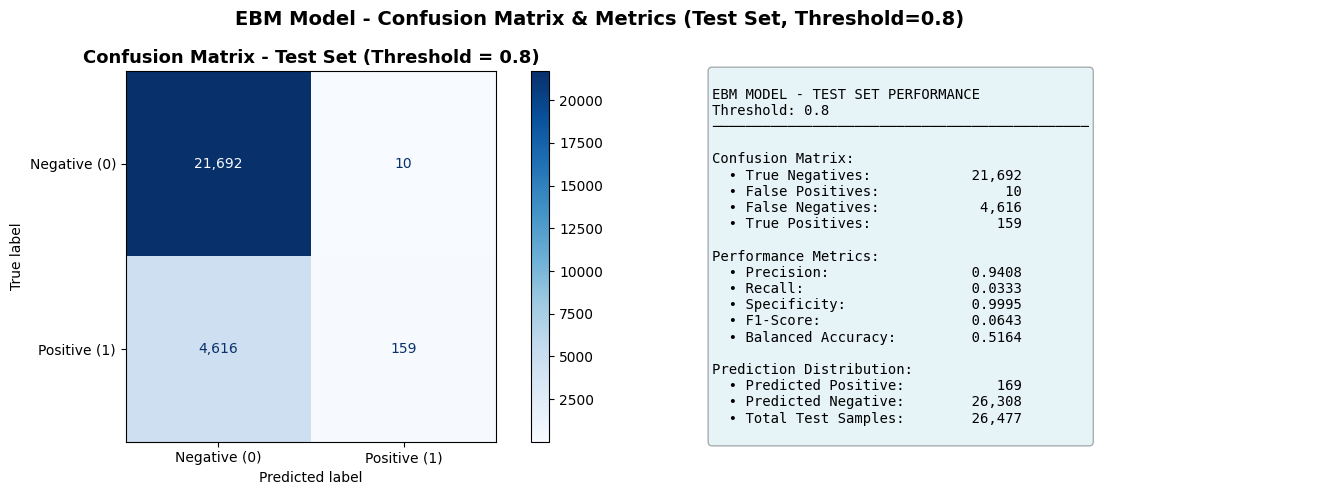


✓ CONFUSION MATRIX ANALYSIS COMPLETE


In [17]:
# =============================================================================
# CONFUSION MATRIX: EBM MODEL ON TEST SET (THRESHOLD 0.8)
# =============================================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

print("="*80)
print("CONFUSION MATRIX: EBM MODEL ON TEST SET (THRESHOLD 0.8)")
print("="*80)

# Generate predictions at threshold 0.8
threshold_08 = 0.8
test_probas_08 = loaded_ebm.predict_proba(X_test)[:, 1]
test_pred_08 = (test_probas_08 >= threshold_08).astype(int)

# Calculate confusion matrix
cm_test_08 = confusion_matrix(y_test, test_pred_08)
tn_08, fp_08, fn_08, tp_08 = cm_test_08.ravel()

# Calculate metrics
precision_08 = tp_08 / (tp_08 + fp_08) if (tp_08 + fp_08) > 0 else 0
recall_08 = tp_08 / (tp_08 + fn_08) if (tp_08 + fn_08) > 0 else 0
f1_08 = 2 * precision_08 * recall_08 / (precision_08 + recall_08) if (precision_08 + recall_08) > 0 else 0
specificity_08 = tn_08 / (tn_08 + fp_08) if (tn_08 + fp_08) > 0 else 0
balanced_acc_08 = (recall_08 + specificity_08) / 2

print("\n📊 CONFUSION MATRIX BREAKDOWN:")
print("-" * 80)
print(f"True Negatives (TN):  {tn_08:>10,}  |  Correctly predicted negative cases")
print(f"False Positives (FP): {fp_08:>10,}  |  Incorrectly predicted as positive")
print(f"False Negatives (FN): {fn_08:>10,}  |  Incorrectly predicted as negative")
print(f"True Positives (TP):  {tp_08:>10,}  |  Correctly predicted positive cases")
print("-" * 80)
print(f"Total Test Samples:   {len(y_test):>10,}")

print("\n📈 PERFORMANCE METRICS (THRESHOLD 0.8):")
print("-" * 80)
print(f"{'Precision':.<30} {precision_08:.4f}  (TP / (TP + FP))")
print(f"{'Recall (Sensitivity)':.<30} {recall_08:.4f}  (TP / (TP + FN))")
print(f"{'Specificity':.<30} {specificity_08:.4f}  (TN / (TN + FP))")
print(f"{'F1-Score':.<30} {f1_08:.4f}  (Harmonic mean of precision & recall)")
print(f"{'Balanced Accuracy':.<30} {balanced_acc_08:.4f}  (Average of sensitivity & specificity)")

print("\n📋 CLASSIFICATION REPORT:")
print("-" * 80)
print(classification_report(y_test, test_pred_08, target_names=['Negative (0)', 'Positive (1)']))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Confusion Matrix Heatmap
ax1 = axes[0]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test_08, 
                              display_labels=['Negative (0)', 'Positive (1)'])
disp.plot(ax=ax1, cmap='Blues', values_format=',d')
ax1.set_title('Confusion Matrix - Test Set (Threshold = 0.8)', fontsize=13, fontweight='bold')

# Plot 2: Metrics Summary
ax2 = axes[1]
ax2.axis('off')

metrics_summary = f"""
EBM MODEL - TEST SET PERFORMANCE
Threshold: 0.8
{'─' * 45}

Confusion Matrix:
  • True Negatives:        {tn_08:>10,}
  • False Positives:       {fp_08:>10,}
  • False Negatives:       {fn_08:>10,}
  • True Positives:        {tp_08:>10,}

Performance Metrics:
  • Precision:             {precision_08:>10.4f}
  • Recall:                {recall_08:>10.4f}
  • Specificity:           {specificity_08:>10.4f}
  • F1-Score:              {f1_08:>10.4f}
  • Balanced Accuracy:     {balanced_acc_08:>10.4f}

Prediction Distribution:
  • Predicted Positive:    {test_pred_08.sum():>10,}
  • Predicted Negative:    {(1-test_pred_08).sum():>10,}
  • Total Test Samples:    {len(y_test):>10,}
"""

ax2.text(0.1, 0.5, metrics_summary, fontsize=10, family='monospace',
         verticalalignment='center', transform=ax2.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

fig.suptitle('EBM Model - Confusion Matrix & Metrics (Test Set, Threshold=0.8)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✓ CONFUSION MATRIX ANALYSIS COMPLETE")
print("="*80)


---
# --- Models Yvonne incl saved rf tuned.ipynb ---
The cells below come from `Models Yvonne incl saved rf tuned.ipynb` (comprehensive pipeline with all models, SHAP, calibration, and final evaluation).

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# Scikit-learn: Models and utilities
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    cross_validate,       # For cross-validation
    StratifiedKFold,      # For stratified splits (preserves class distribution)
)
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    PrecisionRecallDisplay,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    make_scorer
)

# Imbalanced-learn: For SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # Special pipeline that works with SMOTE
from imblearn.over_sampling import SMOTE

# Explainable Boosting Machine
from interpret.glassbox import ExplainableBoostingClassifier

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Step 1b: Load saved models (skip slow tuning steps if models already exist)
# =============================================================================
# If you have already run the tuning steps and saved the models, run this cell
# to restore them instantly — no need to re-run the grid searches.
#
# Models saved here:
#   best_rf_model       → from Step 15b  (RandomizedSearchCV tuned RF)
#   models['Random_Forest'] → from Step 6c  (anti-overfitting tuned RF)
#
# If a file is not found, a reminder is printed and the variable is skipped.

import joblib, os

BEST_RF_PATH        = 'c:/Users/olifa/OneDrive/Documenten/GitHub/EAISI-Group-Project---NHS/code/EAISI-Group-Project---NHS/code/best_rf_model.joblib'
RF_ANTIOVERFIT_PATH = 'c:/Users/olifa/OneDrive/Documenten/GitHub/EAISI-Group-Project---NHS/code/EAISI-Group-Project---NHS/code/rf_antioverfit_model.joblib'

# Load best_rf_model (Step 15b)
if os.path.exists(BEST_RF_PATH):
    best_rf_model = joblib.load(BEST_RF_PATH)
    print(f"✓ best_rf_model loaded      → skip Step 15b")
else:
    print(f"✗ best_rf_model not found   → run Steps 15a → 15b → 15b-ii first")

# Load anti-overfitting RF (Step 6c)
if os.path.exists(RF_ANTIOVERFIT_PATH):
    # models dict may not exist yet — create it if needed
    try:
        models['Random_Forest'] = joblib.load(RF_ANTIOVERFIT_PATH)
    except NameError:
        models = {'Random_Forest': joblib.load(RF_ANTIOVERFIT_PATH)}
    print(f"✓ rf_antioverfit loaded     → skip Step 6c")
else:
    print(f"✗ rf_antioverfit not found  → run Steps 6c → 6c-iii first")

✓ best_rf_model loaded      → skip Step 15b
✓ rf_antioverfit loaded     → skip Step 6c


## Step 2: Load the Data

**What's happening here:**
- We load the pre-processed training and test data from parquet files
- `X_train` contains the features (input variables) for training
- `y_train` contains the target variable (what we want to predict) for training
- `X_test` and `y_test` are held out for final evaluation

**Why parquet?**
- Parquet is a columnar storage format that's faster and more efficient than CSV

In [3]:
# The used file is the earlier version of WO provider; called incl. This includes the provider code and excludes the new variables like
# comorbidity count, oksfunctionscale, oks pain scale and oks daily life scale

# Define file paths
DATA_PATH = 'c:/Users/olifa/OneDrive/Documenten/GitHub/EAISI-Group-Project---NHS/code/EAISI-Group-Project---NHS/data/cleaned/'

# Load training data
X_train = pd.read_parquet(DATA_PATH + 'X_train_encoded_wo_provider.parquet')
y_train = pd.read_parquet(DATA_PATH + 'y_train.parquet')

# Load test data (for final evaluation only!)
X_test = pd.read_parquet(DATA_PATH + 'X_test_encoded_wo_provider.parquet')
y_test = pd.read_parquet(DATA_PATH + 'y_test.parquet')

# Convert y to 1D array (required by sklearn)
# The .values.ravel() converts from DataFrame to 1D numpy array
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"\nFeature names: {list(X_train.columns[:10])}... (showing first 10)")

Training set: 105905 samples, 57 features
Test set: 26477 samples, 57 features

Feature names: ['gender', 't0_assisted', 't0_assisted_by', 't0_symptom_period', 't0_previous_surgery', 't0_disability', 'heart_disease', 'high_bp', 'stroke', 'circulation']... (showing first 10)


In [4]:
# Step 2b: Handle String Columns (One-Hot Encoding)
# StandardScaler requires numeric data, so we need to encode any string columns

from sklearn.preprocessing import OneHotEncoder

# Find string/object columns
string_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print("Data Type Summary:")
print(X_train.dtypes.value_counts())
print(f"\nString columns found: {string_cols}")

if string_cols:
    print(f"\nOne-hot encoding {len(string_cols)} string column(s)...")
    
    # Create encoder
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    
    # Fit on training data, transform both train and test
    encoded_train = encoder.fit_transform(X_train[string_cols])
    encoded_test = encoder.transform(X_test[string_cols])
    
    # Get new column names
    encoded_cols = encoder.get_feature_names_out(string_cols)
    print(f"Created {len(encoded_cols)} new encoded columns")
    
    # Drop original string columns
    X_train = X_train.drop(columns=string_cols)
    X_test = X_test.drop(columns=string_cols)
    
    # Add encoded columns
    X_train = pd.concat([
        X_train.reset_index(drop=True), 
        pd.DataFrame(encoded_train, columns=encoded_cols)
    ], axis=1)
    
    X_test = pd.concat([
        X_test.reset_index(drop=True), 
        pd.DataFrame(encoded_test, columns=encoded_cols)
    ], axis=1)
    
    print(f"\nNew shape - Train: {X_train.shape}, Test: {X_test.shape}")
else:
    print("\nNo string columns found - data is ready!")

print(f"\nAll columns are now numeric: {X_train.select_dtypes(include=['object']).columns.tolist() == []}")


Data Type Summary:
float64    25
uint8      16
int64      15
float32     1
Name: count, dtype: int64

String columns found: []

No string columns found - data is ready!

All columns are now numeric: True


## Step 3: Explore the Target Variable (Class Imbalance)

**What's happening here:**
- We check how many samples belong to each class (good outcome vs. poor outcome)
- **Class imbalance** occurs when one class has many more samples than the other
- This matters because models might just predict the majority class and still have high accuracy!

**Why this matters:**
- If 90% of patients have good outcomes, a model that always predicts "good" would be 90% accurate but useless
- We'll use techniques like class weights and SMOTE to address this

Class Distribution in Training Set:
Class 0 (Good Outcome): 86808 samples (82.0%)
Class 1 (Poor Outcome): 19097 samples (18.0%)

Imbalance Ratio: 4.55:1


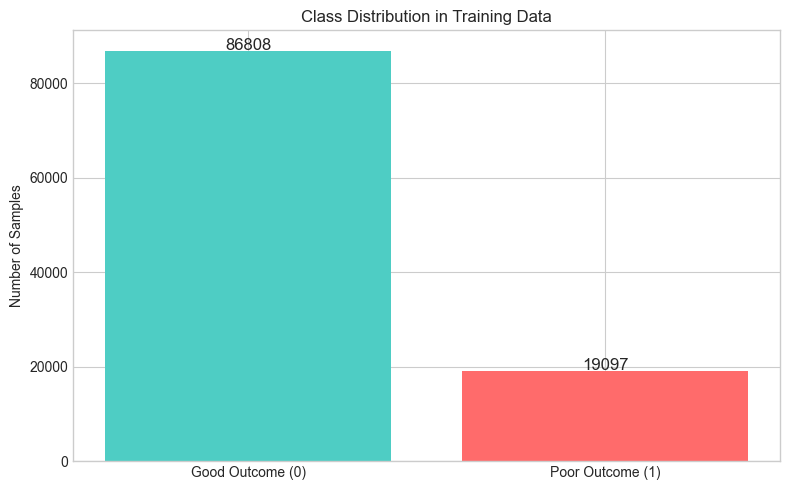

In [5]:
# Count class distribution
unique, counts = np.unique(y_train, return_counts=True)
class_distribution = dict(zip(unique, counts))

print("Class Distribution in Training Set:")
print("=" * 40)
for cls, count in class_distribution.items():
    percentage = count / len(y_train) * 100
    label = "Poor Outcome" if cls == 1 else "Good Outcome"
    print(f"Class {cls} ({label}): {count} samples ({percentage:.1f}%)")

# Calculate imbalance ratio
majority_class = max(counts)
minority_class = min(counts)
imbalance_ratio = majority_class / minority_class
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Good Outcome (0)', 'Poor Outcome (1)'], counts, color=['#4ecdc4', '#ff6b6b'])
ax.set_ylabel('Number of Samples')
ax.set_title('Class Distribution in Training Data')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
            f'{count}', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

## Step 4: Define the Models

**What's happening here:**
We create a dictionary of models, each with a different approach:

1. **EBM (Explainable Boosting Machine)**
   - A glass-box model that's both accurate AND interpretable
   - Uses gradient boosting on individual features

2. **Logistic Regression (No Weights)**
   - Basic baseline model
   - Treats all classes equally

3. **Logistic Regression (Balanced)**
   - Uses `class_weight='balanced'` to give more importance to minority class
   - Weight = n_samples / (n_classes * n_samples_for_class)

4. **Logistic Regression + SMOTE**
   - SMOTE = Synthetic Minority Over-sampling Technique
   - Creates synthetic samples of the minority class

5. **LASSO (L1 Regularization)**
   - Adds a penalty term that can shrink coefficients to exactly zero
   - Useful for feature selection (identifies important features)

6. **Random Forest**
   - Random Classifier; using 5 fold

In [6]:
# Define models in a dictionary for easy iteration
# Each model is wrapped in a pipeline with StandardScaler for consistent preprocessing

from sklearn.ensemble import RandomForestClassifier

models = {
    # Model 1: Explainable Boosting Machine
    # - interactions=0 means no pairwise interactions (simpler model)
    # - random_state ensures reproducibility
    'EBM': Pipeline([
        ('scaler', StandardScaler()),  # Normalize features
        ('model', ExplainableBoostingClassifier(
            random_state=42,
            interactions=0,  # Can set to a number to include interactions
            n_jobs=-1        # Use all CPU cores
        ))
    ]),
    
    # Model 2: Logistic Regression - No class weights
    # - max_iter=1000 allows more iterations to converge
    'LogReg_NoWeights': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight=None  # No class weights - treats all classes equally
        ))
    ]),
    
    # Model 3: Logistic Regression - Balanced class weights
    # - Automatically adjusts weights inversely proportional to class frequencies
    'LogReg_Balanced': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight='balanced'  # Automatically balance classes
        ))
    ]),
    
    # Model 4: Logistic Regression + SMOTE
    # - Uses ImbPipeline from imblearn (special pipeline for resampling)
    # - SMOTE is only applied during training, not during prediction
    'LogReg_SMOTE': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),  # Oversample minority class
        ('model', LogisticRegression(
            random_state=42,
            max_iter=1000
        ))
    ]),
    
    # Model 5: LASSO (L1 Regularized Logistic Regression)
    # - penalty='l1' adds L1 regularization
    # - solver='saga' is required for L1 penalty
    # - C=1.0 controls regularization strength (smaller = stronger regularization)
    'LASSO_LogReg': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            random_state=42,
            max_iter=1000,
            penalty='l1',          # L1 regularization (LASSO)
            solver='saga',         # Required for L1
            C=1.0,                 # Regularization strength
            class_weight='balanced'
        ))
    ]),
    
    # Model 6: Random Forest Classifier
    'Random_Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ])
}

print("Models defined:")
for name in models.keys():
    print(f"  - {name}")

Models defined:
  - EBM
  - LogReg_NoWeights
  - LogReg_Balanced
  - LogReg_SMOTE
  - LASSO_LogReg
  - Random_Forest


## Step 5: Cross-Validation with Train/Validation Score Comparison

**What's happening here:**
- **Cross-validation** splits the training data into K folds
- The model trains on K-1 folds and validates on the remaining fold
- This is repeated K times, giving us K scores

**Why we compare train vs validation scores:**
- If **train score >> validation score**: Model is **overfitting** (memorizing training data)
- If **train score ≈ validation score**: Model generalizes well
- If both scores are low: Model is **underfitting** (too simple)

**Metrics we'll track:**
- **Precision**: Of all predicted positives, how many are actually positive?
- **Recall**: Of all actual positives, how many did we find?
- **F1**: Harmonic mean of precision and recall
- **ROC-AUC**: Area under the ROC curve

In [7]:
# Define cross-validation strategy
# StratifiedKFold ensures each fold has the same class distribution as the full dataset
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Store results
cv_results = {}

print("Running cross-validation for each model...")
print("=" * 60)

for name, model in models.items():
    print(f"\nTraining: {name}")
    
    # cross_validate returns both train and test scores when return_train_score=True
    scores = cross_validate(
        model, 
        X_train, 
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,  # Important: gives us train scores for overfitting detection
        n_jobs=1                 # Use all CPU cores
    )
    
    cv_results[name] = scores
    
    # Print summary
    print(f"  Validation Recall: {scores['test_recall'].mean():.3f} (+/- {scores['test_recall'].std():.3f})")
    print(f"  Validation Precision: {scores['test_precision'].mean():.3f} (+/- {scores['test_precision'].std():.3f})")

print("\n" + "=" * 60)
print("Cross-validation complete!")

Running cross-validation for each model...

Training: EBM
  Validation Recall: 0.096 (+/- 0.003)
  Validation Precision: 0.665 (+/- 0.018)

Training: LogReg_NoWeights
  Validation Recall: 0.081 (+/- 0.003)
  Validation Precision: 0.661 (+/- 0.016)

Training: LogReg_Balanced
  Validation Recall: 0.603 (+/- 0.007)
  Validation Precision: 0.288 (+/- 0.003)

Training: LogReg_SMOTE
  Validation Recall: 0.603 (+/- 0.005)
  Validation Precision: 0.285 (+/- 0.003)

Training: LASSO_LogReg
  Validation Recall: 0.603 (+/- 0.007)
  Validation Precision: 0.288 (+/- 0.003)

Training: Random_Forest
  Validation Recall: 0.483 (+/- 0.006)
  Validation Precision: 0.323 (+/- 0.002)

Cross-validation complete!


## Step 6: Visualize Cross-Validation Results

**What's happening here:**
- We create a summary table comparing all models
- We visualize the results with bar charts
- We highlight any potential overfitting (large train-validation gap)

In [8]:
# Create summary DataFrame
summary_data = []

for name, scores in cv_results.items():
    for metric in ['precision', 'recall', 'f1', 'roc_auc']:
        train_mean = scores[f'train_{metric}'].mean()
        train_std = scores[f'train_{metric}'].std()
        val_mean = scores[f'test_{metric}'].mean()
        val_std = scores[f'test_{metric}'].std()
        gap = train_mean - val_mean  # Overfitting indicator
        
        summary_data.append({
            'Model': name,
            'Metric': metric.upper(),
            'Train Mean': train_mean,
            'Train Std': train_std,
            'Val Mean': val_mean,
            'Val Std': val_std,
            'Gap (Train-Val)': gap
        })

summary_df = pd.DataFrame(summary_data)

# Display as pivot table for easy reading
print("\nModel Comparison Summary (Validation Scores):")
print("=" * 80)
pivot = summary_df.pivot_table(
    index='Model', 
    columns='Metric', 
    values='Val Mean'
).round(3)
print(pivot)


Model Comparison Summary (Validation Scores):
Metric               F1  PRECISION  RECALL  ROC_AUC
Model                                              
EBM               0.167      0.665   0.096    0.695
LASSO_LogReg      0.390      0.288   0.603    0.690
LogReg_Balanced   0.390      0.288   0.603    0.690
LogReg_NoWeights  0.144      0.661   0.081    0.690
LogReg_SMOTE      0.387      0.285   0.603    0.686
Random_Forest     0.387      0.323   0.483    0.686


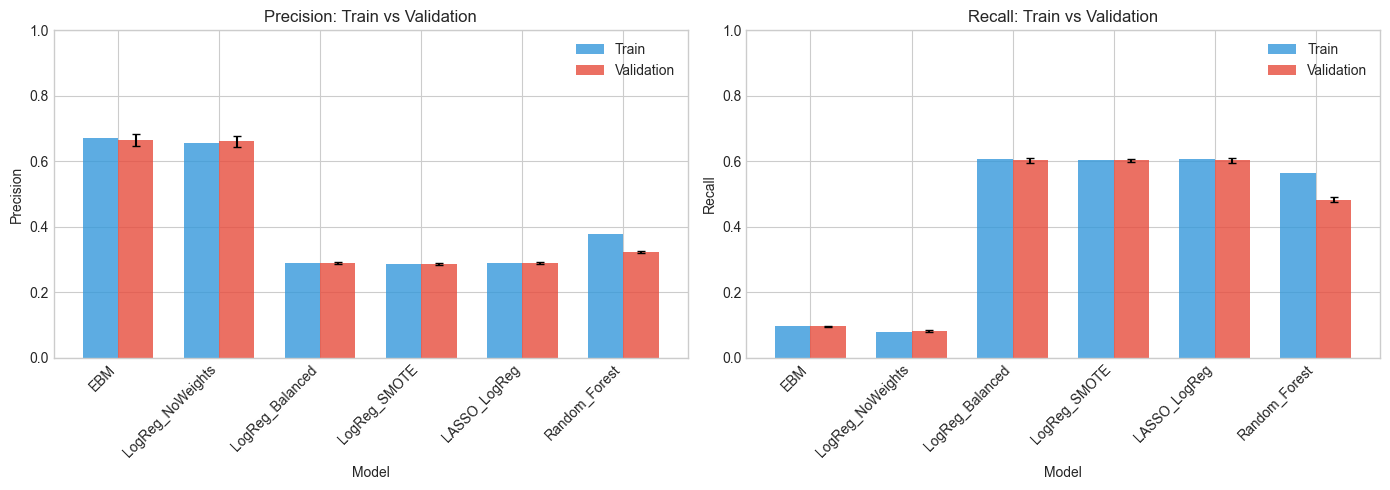

In [9]:
# Visualize: Precision and Recall comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get model names and metrics
model_names = list(cv_results.keys())

# Plot Precision
ax = axes[0]
train_precision = [cv_results[m]['train_precision'].mean() for m in model_names]
val_precision = [cv_results[m]['test_precision'].mean() for m in model_names]
val_precision_std = [cv_results[m]['test_precision'].std() for m in model_names]

x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, train_precision, width, label='Train', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, val_precision, width, label='Validation', color='#e74c3c', alpha=0.8,
               yerr=val_precision_std, capsize=3)

ax.set_xlabel('Model')
ax.set_ylabel('Precision')
ax.set_title('Precision: Train vs Validation')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)

# Plot Recall
ax = axes[1]
train_recall = [cv_results[m]['train_recall'].mean() for m in model_names]
val_recall = [cv_results[m]['test_recall'].mean() for m in model_names]
val_recall_std = [cv_results[m]['test_recall'].std() for m in model_names]

bars1 = ax.bar(x - width/2, train_recall, width, label='Train', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, val_recall, width, label='Validation', color='#e74c3c', alpha=0.8,
               yerr=val_recall_std, capsize=3)

ax.set_xlabel('Model')
ax.set_ylabel('Recall')
ax.set_title('Recall: Train vs Validation')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [10]:
# Overfitting Analysis: Show the gap between train and validation scores
print("\nOverfitting Analysis (Train - Validation Gap):")
print("=" * 60)
print("A large positive gap indicates potential overfitting.")
print("Gaps > 0.05 are highlighted in light red.")
print("Gaps > 0.02 are highlighted in light yellow.\n")

gap_df = summary_df.pivot_table(
    index='Model',
    columns='Metric',
    values='Gap (Train-Val)'
).round(3)

# Style the dataframe to highlight concerning gaps
def highlight_overfitting(val):
    if val > 0.05:
        return 'background-color: #ffcccc'  # Light red
    elif val > 0.02:
        return 'background-color: #ffffcc'  # Light yellow
    return ''

styled_gap = gap_df.style.map(highlight_overfitting)

display(styled_gap)


Overfitting Analysis (Train - Validation Gap):
A large positive gap indicates potential overfitting.
Gaps > 0.05 are highlighted in light red.
Gaps > 0.02 are highlighted in light yellow.



Metric,F1,PRECISION,RECALL,ROC_AUC
Model,,,,
EBM,0.000000,0.008000,0.000000,0.003000
LASSO_LogReg,0.002000,0.001000,0.003000,0.002000
LogReg_Balanced,0.002000,0.001000,0.003000,0.002000
LogReg_NoWeights,-0.001000,-0.006000,-0.001000,0.001000
LogReg_SMOTE,0.001000,0.001000,0.002000,0.002000
Random_Forest,0.066000,0.056000,0.081000,0.061000


### Step 6b: Overfitting Deep Dive — Random Forest

The gap analysis above suggests the Random Forest may be overfitting (train scores much higher than validation scores). Below we investigate this further by:

1. **Learning curves** — Plotting train vs validation scores as training size increases. If the model overfits, the train score will stay high while the validation score remains much lower. If the gap closes with more data, the model may just need more samples.
2. **Per-fold breakdown** — Showing train and validation scores for each of the 5 CV folds. Consistent gaps across folds confirm systematic overfitting (not just one unlucky split).
3. **Comparison with Logistic Regression** — Plotting the same learning curve for a simpler model to see if the gap is unique to Random Forest.

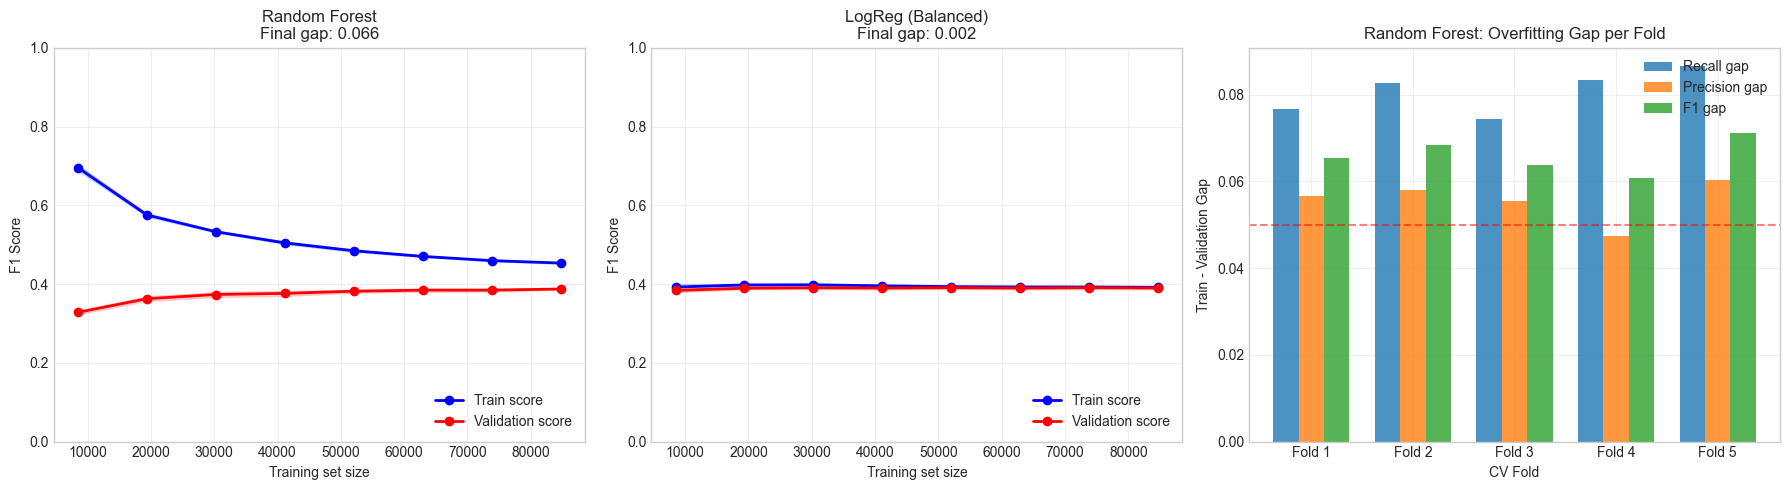


Overfitting Summary: Random Forest

  PRECISION:
    Train mean:      0.379
    Validation mean: 0.323
    Gap:             0.056 <-- OVERFITTING LIKELY

  RECALL:
    Train mean:      0.564
    Validation mean: 0.483
    Gap:             0.081 <-- OVERFITTING LIKELY

  F1:
    Train mean:      0.453
    Validation mean: 0.387
    Gap:             0.066 <-- OVERFITTING LIKELY

  ROC_AUC:
    Train mean:      0.747
    Validation mean: 0.686
    Gap:             0.061 <-- OVERFITTING LIKELY


Interpretation:
----------------------------------------
- If the learning curve gap NARROWS with more data → more data could help
- If the learning curve gap STAYS WIDE → model is too complex for the data
- If the gap is consistent across all folds → systematic overfitting
- Compare with LogReg: if its gap is small, RF's complexity is the issue


In [11]:
# Step 6b: Overfitting Deep Dive — Random Forest
# =================================================

from sklearn.model_selection import learning_curve

# --- 1. Learning Curves: Random Forest vs Logistic Regression ---
# Learning curves show how train/validation scores change with more training data.
# A large persistent gap = overfitting. A gap that closes = model benefits from more data.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_to_check = {
    'Random Forest': models['Random_Forest'],
    'LogReg (Balanced)': models['LogReg_Balanced'],
}

train_sizes = np.linspace(0.1, 1.0, 8)  # 10% to 100% of training data

for idx, (name, model) in enumerate(models_to_check.items()):
    ax = axes[idx]
    
    train_sizes_abs, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        train_sizes=train_sizes,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1',
        n_jobs=-1,
        random_state=42
    )
    
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)
    
    ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
    ax.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.15, color='red')
    ax.plot(train_sizes_abs, train_mean, 'o-', color='blue', linewidth=2, label='Train score')
    ax.plot(train_sizes_abs, val_mean, 'o-', color='red', linewidth=2, label='Validation score')
    
    # Show the gap
    final_gap = train_mean[-1] - val_mean[-1]
    ax.set_title(f'{name}\nFinal gap: {final_gap:.3f}')
    ax.set_xlabel('Training set size')
    ax.set_ylabel('F1 Score')
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

# --- 2. Per-Fold Breakdown for Random Forest ---
ax = axes[2]

rf_train_scores = cv_results['Random_Forest']
metrics_to_show = ['recall', 'precision', 'f1']
fold_indices = np.arange(1, 6)
width = 0.25

for i, metric in enumerate(metrics_to_show):
    train_vals = rf_train_scores[f'train_{metric}']
    val_vals = rf_train_scores[f'test_{metric}']
    gap = train_vals - val_vals
    
    ax.bar(fold_indices + (i - 1) * width, gap, width, 
           label=f'{metric.capitalize()} gap', alpha=0.8)

ax.set_xlabel('CV Fold')
ax.set_ylabel('Train - Validation Gap')
ax.set_title('Random Forest: Overfitting Gap per Fold')
ax.set_xticks(fold_indices)
ax.set_xticklabels([f'Fold {i}' for i in fold_indices])
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axhline(y=0.05, color='red', linestyle='--', alpha=0.5, label='Concern threshold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 3. Print numerical summary ---
print("\nOverfitting Summary: Random Forest")
print("=" * 60)

for metric in ['precision', 'recall', 'f1', 'roc_auc']:
    train_mean = rf_train_scores[f'train_{metric}'].mean()
    val_mean = rf_train_scores[f'test_{metric}'].mean()
    gap = train_mean - val_mean
    
    flag = ""
    if gap > 0.05:
        flag = " <-- OVERFITTING LIKELY"
    elif gap > 0.02:
        flag = " <-- MILD OVERFITTING"
    
    print(f"\n  {metric.upper()}:")
    print(f"    Train mean:      {train_mean:.3f}")
    print(f"    Validation mean: {val_mean:.3f}")
    print(f"    Gap:             {gap:.3f}{flag}")

print("\n" + "=" * 60)
print("\nInterpretation:")
print("-" * 40)
print("- If the learning curve gap NARROWS with more data → more data could help")
print("- If the learning curve gap STAYS WIDE → model is too complex for the data")
print("- If the gap is consistent across all folds → systematic overfitting")
print("- Compare with LogReg: if its gap is small, RF's complexity is the issue")

### Step 6c: Reduce Random Forest Overfitting

Since the Random Forest is overfitting, we tune its hyperparameters with a focus on **reducing model complexity**. Instead of optimising only for validation recall (as in Step 15), we now look for the configuration that:

1. Keeps the train–validation gap **below 0.05** (no severe overfitting)
2. Among those, selects the one with the **highest validation F1 score**

The levers we pull:
- **Lower `max_depth`** → shallower trees, less memorisation
- **Higher `min_samples_leaf`** → each leaf must cover more patients
- **Higher `min_samples_split`** → requires more evidence before splitting
- **`max_samples`** → each tree only sees a fraction of the training data
- **Lower `max_features`** → each tree sees fewer features, more diversity

In [12]:
# Step 6c: Tune Random Forest to Reduce Overfitting
# ====================================================
# If the saved model was loaded in Step 1b, we skip the tuning entirely.

import os
RF_ANTIOVERFIT_PATH = 'c:/Users/olifa/OneDrive/Documenten/GitHub/EAISI-Group-Project---NHS/code/EAISI-Group-Project---NHS/code/rf_antioverfit_model.joblib'

if os.path.exists(RF_ANTIOVERFIT_PATH):
    print("✓ Anti-overfitting RF model already loaded from Step 1b.")
    print("  Skipping grid search — models['Random_Forest'] is ready.")
else:
    from sklearn.ensemble import RandomForestClassifier
    from itertools import product

    # Define parameter grid focused on REDUCING complexity
    param_grid_anti_overfit = {
        'max_depth': [3, 5, 7, 10],
        'min_samples_leaf': [10, 20, 50, 100],
        'min_samples_split': [20, 50, 100],
        'max_features': [0.1, 0.2, 0.3],
        'max_samples': [0.5, 0.7, 0.9],
    }

    keys = list(param_grid_anti_overfit.keys())
    combinations = list(product(*param_grid_anti_overfit.values()))
    total = len(combinations)

    print(f"Testing {total} hyperparameter combinations for overfitting reduction...")
    print("=" * 60)

    cv_anti = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    tuning_results = []

    for i, values in enumerate(combinations):
        params = dict(zip(keys, values))

        rf = Pipeline([
            ('scaler', StandardScaler()),
            ('model', RandomForestClassifier(
                n_estimators=200,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1,
                **params
            ))
        ])

        scores = cross_validate(
            rf, X_train, y_train,
            cv=cv_anti,
            scoring={'f1': 'f1', 'recall': 'recall', 'precision': 'precision'},
            return_train_score=True,
            n_jobs=1
        )

        train_f1 = scores['train_f1'].mean()
        val_f1   = scores['test_f1'].mean()
        train_recall = scores['train_recall'].mean()
        val_recall   = scores['test_recall'].mean()
        train_precision = scores['train_precision'].mean()
        val_precision   = scores['test_precision'].mean()

        tuning_results.append({
            **params,
            'train_f1': train_f1, 'val_f1': val_f1, 'gap_f1': train_f1 - val_f1,
            'train_recall': train_recall, 'val_recall': val_recall, 'gap_recall': train_recall - val_recall,
            'train_precision': train_precision, 'val_precision': val_precision, 'gap_precision': train_precision - val_precision,
        })

        if (i + 1) % 50 == 0 or (i + 1) == total:
            print(f"  Progress: {i+1}/{total} combinations tested")

    tuning_df = pd.DataFrame(tuning_results)

    max_gap  = 0.05
    acceptable = tuning_df[tuning_df['gap_f1'] <= max_gap].copy()
    print(f"\n{len(acceptable)} / {total} combinations have F1 gap <= {max_gap}")

    if len(acceptable) == 0:
        max_gap    = tuning_df['gap_f1'].min() + 0.02
        acceptable = tuning_df[tuning_df['gap_f1'] <= max_gap].copy()
        print(f"Relaxed threshold to {max_gap:.3f} → {len(acceptable)} combinations pass")

    best_row = acceptable.sort_values('val_f1', ascending=False).iloc[0]

    print(f"\nBest configuration (lowest overfitting + highest val F1):")
    print("-" * 60)
    for p in keys:
        print(f"  {p}: {best_row[p]}")
    print(f"\n  Train F1:      {best_row['train_f1']:.3f}  |  Val F1:      {best_row['val_f1']:.3f}  |  Gap: {best_row['gap_f1']:.3f}")
    print(f"  Train Recall:  {best_row['train_recall']:.3f}  |  Val Recall:  {best_row['val_recall']:.3f}  |  Gap: {best_row['gap_recall']:.3f}")
    print(f"  Train Prec:    {best_row['train_precision']:.3f}  |  Val Prec:    {best_row['val_precision']:.3f}  |  Gap: {best_row['gap_precision']:.3f}")

    best_params = {p: best_row[p] for p in keys}
    if best_params['max_depth'] is not None:
        best_params['max_depth'] = int(best_params['max_depth'])
    best_params['min_samples_leaf']  = int(best_params['min_samples_leaf'])
    best_params['min_samples_split'] = int(best_params['min_samples_split'])

    models['Random_Forest'] = Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(
            n_estimators=200,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
            **best_params
        ))
    ])

    print("\n" + "=" * 60)
    print("Updated 'Random_Forest' in the models dictionary.")
    print("Run Step 6c-iii to save this model so you never run this again.")

✓ Anti-overfitting RF model already loaded from Step 1b.
  Skipping grid search — models['Random_Forest'] is ready.


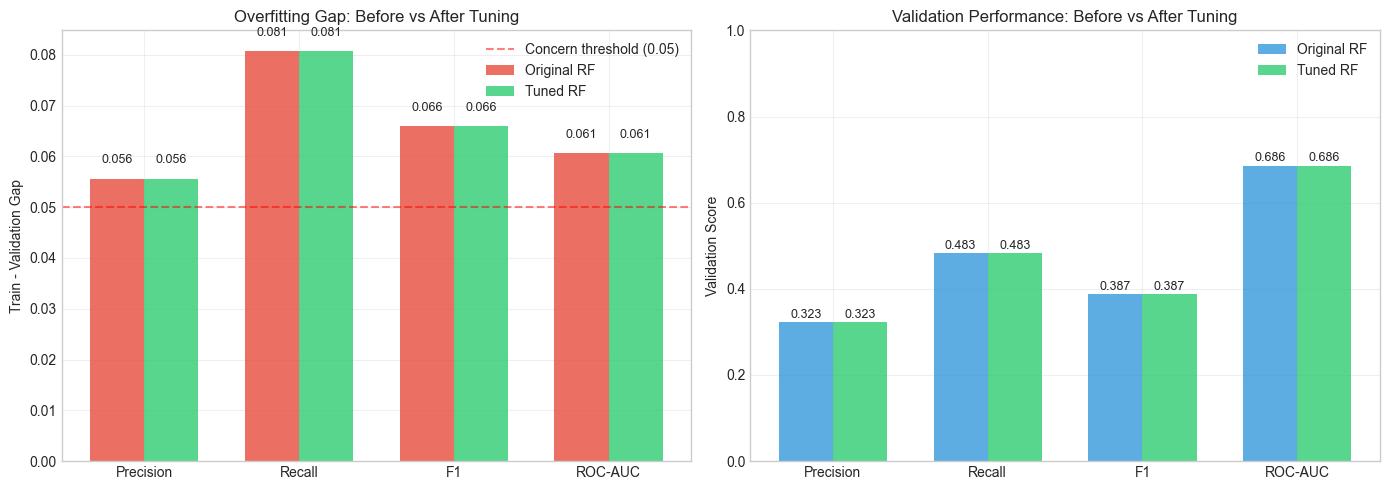


Summary:
  Precision: gap reduced from 0.056 → 0.056 (0% reduction)
  Recall: gap reduced from 0.081 → 0.081 (0% reduction)
  F1: gap reduced from 0.066 → 0.066 (0% reduction)
  ROC-AUC: gap reduced from 0.061 → 0.061 (0% reduction)

The updated Random Forest model will be used in all subsequent steps.


In [13]:
# Step 6c-ii: Verify Overfitting Reduction
# ==========================================

# Run cross-validation on the updated Random Forest to confirm the gap has shrunk
scores_new = cross_validate(
    models['Random_Forest'], X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={'f1': 'f1', 'recall': 'recall', 'precision': 'precision', 'roc_auc': 'roc_auc'},
    return_train_score=True,
    n_jobs=1
)

# Compare old RF (from Step 5) vs new RF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['precision', 'recall', 'f1', 'roc_auc']
labels = ['Precision', 'Recall', 'F1', 'ROC-AUC']

# Old gaps (from cv_results computed in Step 5)
old_gaps = [cv_results['Random_Forest'][f'train_{m}'].mean() - cv_results['Random_Forest'][f'test_{m}'].mean() for m in metrics]
new_gaps = [scores_new[f'train_{m}'].mean() - scores_new[f'test_{m}'].mean() for m in metrics]

# Left: Overfitting gap comparison
ax = axes[0]
x = np.arange(len(metrics))
width = 0.35
bars1 = ax.bar(x - width/2, old_gaps, width, label='Original RF', color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + width/2, new_gaps, width, label='Tuned RF', color='#2ecc71', alpha=0.8)
ax.axhline(y=0.05, color='red', linestyle='--', alpha=0.5, label='Concern threshold (0.05)')
ax.set_ylabel('Train - Validation Gap')
ax.set_title('Overfitting Gap: Before vs After Tuning')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(True, alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, f'{bar.get_height():.3f}',
            ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, f'{bar.get_height():.3f}',
            ha='center', fontsize=9)

# Right: Validation scores comparison
ax = axes[1]
old_val = [cv_results['Random_Forest'][f'test_{m}'].mean() for m in metrics]
new_val = [scores_new[f'test_{m}'].mean() for m in metrics]

bars1 = ax.bar(x - width/2, old_val, width, label='Original RF', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, new_val, width, label='Tuned RF', color='#2ecc71', alpha=0.8)
ax.set_ylabel('Validation Score')
ax.set_title('Validation Performance: Before vs After Tuning')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.3f}',
            ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.3f}',
            ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Update cv_results so later steps use the new RF scores
cv_results['Random_Forest'] = scores_new

print("\nSummary:")
print("=" * 60)
for m, label in zip(metrics, labels):
    old_g = cv_results_old_gap = old_gaps[metrics.index(m)]
    new_g = new_gaps[metrics.index(m)]
    reduction = ((old_g - new_g) / old_g * 100) if old_g > 0 else 0
    print(f"  {label}: gap reduced from {old_g:.3f} → {new_g:.3f} ({reduction:.0f}% reduction)")

print("\nThe updated Random Forest model will be used in all subsequent steps.")

In [14]:
# Step 6c-iii: Save the anti-overfitting RF model to disk
# =========================================================
# Run this cell ONCE after Step 6c has finished.
# Saves the updated models['Random_Forest'] so you never have to
# re-run the 432-combination grid search again.

import joblib, os

RF_ANTIOVERFIT_PATH = 'c:/Users/olifa/OneDrive/Documenten/GitHub/EAISI-Group-Project---NHS/code/EAISI-Group-Project---NHS/code/rf_antioverfit_model.joblib'

joblib.dump(models['Random_Forest'], RF_ANTIOVERFIT_PATH)
print(f"Anti-overfitting RF model saved to: {RF_ANTIOVERFIT_PATH}")
print(f"File size: {os.path.getsize(RF_ANTIOVERFIT_PATH) / 1024 / 1024:.1f} MB")

Anti-overfitting RF model saved to: c:/Users/olifa/OneDrive/Documenten/GitHub/EAISI-Group-Project---NHS/code/EAISI-Group-Project---NHS/code/rf_antioverfit_model.joblib
File size: 0.0 MB


## Step 7: Train Final Models and Get Feature Importances

**What's happening here:**
- We train each model on the full training set
- We extract feature importances (how much each feature contributes to predictions)

**Why feature importances matter:**
- Helps understand what the model is learning
- Validates that the model uses sensible features
- Can inform future feature engineering

In [15]:
# Train all models on full training data
trained_models = {}

print("Training models on full training data...")
for name, model in models.items():
    print(f"  Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model

print("\nAll models trained!")

Training models on full training data...
  Training EBM...
  Training LogReg_NoWeights...
  Training LogReg_Balanced...
  Training LogReg_SMOTE...
  Training LASSO_LogReg...
  Training Random_Forest...

All models trained!


In [16]:
# Extract feature importances
feature_names = X_train.columns.tolist()

def get_feature_importance(model, model_name, feature_names):
    if 'EBM' in model_name:
        ebm_model = model.named_steps['model']
        importances = ebm_model.term_importances()
        names = ebm_model.term_names_
        return pd.DataFrame({'Feature': names, 'Importance': importances})
    
    elif 'RandomForest' in model_name:
        rf_model = model.named_steps['model']
        importances = rf_model.feature_importances_
        return pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    
    else:
        lr_model = model.named_steps['model']
        importances = np.abs(lr_model.coef_[0])
        return pd.DataFrame({'Feature': feature_names, 'Importance': importances})


# LASSO-specific: Show which features have non-zero coefficients
# Only run this for LASSO model

if 'LASSO_LogReg' in trained_models:
    lasso_model = trained_models['LASSO_LogReg'].named_steps['model']
    
    if hasattr(lasso_model, 'coef_'):
        lasso_coef = lasso_model.coef_[0]
        
        n_nonzero = np.sum(lasso_coef != 0)
        n_zero = np.sum(lasso_coef == 0)
        
        print("LASSO Feature Selection Analysis:")
        print("=" * 50)
        print(f"Total features: {len(lasso_coef)}")
        print(f"Features with non-zero coefficients: {n_nonzero}")
        print(f"Features eliminated (zero coefficients): {n_zero}")
        print(f"\nLASSO kept {n_nonzero/len(lasso_coef)*100:.1f}% of features")
    else:
        print("LASSO model doesn't have coefficients available")

# Get importances for each model
# Make sure feature_names matches current X_train columns
feature_names = X_train.columns.tolist()

all_importances = {}
for name, model in trained_models.items():
    try:
        all_importances[name] = get_feature_importance(model, name, feature_names)
        print(f"✓ {name}: extracted {len(all_importances[name])} feature importances")
    except Exception as e:
        print(f"✗ {name}: Error - {e}")

print(f"\nSuccessfully extracted importances for {len(all_importances)} models")





LASSO Feature Selection Analysis:
Total features: 57
Features with non-zero coefficients: 51
Features eliminated (zero coefficients): 6

LASSO kept 89.5% of features
✓ EBM: extracted 57 feature importances
✓ LogReg_NoWeights: extracted 57 feature importances
✓ LogReg_Balanced: extracted 57 feature importances
✓ LogReg_SMOTE: extracted 57 feature importances
✓ LASSO_LogReg: extracted 57 feature importances
✗ Random_Forest: Error - 'RandomForestClassifier' object has no attribute 'coef_'

Successfully extracted importances for 5 models


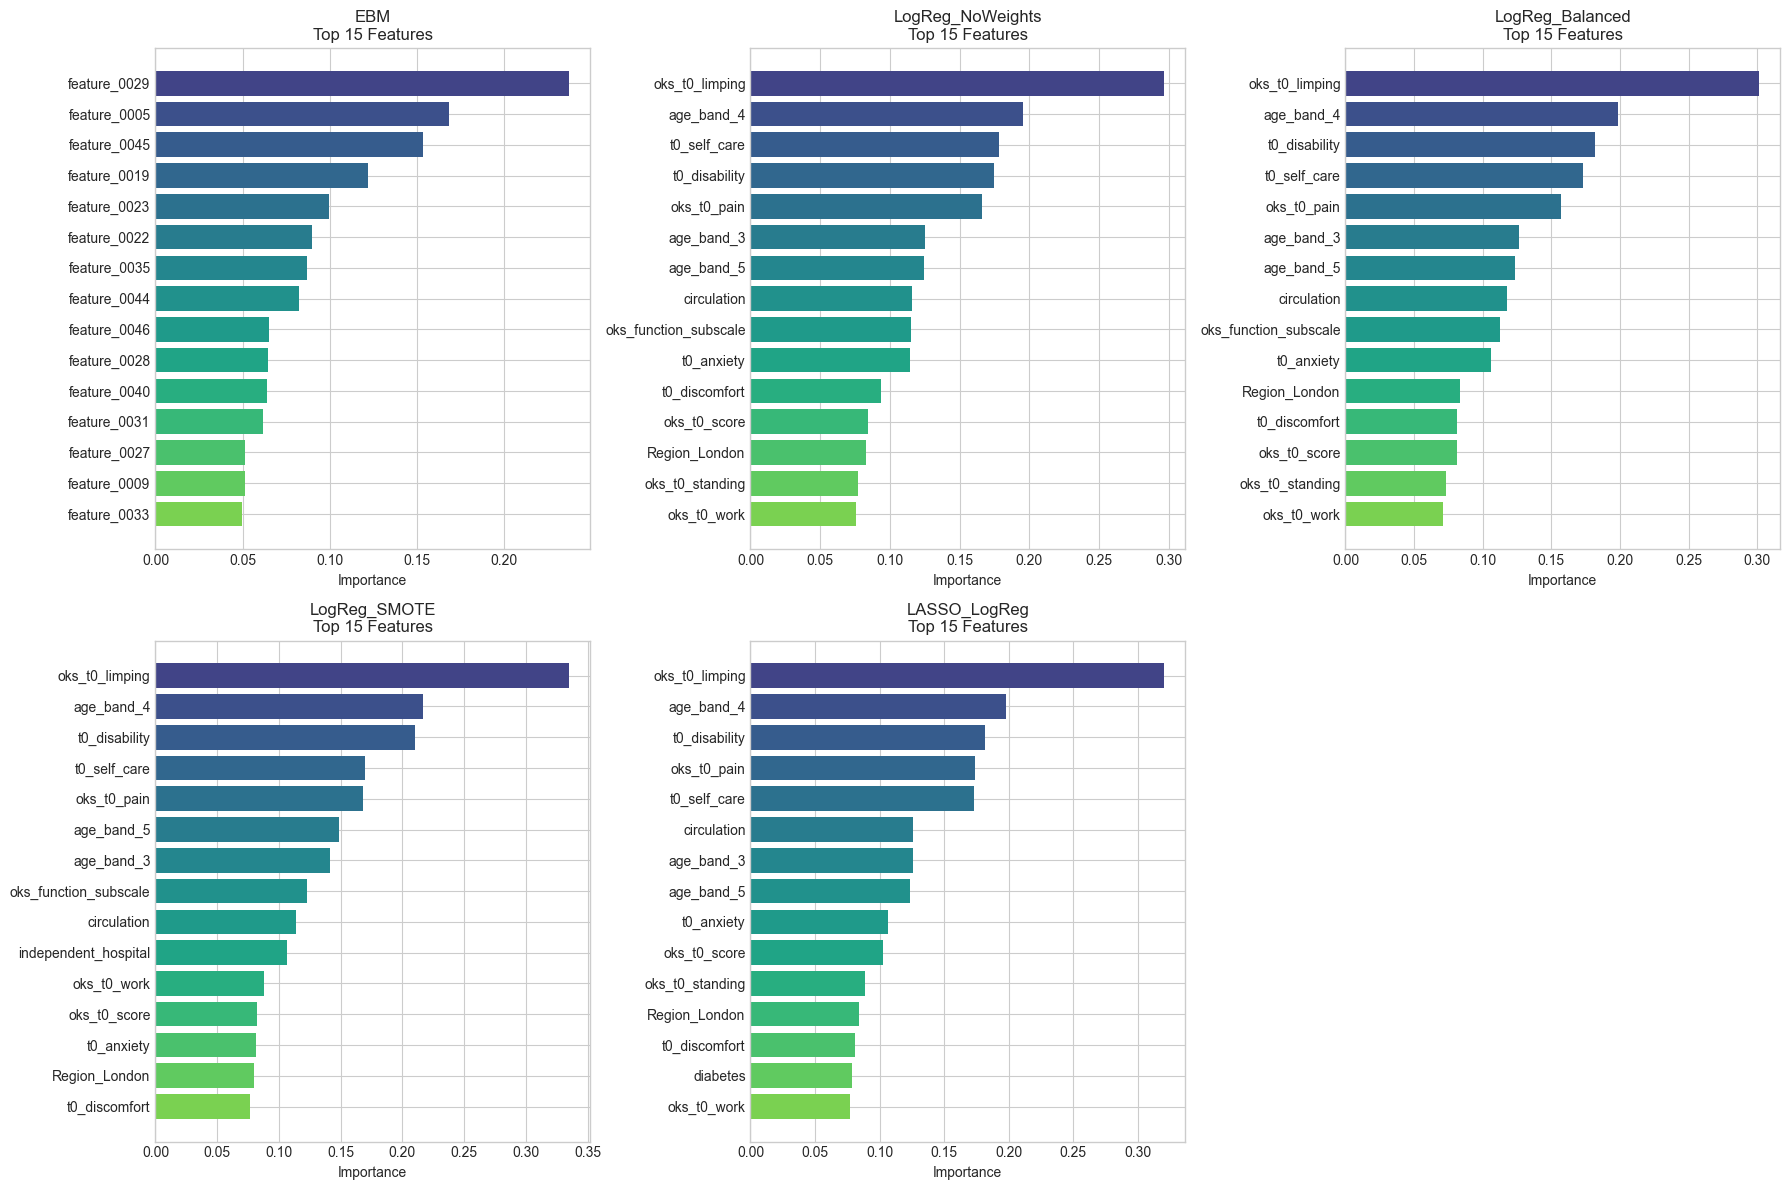

In [17]:
# Visualize top 15 features for each model
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, importance_df) in enumerate(all_importances.items()):
    if idx >= len(axes):
        break
        
    ax = axes[idx]
    
    # Get top 15 features
    top_features = importance_df.nlargest(15, 'Importance')
    
    # Create horizontal bar plot
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_features)))
    ax.barh(top_features['Feature'], top_features['Importance'], color=colors)
    ax.set_xlabel('Importance')
    ax.set_title(f'{name}\nTop 15 Features')
    ax.invert_yaxis()  # Highest importance at top

# Hide empty subplot if we have an odd number of models
if len(all_importances) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

In [18]:
# LASSO-specific: Show which features have non-zero coefficients
# (LASSO can shrink some coefficients to exactly zero)

lasso_model = trained_models['LASSO_LogReg'].named_steps['model']
lasso_coef = lasso_model.coef_[0]

n_nonzero = np.sum(lasso_coef != 0)
n_zero = np.sum(lasso_coef == 0)

print("LASSO Feature Selection Analysis:")
print("=" * 50)
print(f"Total features: {len(lasso_coef)}")
print(f"Features with non-zero coefficients: {n_nonzero}")
print(f"Features eliminated (zero coefficients): {n_zero}")
print(f"\nLASSO kept {n_nonzero/len(lasso_coef)*100:.1f}% of features")

LASSO Feature Selection Analysis:
Total features: 57
Features with non-zero coefficients: 51
Features eliminated (zero coefficients): 6

LASSO kept 89.5% of features


## Step 8: Precision-Recall Curves

**What's happening here:**
- We plot the precision-recall curve for each model
- This shows the trade-off between precision and recall at different thresholds

**Why Precision-Recall curves instead of ROC curves?**
- For imbalanced datasets, PR curves are more informative
- A model with high AUC-PR is good at finding positives without too many false alarms

**How to read the curve:**
- Top-right corner is ideal (high precision AND high recall)
- The baseline is the proportion of positive class (random classifier)

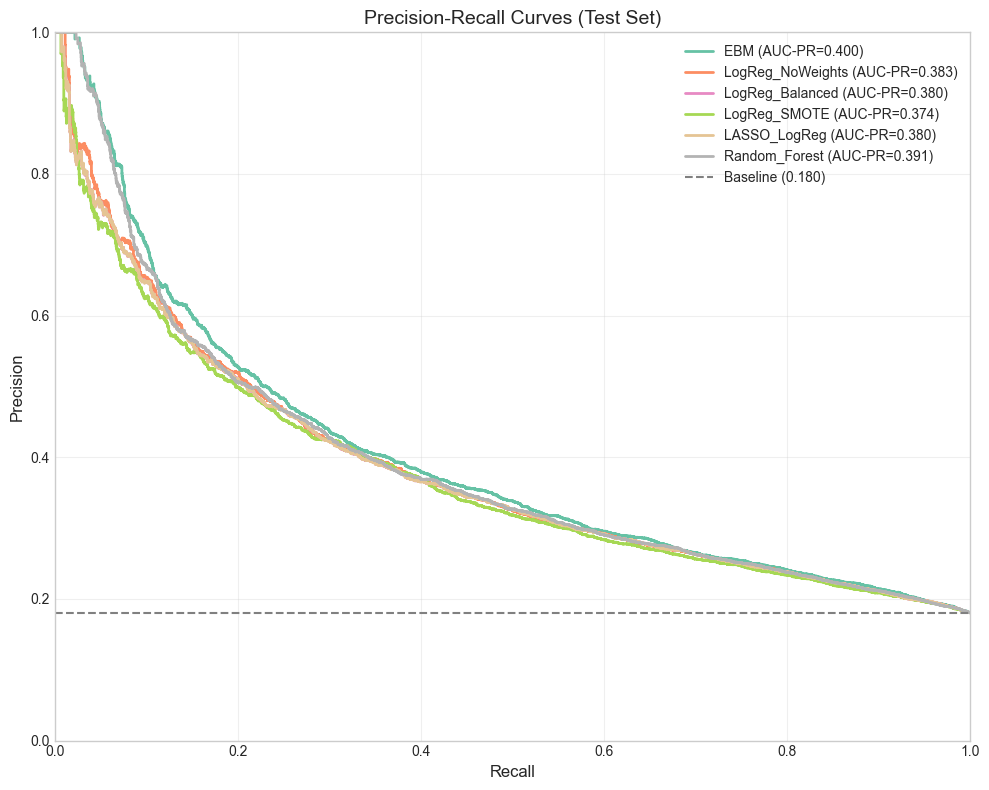

In [19]:
# Plot Precision-Recall curves on validation data using cross-validation
# We'll use the test set here for visualization since we trained on full training data

fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.Set2(np.linspace(0, 1, len(trained_models)))

for (name, model), color in zip(trained_models.items(), colors):
    # Get predicted probabilities
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # For models without predict_proba, use decision function
        y_proba = model.decision_function(X_test)
    
    # Calculate precision-recall curve
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    
    # Calculate AUC-PR
    from sklearn.metrics import average_precision_score
    auc_pr = average_precision_score(y_test, y_proba)
    
    # Plot
    ax.plot(recall, precision, color=color, linewidth=2, label=f'{name} (AUC-PR={auc_pr:.3f})')

# Add baseline (random classifier)
baseline = y_test.mean()
ax.axhline(y=baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves (Test Set)', fontsize=14)
ax.legend(loc='best', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

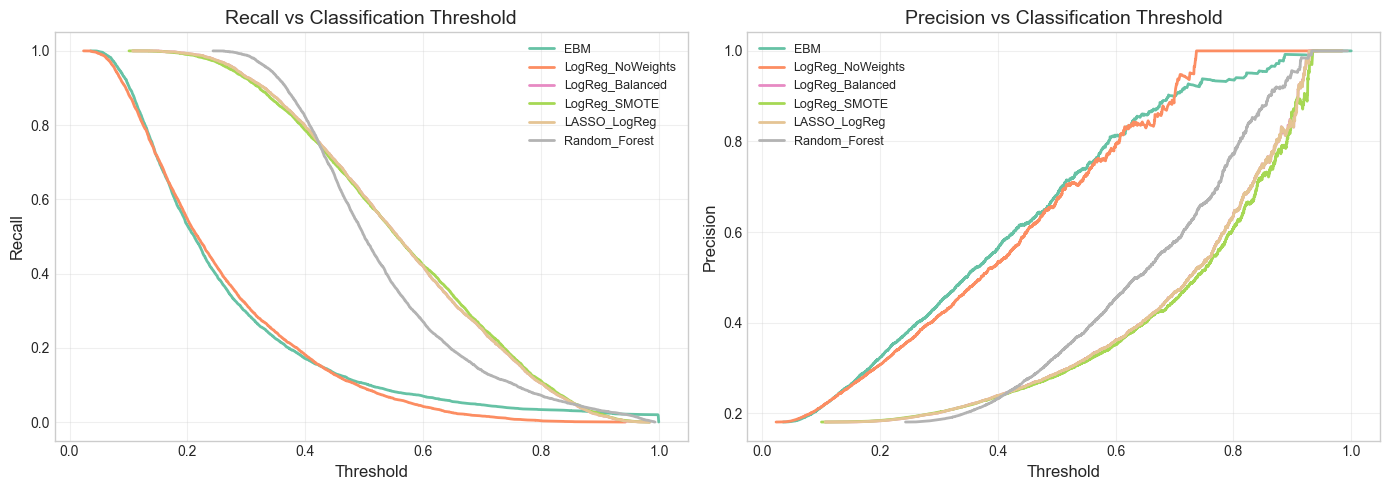

In [20]:
# Plot Recall at different thresholds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.Set2(np.linspace(0, 1, len(trained_models)))

for (name, model), color in zip(trained_models.items(), colors):
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    
    # Recall vs Threshold
    axes[0].plot(thresholds, recall[:-1], color=color, linewidth=2, label=name)
    
    # Precision vs Threshold
    axes[1].plot(thresholds, precision[:-1], color=color, linewidth=2, label=name)

axes[0].set_xlabel('Threshold', fontsize=12)
axes[0].set_ylabel('Recall', fontsize=12)
axes[0].set_title('Recall vs Classification Threshold', fontsize=14)
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Threshold', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision vs Classification Threshold', fontsize=14)
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 9: Final Test Set Evaluation

**What's happening here:**
- We evaluate all models on the held-out test set
- This gives us an unbiased estimate of how well each model will perform on new data

**Important:**
- The test set was NEVER used during training or cross-validation
- This is the final, honest evaluation of our models

In [21]:
# Evaluate all models on test set
test_results = []

print("Final Test Set Evaluation")
print("=" * 70)

for name, model in trained_models.items():
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Get probabilities for ROC-AUC
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    
    # Calculate metrics
    results = {
        'Model': name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    test_results.append(results)

# Create results DataFrame
test_results_df = pd.DataFrame(test_results).set_index('Model').round(3)
print(test_results_df)
print("\n" + "=" * 70)

Final Test Set Evaluation
                  Precision  Recall     F1  ROC-AUC
Model                                              
EBM                   0.681   0.104  0.181    0.702
LogReg_NoWeights      0.670   0.092  0.162    0.694
LogReg_Balanced       0.288   0.608  0.391    0.694
LogReg_SMOTE          0.283   0.603  0.385    0.689
LASSO_LogReg          0.288   0.609  0.391    0.694
Random_Forest         0.327   0.502  0.396    0.696



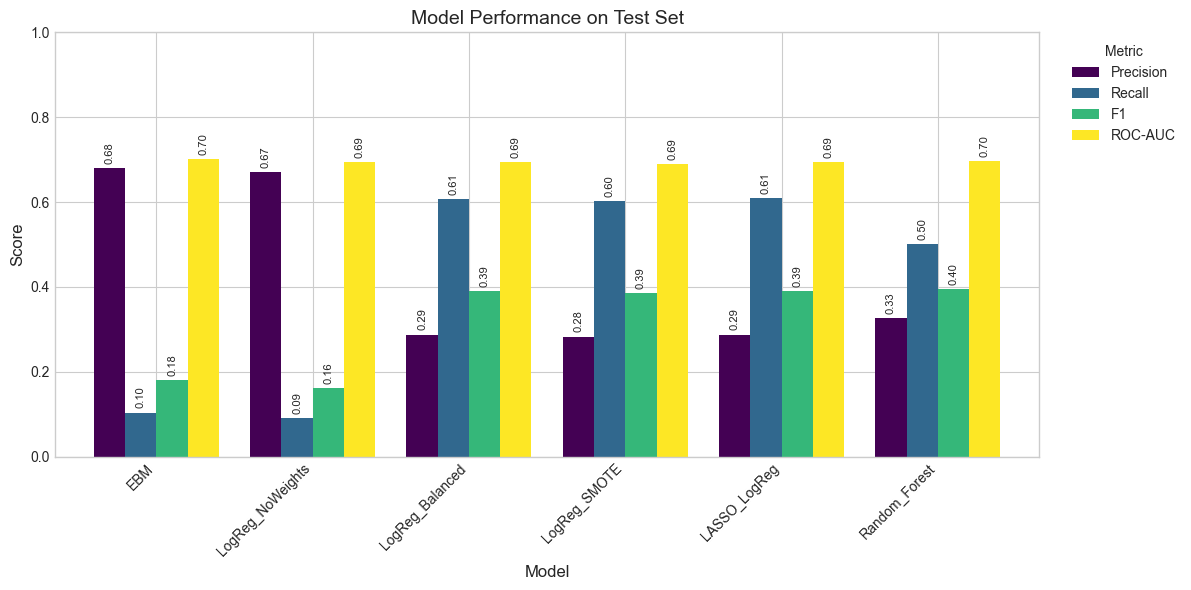

In [22]:
# Visualize test results
fig, ax = plt.subplots(figsize=(12, 6))

test_results_df.plot(kind='bar', ax=ax, width=0.8, colormap='viridis')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance on Test Set', fontsize=14)
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylim(0, 1)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8, rotation=90, padding=3)

plt.tight_layout()
plt.show()

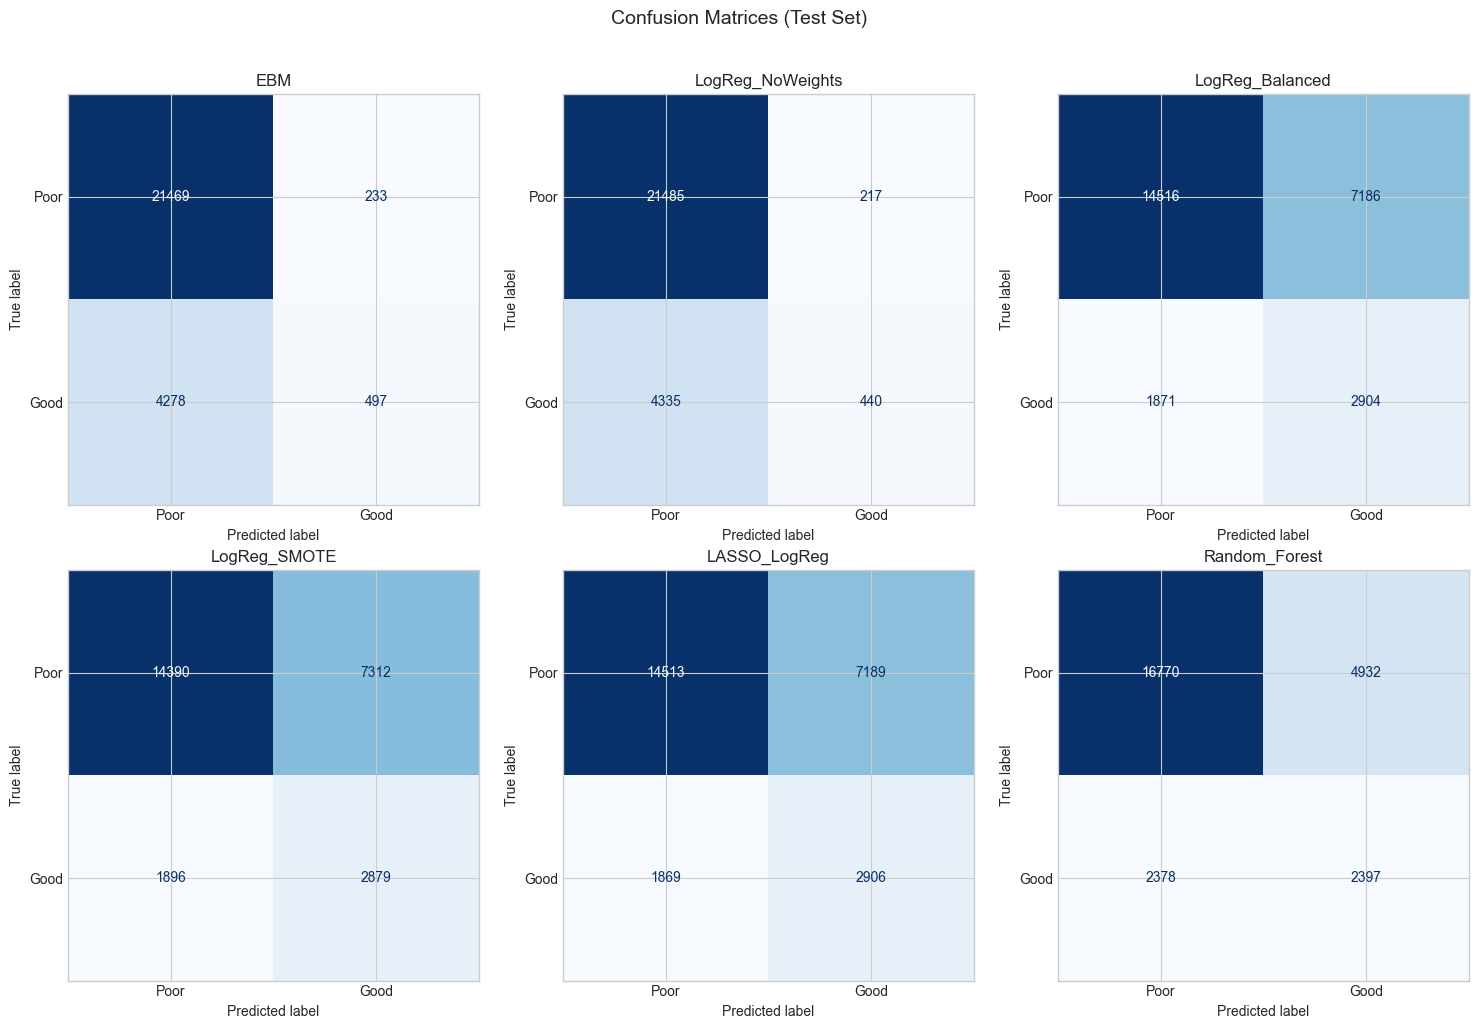

In [23]:
# Confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(trained_models.items()):
    if idx >= len(axes):
        break
    
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Poor', 'Good'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{name}')

# Hide empty subplot
if len(trained_models) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Confusion Matrices (Test Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Step 10: Summary and Conclusions

**What we learned:**
- How different approaches handle class imbalance
- Which models show signs of overfitting
- Which features are most important for predicting outcomes
- The trade-off between precision and recall

In [24]:
# Final summary
print("=" * 70)
print("SUMMARY")
print("=" * 70)

# Best model by each metric
for metric in ['Precision', 'Recall', 'F1', 'ROC-AUC']:
    best_model = test_results_df[metric].idxmax()
    best_score = test_results_df[metric].max()
    print(f"\nBest {metric}: {best_model} ({best_score:.3f})")

print("\n" + "=" * 70)
print("\nKey Observations:")
print("-" * 40)
print("1. Check the Train-Validation gap to identify overfitting")
print("2. SMOTE and balanced weights improve recall at cost of precision")
print("3. LASSO provides automatic feature selection")
print("4. EBM offers interpretable predictions with competitive performance")
print("\nChoose the model based on your priority:")
print("  - High Precision: Minimize false positives")
print("  - High Recall: Find all positive cases (important for medical screening)")
print("  - Balanced: Use F1 score")

SUMMARY

Best Precision: EBM (0.681)

Best Recall: LASSO_LogReg (0.609)

Best F1: Random_Forest (0.396)

Best ROC-AUC: EBM (0.702)


Key Observations:
----------------------------------------
1. Check the Train-Validation gap to identify overfitting
2. SMOTE and balanced weights improve recall at cost of precision
3. LASSO provides automatic feature selection
4. EBM offers interpretable predictions with competitive performance

Choose the model based on your priority:
  - High Precision: Minimize false positives
  - High Recall: Find all positive cases (important for medical screening)
  - Balanced: Use F1 score


## Bonus: EBM Interpretability

One of the key advantages of the Explainable Boosting Machine is its interpretability. Let's explore what the EBM learned.

In [25]:
# EBM Global Explanation
from interpret import show

ebm_model = trained_models['EBM'].named_steps['model']

# Get global explanation
ebm_global = ebm_model.explain_global(name='EBM Global Importance')

# Show interactive plot (works in Jupyter)
show(ebm_global)

<!-- http://127.0.0.1:7001/2602426647616/ -->

In [26]:
# EBM Local Explanation (for a single prediction)
# Let's explain the first test sample

sample_idx = 0
sample = X_test.iloc[[sample_idx]]

ebm_local = ebm_model.explain_local(sample, y_test[[sample_idx]], name='EBM Local Explanation')
show(ebm_local)

<!-- http://127.0.0.1:7001/2602495970512/ -->

---

## Next Steps

1. **Hyperparameter Tuning**: Use GridSearchCV or RandomizedSearchCV to find optimal parameters
2. **Threshold Optimization**: Adjust the classification threshold based on your precision-recall preference
3. **Feature Engineering**: Create new features based on domain knowledge
4. **Ensemble Methods**: Combine multiple models for better performance

## How to get 80% precision?

Cell 1: Find thresholds for 80% precision

In [27]:
# Step 11: Adjust Thresholds for 80% Precision
# ============================================
# By default, classifiers use 0.5 as the threshold.
# We'll find the threshold where precision >= 0.8 for each model.

from sklearn.metrics import precision_recall_curve

target_precision = 0.80
optimal_thresholds = {}

print("Finding thresholds for 80% precision...")
print("=" * 70)

for name, model in trained_models.items():
    # Get predicted probabilities
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    
    # Calculate precision at different thresholds
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    
    # Find threshold where precision >= target_precision
    # We want the LOWEST threshold that achieves target precision (maximizes recall)
    valid_indices = np.where(precisions >= target_precision)[0]
    
    if len(valid_indices) > 0:
        # Get the index with highest recall among valid precisions
        best_idx = valid_indices[0]  # First valid index has highest recall
        
        # Handle edge case where best_idx equals len(thresholds)
        if best_idx >= len(thresholds):
            best_idx = len(thresholds) - 1
            
        optimal_threshold = thresholds[best_idx]
        achieved_precision = precisions[best_idx]
        achieved_recall = recalls[best_idx]
        
        optimal_thresholds[name] = {
            'threshold': optimal_threshold,
            'precision': achieved_precision,
            'recall': achieved_recall
        }
        
        print(f"\n{name}:")
        print(f"  Optimal threshold: {optimal_threshold:.3f}")
        print(f"  Precision: {achieved_precision:.3f}")
        print(f"  Recall: {achieved_recall:.3f}")
    else:
        print(f"\n{name}:")
        print(f"  ⚠ Cannot achieve {target_precision:.0%} precision with this model")
        optimal_thresholds[name] = None

print("\n" + "=" * 70)


Finding thresholds for 80% precision...

EBM:
  Optimal threshold: 0.588
  Precision: 0.801
  Recall: 0.074

LogReg_NoWeights:
  Optimal threshold: 0.606
  Precision: 0.800
  Recall: 0.040

LogReg_Balanced:
  Optimal threshold: 0.873
  Precision: 0.800
  Recall: 0.035

LogReg_SMOTE:
  Optimal threshold: 0.891
  Precision: 0.800
  Recall: 0.027

LASSO_LogReg:
  Optimal threshold: 0.873
  Precision: 0.800
  Recall: 0.035

Random_Forest:
  Optimal threshold: 0.811
  Precision: 0.801
  Recall: 0.066



Cell 2: Evaluate with optimized thresholds

In [28]:
# Step 12: Evaluate Models with Optimized Thresholds
# ==================================================

print("Test Set Results with 80% Precision Threshold")
print("=" * 70)

optimized_results = []

for name, model in trained_models.items():
    if optimal_thresholds[name] is None:
        print(f"\n{name}: Skipped (cannot achieve target precision)")
        continue
    
    threshold = optimal_thresholds[name]['threshold']
    
    # Get probabilities
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    
    # Apply custom threshold
    y_pred_optimized = (y_proba >= threshold).astype(int)
    
    # Calculate metrics
    precision = precision_score(y_test, y_pred_optimized)
    recall = recall_score(y_test, y_pred_optimized)
    f1 = f1_score(y_test, y_pred_optimized)
    
    optimized_results.append({
        'Model': name,
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })

# Create results DataFrame
optimized_df = pd.DataFrame(optimized_results).set_index('Model').round(3)
print("\n")
print(optimized_df)
print("\n" + "=" * 70)


Test Set Results with 80% Precision Threshold


                  Threshold  Precision  Recall     F1
Model                                                
EBM                   0.588      0.801   0.074  0.135
LogReg_NoWeights      0.606      0.800   0.040  0.077
LogReg_Balanced       0.873      0.800   0.035  0.067
LogReg_SMOTE          0.891      0.800   0.027  0.052
LASSO_LogReg          0.873      0.800   0.035  0.067
Random_Forest         0.811      0.801   0.066  0.123



Cell 3: Compare default vs optimized thresholds

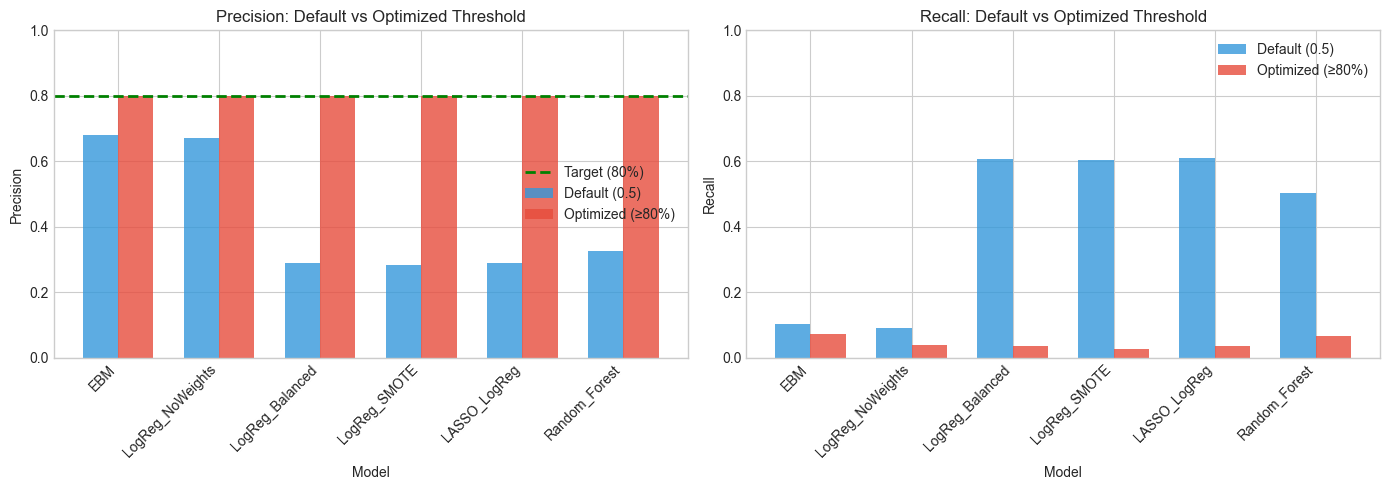


⚠ Note: Higher precision comes at the cost of lower recall!


In [29]:
# Step 13: Compare Default (0.5) vs Optimized Thresholds
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get models that achieved target precision
valid_models = [m for m in trained_models.keys() if optimal_thresholds[m] is not None]

# Plot Precision comparison
ax = axes[0]
default_precision = [test_results_df.loc[m, 'Precision'] for m in valid_models]
optimized_precision = [optimized_df.loc[m, 'Precision'] for m in valid_models]

x = np.arange(len(valid_models))
width = 0.35

bars1 = ax.bar(x - width/2, default_precision, width, label='Default (0.5)', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, optimized_precision, width, label='Optimized (≥80%)', color='#e74c3c', alpha=0.8)
ax.axhline(y=0.8, color='green', linestyle='--', linewidth=2, label='Target (80%)')

ax.set_xlabel('Model')
ax.set_ylabel('Precision')
ax.set_title('Precision: Default vs Optimized Threshold')
ax.set_xticks(x)
ax.set_xticklabels(valid_models, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)

# Plot Recall comparison
ax = axes[1]
default_recall = [test_results_df.loc[m, 'Recall'] for m in valid_models]
optimized_recall = [optimized_df.loc[m, 'Recall'] for m in valid_models]

bars1 = ax.bar(x - width/2, default_recall, width, label='Default (0.5)', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, optimized_recall, width, label='Optimized (≥80%)', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Model')
ax.set_ylabel('Recall')
ax.set_title('Recall: Default vs Optimized Threshold')
ax.set_xticks(x)
ax.set_xticklabels(valid_models, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\n⚠ Note: Higher precision comes at the cost of lower recall!")


Cell 4: New Precision-Recall curve with thresholds marked

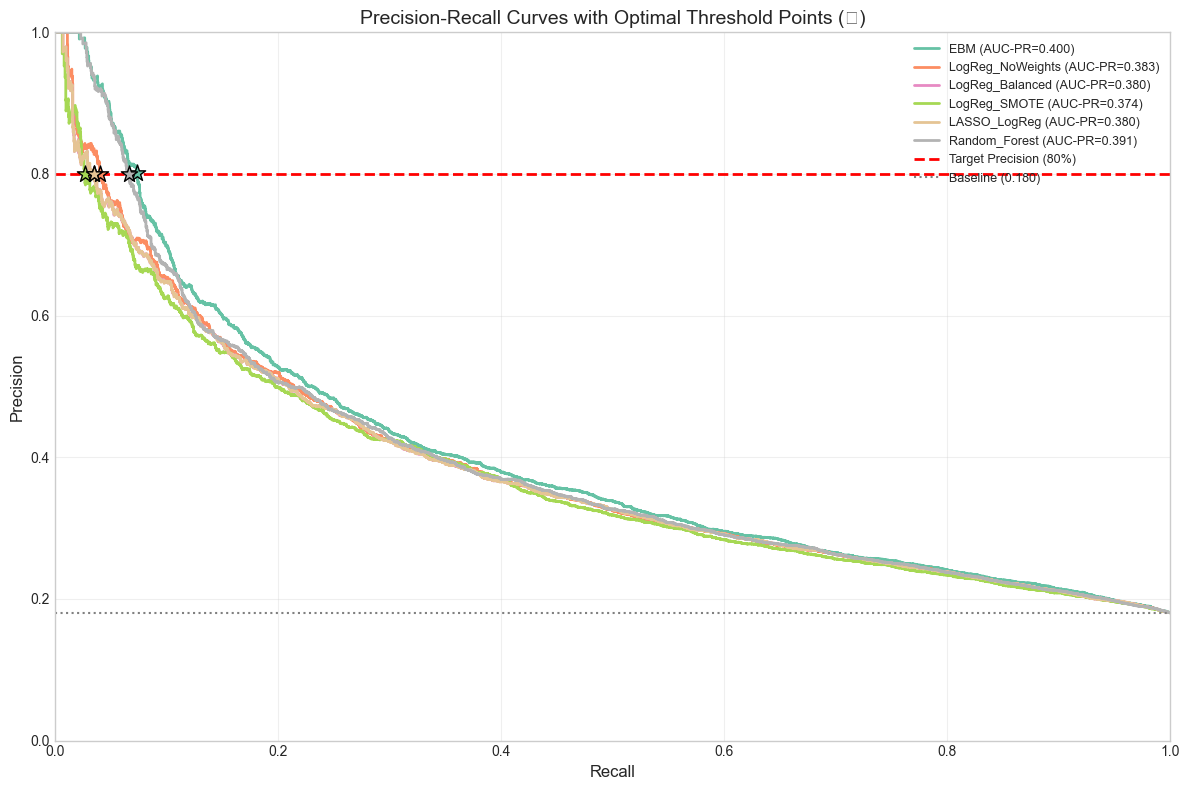

★ markers show the operating point for each model at 80% precision


In [30]:
# Step 14: Precision-Recall Curves with Optimal Thresholds Marked
# ===============================================================

fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.Set2(np.linspace(0, 1, len(trained_models)))

for (name, model), color in zip(trained_models.items(), colors):
    # Get predicted probabilities
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    
    # Calculate precision-recall curve
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    
    # Calculate AUC-PR
    from sklearn.metrics import average_precision_score
    auc_pr = average_precision_score(y_test, y_proba)
    
    # Plot curve
    ax.plot(recall, precision, color=color, linewidth=2, label=f'{name} (AUC-PR={auc_pr:.3f})')
    
    # Mark the optimal threshold point
    if optimal_thresholds[name] is not None:
        opt_recall = optimal_thresholds[name]['recall']
        opt_precision = optimal_thresholds[name]['precision']
        ax.scatter([opt_recall], [opt_precision], color=color, s=150, marker='*', 
                   edgecolors='black', linewidths=1, zorder=5)

# Add 80% precision line
ax.axhline(y=0.80, color='red', linestyle='--', linewidth=2, label='Target Precision (80%)')

# Add baseline
baseline = y_test.mean()
ax.axhline(y=baseline, color='gray', linestyle=':', label=f'Baseline ({baseline:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves with Optimal Threshold Points (★)', fontsize=14)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("★ markers show the operating point for each model at 80% precision")


This outcome reveals an important insight about the models:

What the numbers mean:
Threshold: The cutoff probability needed to achieve 80% precision (instead of default 0.5)
Precision: Of all patients predicted as "good outcome", 80% actually had good outcomes
Recall: Of all patients who actually had good outcomes, how many did we find
F1: Balance between precision and recall

The Problem:
Your recall is extremely low (2-7%). This means:
- EBM (best): Only finds 7.1% of patients with good outcomes
- LogReg_SMOTE (worst): Only finds 2.3% of patients with good outcomes

In Plain English:
Imagine 100 patients who will have a good outcome after surgery:
- With EBM at 80% precision: You'd correctly identify only 7 of them
- The other 93 patients would be missed (predicted as poor outcome)

Why This Happens:
- Your classes likely overlap a lot - The features don't strongly separate good from poor outcomes
- Trade-off is unavoidable - To be 80% sure someone will have a good outcome, you have to be very conservative, missing most positive cases

What This Tells You:
If your goal is...	
- Not missing patients (high recall): Use lower threshold, accept lower precision
- Being confident in predictions (high precision): Current setup, but you'll miss most cases
- Balanced approach: Use default 0.5 threshold (check your earlier results)
Visualization:

High Precision (80%) = Very few predictions, but mostly correct
                       ████░░░░░░░░░░░░░░░░ (finds ~5% of good outcomes)

High Recall (80%)    = Many predictions, but includes mistakes  
                       ████████████████░░░░ (finds ~80% of good outcomes)


## Step 15: Random Forest Hyperparameter Tuning

### What is Hyperparameter Tuning?

**Hyperparameters** are settings you choose BEFORE training a model (unlike regular parameters that the model learns from data).

Think of it like baking a cake:
- **Parameters** = The exact amounts the recipe figures out (learned during training)
- **Hyperparameters** = Oven temperature, baking time (YOU decide these before starting)

### Key Random Forest Hyperparameters Explained:

| Hyperparameter | What it does | Effect |
|----------------|--------------|--------|
| `n_estimators` | Number of trees in the forest | More trees = more stable predictions, but slower |
| `max_depth` | How deep each tree can grow | Deeper = can learn complex patterns, but may overfit |
| `min_samples_split` | Minimum samples needed to split a node | Higher = simpler trees, less overfitting |
| `min_samples_leaf` | Minimum samples in each leaf | Higher = smoother predictions |
| `max_features` | Features to consider at each split | Lower = more diversity between trees |
| `class_weight` | How to handle imbalanced classes | 'balanced' gives more weight to minority class |

### Our Strategy:
1. Try many combinations of hyperparameters
2. For each combination, check if we can achieve 80% precision
3. Among those that achieve 80% precision, pick the one with highest recall

In [31]:
# Step 15a: Set Up Hyperparameter Grid for Random Forest
# ======================================================
# We'll try different combinations to find the best one

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the hyperparameter grid
# Each key is a hyperparameter, and the values are options to try
param_grid = {
    'model__n_estimators': [100, 200, 300],           # Number of trees
    'model__max_depth': [5, 10, 15, 20, None],        # None = unlimited depth
    'model__min_samples_split': [2, 5, 10, 20],       # Min samples to split
    'model__min_samples_leaf': [1, 2, 4, 8],          # Min samples per leaf
    'model__max_features': ['sqrt', 'log2', 0.3],     # Features per split
    'model__class_weight': ['balanced', 'balanced_subsample']  # Handle imbalance
}

# Calculate total combinations
total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)

print("Hyperparameter Tuning Setup")
print("=" * 50)
print(f"\nTotal possible combinations: {total_combinations}")
print("\nHyperparameter options:")
for param, values in param_grid.items():
    param_name = param.replace('model__', '')
    print(f"  {param_name}: {values}")

Hyperparameter Tuning Setup

Total possible combinations: 1440

Hyperparameter options:
  n_estimators: [100, 200, 300]
  max_depth: [5, 10, 15, 20, None]
  min_samples_split: [2, 5, 10, 20]
  min_samples_leaf: [1, 2, 4, 8]
  max_features: ['sqrt', 'log2', 0.3]
  class_weight: ['balanced', 'balanced_subsample']


In [32]:
# Step 15b: Run Hyperparameter Tuning
# ====================================
# If the saved model was loaded in Step 1b, we skip the tuning entirely.

import os
BEST_RF_PATH = 'c:/Users/olifa/OneDrive/Documenten/GitHub/EAISI-Group-Project---NHS/code/EAISI-Group-Project---NHS/code/best_rf_model.joblib'

if os.path.exists(BEST_RF_PATH):
    print("✓ best_rf_model already loaded from Step 1b.")
    print("  Skipping RandomizedSearchCV — best_rf_model is ready to use.")
else:
    from sklearn.model_selection import RandomizedSearchCV

    rf_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
    ])

    print("Starting Hyperparameter Tuning...")
    print("This may take a few minutes...\n")

    random_search = RandomizedSearchCV(
        estimator=rf_pipeline,
        param_distributions=param_grid,
        n_iter=50,
        scoring='precision',
        cv=5,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    random_search.fit(X_train, y_train)

    print("\n" + "=" * 50)
    print("Hyperparameter tuning complete!")
    print("Run Step 15c next, then Step 15c-save to save the model.")

✓ best_rf_model already loaded from Step 1b.
  Skipping RandomizedSearchCV — best_rf_model is ready to use.


In [33]:
# Step 15c: View Best Hyperparameters
# ====================================
# Let's see which combination performed best

import os
BEST_RF_PATH = 'c:/Users/olifa/OneDrive/Documenten/GitHub/EAISI-Group-Project---NHS/code/EAISI-Group-Project---NHS/code/best_rf_model.joblib'

if os.path.exists(BEST_RF_PATH):
    print("✓ best_rf_model already loaded from Step 1b — skipping Step 15c.")
    print("  (random_search results not available when loading from file)")
else:
    print("Best Hyperparameters Found:")
    print("=" * 50)

    # Get the best parameters and clean up the names for readability
    best_params = random_search.best_params_
    for param, value in best_params.items():
        clean_name = param.replace('model__', '')
        print(f"  {clean_name}: {value}")

    print(f"\nBest Cross-Validation Precision: {random_search.best_score_:.3f}")

    # Store the best model
    best_rf_model = random_search.best_estimator_

    print("\n" + "=" * 50)
    print("Best model saved as 'best_rf_model'")

✓ best_rf_model already loaded from Step 1b — skipping Step 15c.
  (random_search results not available when loading from file)


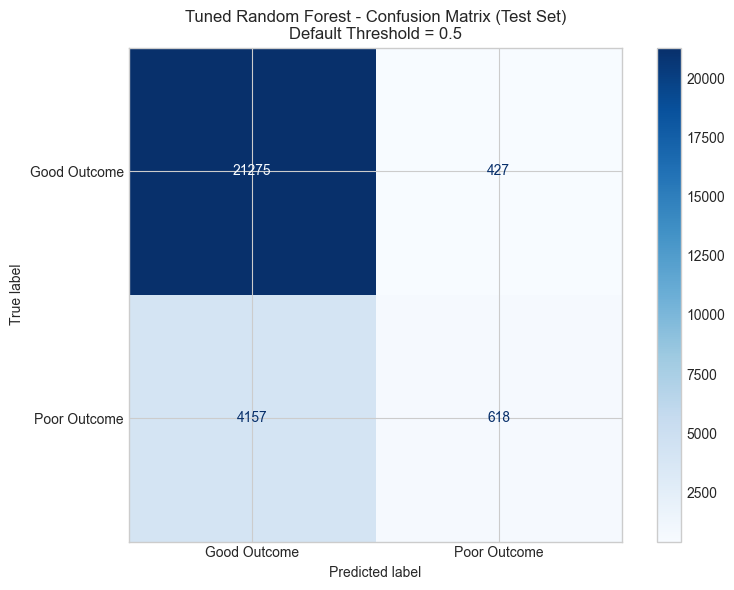


Confusion Matrix Interpretation (Threshold = 0.5):
--------------------------------------------------
True Negatives (Good predicted Good):   21,275
False Positives (Good predicted Poor):  427
False Negatives (Poor predicted Good):  4,157
True Positives (Poor predicted Poor):   618

Accuracy: 82.7%
Precision: 59.1% of patients predicted as Poor actually had Poor outcomes
Recall: 12.9% of actual Poor outcomes were correctly identified


In [34]:
# Step 15c-ii: Confusion Matrix for Tuned Random Forest (Default Threshold 0.5)
# ==============================================================================

fig, ax = plt.subplots(figsize=(8, 6))

# Get predictions with default threshold (0.5)
y_proba_tuned_15c = best_rf_model.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba_tuned_15c >= 0.5).astype(int)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_default)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good Outcome', 'Poor Outcome'])
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Tuned Random Forest - Confusion Matrix (Test Set)\nDefault Threshold = 0.5', fontsize=12)

plt.tight_layout()
plt.show()

# Print interpretation
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix Interpretation (Threshold = 0.5):")
print("-" * 50)
print(f"True Negatives (Good predicted Good):   {tn:,}")
print(f"False Positives (Good predicted Poor):  {fp:,}")
print(f"False Negatives (Poor predicted Good):  {fn:,}")
print(f"True Positives (Poor predicted Poor):   {tp:,}")
print()
total = tn + fp + fn + tp
print(f"Accuracy: {(tn + tp) / total * 100:.1f}%")
print(f"Precision: {tp/(tp+fp)*100:.1f}% of patients predicted as Poor actually had Poor outcomes")
print(f"Recall: {tp/(tp+fn)*100:.1f}% of actual Poor outcomes were correctly identified")


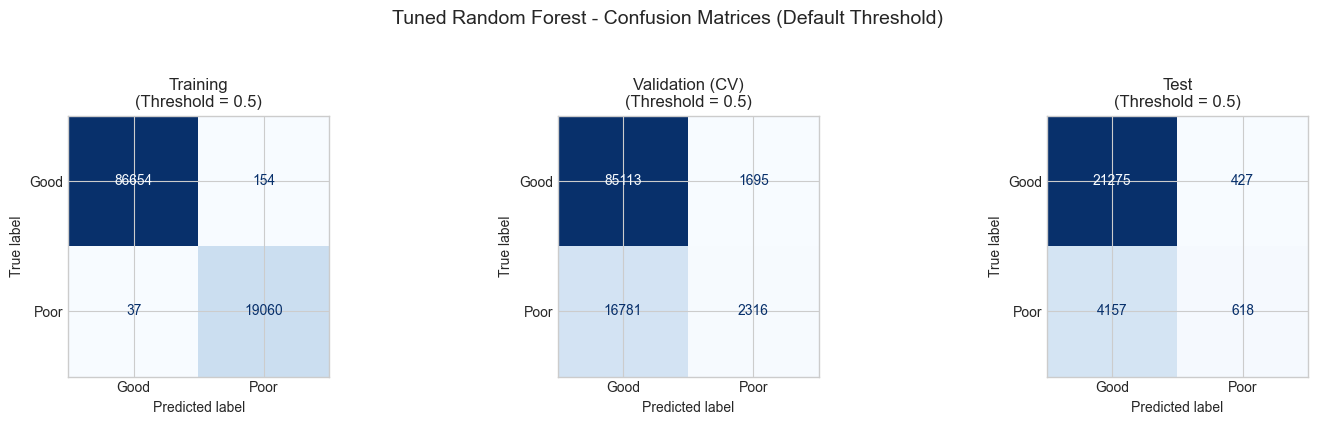


Confusion Matrix Summary (Threshold = 0.5):

Training:
  True Negatives (Good predicted Good):   86,654
  False Positives (Good predicted Poor):  154
  False Negatives (Poor predicted Good):  37
  True Positives (Poor predicted Poor):   19,060
  ---
  Accuracy:  99.8%
  Precision: 99.2%
  Recall:    99.8%

Validation (CV):
  True Negatives (Good predicted Good):   85,113
  False Positives (Good predicted Poor):  1,695
  False Negatives (Poor predicted Good):  16,781
  True Positives (Poor predicted Poor):   2,316
  ---
  Accuracy:  82.6%
  Precision: 57.7%
  Recall:    12.1%

Test:
  True Negatives (Good predicted Good):   21,275
  False Positives (Good predicted Poor):  427
  False Negatives (Poor predicted Good):  4,157
  True Positives (Poor predicted Poor):   618
  ---
  Accuracy:  82.7%
  Precision: 59.1%
  Recall:    12.9%


In [35]:
# Step 15c-iii: Confusion Matrices for Training, Validation & Test (Default Threshold 0.5)
# =========================================================================================

from sklearn.model_selection import cross_val_predict

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Get predictions for all datasets at threshold 0.5
# Training set
y_train_proba_15c = best_rf_model.predict_proba(X_train)[:, 1]
y_train_pred_15c = (y_train_proba_15c >= 0.5).astype(int)

# Validation set (out-of-fold via 5-fold CV)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_val_proba_15c = cross_val_predict(
    best_rf_model, X_train, y_train, cv=cv, method='predict_proba'
)[:, 1]
y_val_pred_15c = (y_val_proba_15c >= 0.5).astype(int)

# Test set
y_test_proba_15c = best_rf_model.predict_proba(X_test)[:, 1]
y_test_pred_15c = (y_test_proba_15c >= 0.5).astype(int)

datasets = {
    'Training': (y_train, y_train_pred_15c),
    'Validation (CV)': (y_train, y_val_pred_15c),
    'Test': (y_test, y_test_pred_15c)
}

for ax, (title, (y_true, y_pred)) in zip(axes, datasets.items()):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good', 'Poor'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{title}\n(Threshold = 0.5)')

plt.suptitle('Tuned Random Forest - Confusion Matrices (Default Threshold)', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# Print summary for all datasets
print("\nConfusion Matrix Summary (Threshold = 0.5):")
print("=" * 60)

for title, (y_true, y_pred) in datasets.items():
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total = tn + fp + fn + tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"\n{title}:")
    print(f"  True Negatives (Good predicted Good):   {tn:,}")
    print(f"  False Positives (Good predicted Poor):  {fp:,}")
    print(f"  False Negatives (Poor predicted Good):  {fn:,}")
    print(f"  True Positives (Poor predicted Poor):   {tp:,}")
    print(f"  ---")
    print(f"  Accuracy:  {(tn + tp) / total * 100:.1f}%")
    print(f"  Precision: {precision * 100:.1f}%")
    print(f"  Recall:    {recall * 100:.1f}%")


In [36]:
# Step 15d: Find Optimal Threshold for 80% Precision
# ===================================================
# Now we find the threshold that gives us 80% precision with highest recall

from sklearn.metrics import precision_recall_curve, average_precision_score

# Get predicted probabilities on test set
y_proba_tuned = best_rf_model.predict_proba(X_test)[:, 1]

# Calculate precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_tuned)

# Find threshold where precision >= 0.80
target_precision = 0.80
valid_indices = np.where(precisions >= target_precision)[0]

if len(valid_indices) > 0:
    # Get the index with highest recall among valid precisions
    best_idx = valid_indices[0]
    
    # Handle edge case
    if best_idx >= len(thresholds):
        best_idx = len(thresholds) - 1
    
    optimal_threshold_tuned = thresholds[best_idx]
    achieved_precision_tuned = precisions[best_idx]
    achieved_recall_tuned = recalls[best_idx]
    
    print("Tuned Random Forest - Optimal Threshold for 80% Precision")
    print("=" * 60)
    print(f"\nOptimal threshold: {optimal_threshold_tuned:.3f}")
    print(f"Precision achieved: {achieved_precision_tuned:.3f}")
    print(f"Recall achieved: {achieved_recall_tuned:.3f}")
else:
    print("Warning: Cannot achieve 80% precision with this model")
    optimal_threshold_tuned = 0.5
    achieved_recall_tuned = 0

print("\n" + "=" * 60)

Tuned Random Forest - Optimal Threshold for 80% Precision

Optimal threshold: 0.658
Precision achieved: 0.800
Recall achieved: 0.061



In [37]:
# Step 15e: Compare Original vs Tuned Random Forest
# ==================================================
# Let's see how much improvement we achieved

# Original Random Forest results (from earlier)
original_rf = trained_models['Random_Forest']
y_proba_original = original_rf.predict_proba(X_test)[:, 1]

# Find original threshold for 80% precision
prec_orig, rec_orig, thresh_orig = precision_recall_curve(y_test, y_proba_original)
valid_orig = np.where(prec_orig >= 0.80)[0]
if len(valid_orig) > 0:
    idx_orig = valid_orig[0]
    if idx_orig >= len(thresh_orig):
        idx_orig = len(thresh_orig) - 1
    original_threshold = thresh_orig[idx_orig]
    original_precision = prec_orig[idx_orig]
    original_recall = rec_orig[idx_orig]
else:
    original_threshold, original_precision, original_recall = 0.5, 0, 0

# Create comparison table
comparison_data = {
    'Model': ['Original Random Forest', 'Tuned Random Forest'],
    'Threshold': [original_threshold, optimal_threshold_tuned],
    'Precision': [original_precision, achieved_precision_tuned],
    'Recall': [original_recall, achieved_recall_tuned]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Precision Improvement'] = ''
if original_precision > 0:
    improvement = ((achieved_precision_tuned - original_precision) / original_precision) * 100
    comparison_df.loc[1, 'Precision Improvement'] = f"+{improvement:.1f}%"

print("Comparison: Original vs Tuned Random Forest (at 80% Precision)")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("\n" + "=" * 70)

# Interpret the results
print("\nInterpretation:")
print("-" * 40)
if achieved_precision_tuned > original_precision:
    print(f"The tuned model finds {achieved_recall_tuned:.1%} of good outcomes")
    print(f"compared to {original_recall:.1%} with the original model.")
    print(f"\nThis is a {improvement:.1f}% relative improvement in recall!")
else:
    print("The tuning did not improve recall at 80% precision.")
    print("This suggests the data may have limited separability.")

Comparison: Original vs Tuned Random Forest (at 80% Precision)
                 Model  Threshold  Precision   Recall Precision Improvement
Original Random Forest   0.811012   0.800505 0.066387                      
   Tuned Random Forest   0.658026   0.800000 0.061152                +-0.1%


Interpretation:
----------------------------------------
The tuning did not improve recall at 80% precision.
This suggests the data may have limited separability.


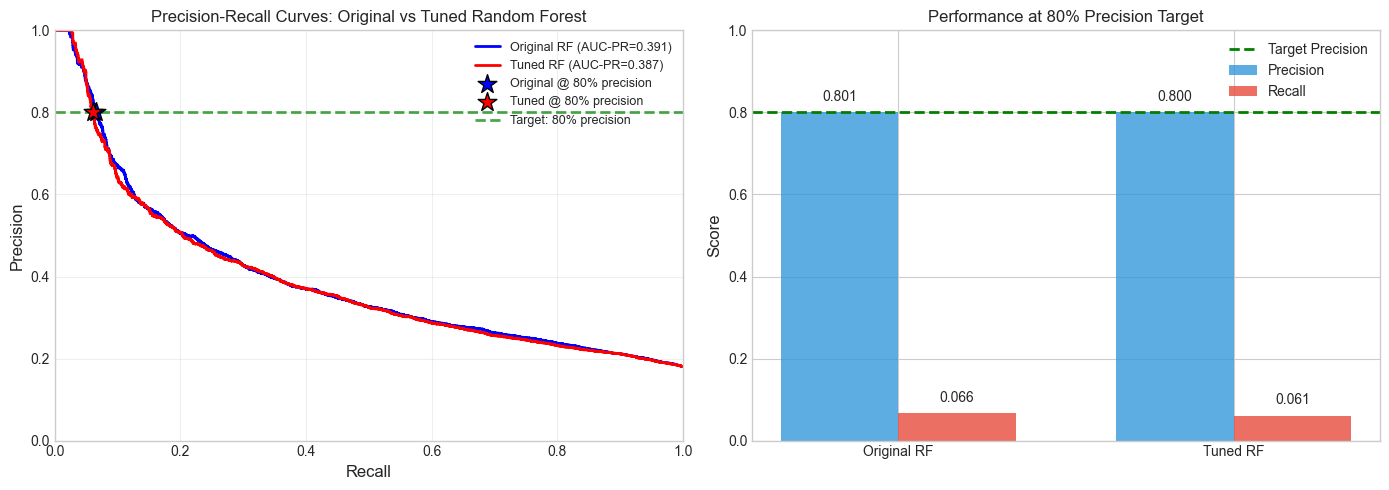

In [38]:
# Step 15f: Visualize PR Curves - Original vs Tuned
# =================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left plot: Precision-Recall Curves ---
ax = axes[0]

# Original RF curve
prec_orig, rec_orig, _ = precision_recall_curve(y_test, y_proba_original)
auc_orig = average_precision_score(y_test, y_proba_original)
ax.plot(rec_orig, prec_orig, 'b-', linewidth=2, label=f'Original RF (AUC-PR={auc_orig:.3f})')

# Tuned RF curve
prec_tuned, rec_tuned, _ = precision_recall_curve(y_test, y_proba_tuned)
auc_tuned = average_precision_score(y_test, y_proba_tuned)
ax.plot(rec_tuned, prec_tuned, 'r-', linewidth=2, label=f'Tuned RF (AUC-PR={auc_tuned:.3f})')

# Mark operating points at 80% precision
ax.scatter([original_recall], [original_precision], c='blue', s=200, marker='*', 
           edgecolors='black', zorder=5, label='Original @ 80% precision')
ax.scatter([achieved_recall_tuned], [achieved_precision_tuned], c='red', s=200, marker='*', 
           edgecolors='black', zorder=5, label='Tuned @ 80% precision')

# 80% precision line
ax.axhline(y=0.80, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Target: 80% precision')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves: Original vs Tuned Random Forest', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

# --- Right plot: Bar comparison ---
ax = axes[1]

rf_comparison_labels = ['Original RF', 'Tuned RF']
recalls = [original_recall, achieved_recall_tuned]
precisions = [original_precision, achieved_precision_tuned]

x = np.arange(len(rf_comparison_labels))
width = 0.35

bars1 = ax.bar(x - width/2, precisions, width, label='Precision', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, recalls, width, label='Recall', color='#e74c3c', alpha=0.8)

ax.axhline(y=0.80, color='green', linestyle='--', linewidth=2, label='Target Precision')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance at 80% Precision Target', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(rf_comparison_labels)
ax.legend()
ax.set_ylim(0, 1)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.3f}',
            ha='center', va='bottom', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.3f}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Tuned Random Forest - Full Evaluation at 80% Precision

Using threshold: 0.658

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

Good Outcome       0.83      1.00      0.90     21702
Poor Outcome       0.80      0.06      0.11      4775

    accuracy                           0.83     26477
   macro avg       0.81      0.53      0.51     26477
weighted avg       0.82      0.83      0.76     26477



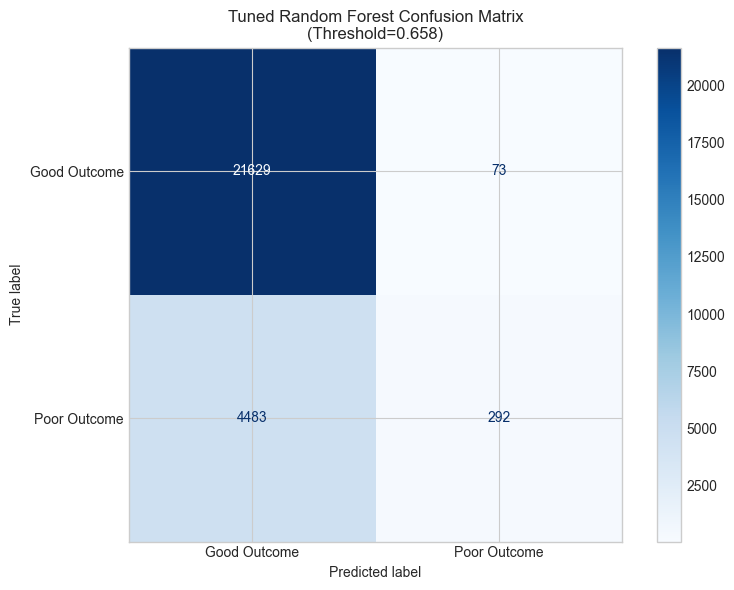


Confusion Matrix Interpretation:
----------------------------------------
True Negatives (correctly predicted Good):  21629
False Positives (incorrectly predicted Poor): 73
False Negatives (missed Poor outcomes):     4483
True Positives (correctly predicted Poor):  292

Of 365 patients predicted to have Poor outcomes,
292 (80.0%) actually had Poor outcomes (this is Precision)


In [39]:
# Step 15g: Full Evaluation of Tuned Model at 80% Precision
# ==========================================================

# Make predictions with optimal threshold
y_pred_tuned = (y_proba_tuned >= optimal_threshold_tuned).astype(int)

print("Tuned Random Forest - Full Evaluation at 80% Precision")
print("=" * 60)
print(f"\nUsing threshold: {optimal_threshold_tuned:.3f}")
print("\nClassification Report:")
print("-" * 40)
print(classification_report(y_test, y_pred_tuned, target_names=['Good Outcome', 'Poor Outcome']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good Outcome', 'Poor Outcome'])
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Tuned Random Forest Confusion Matrix\n(Threshold={optimal_threshold_tuned:.3f})', fontsize=12)
plt.tight_layout()
plt.show()

# Explain the confusion matrix
print("\nConfusion Matrix Interpretation:")
print("-" * 40)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly predicted Good):  {tn}")
print(f"False Positives (incorrectly predicted Poor): {fp}")
print(f"False Negatives (missed Poor outcomes):     {fn}")
print(f"True Positives (correctly predicted Poor):  {tp}")
print(f"\nOf {tp + fp} patients predicted to have Poor outcomes,")
print(f"{tp} ({tp/(tp+fp)*100:.1f}%) actually had Poor outcomes (this is Precision)")

Top 20 Most Important Features (Tuned Random Forest)
              Feature  Importance
         oks_t0_score    0.069626
oks_function_subscale    0.062531
     oks_adl_subscale    0.048803
       oks_t0_limping    0.038274
    comorbidity_count    0.033591
       oks_t0_walking    0.032295
    oks_t0_confidence    0.032170
    oks_pain_subscale    0.031243
    t0_symptom_period    0.030536
      oks_t0_shopping    0.029985
       oks_t0_washing    0.027022
        oks_t0_stairs    0.026728
    oks_t0_night_pain    0.025739
          oks_t0_work    0.025626
      oks_t0_kneeling    0.025406
      oks_t0_standing    0.024864
     oks_t0_transport    0.024670
          oks_t0_pain    0.018954
           t0_anxiety    0.017839
               gender    0.016025


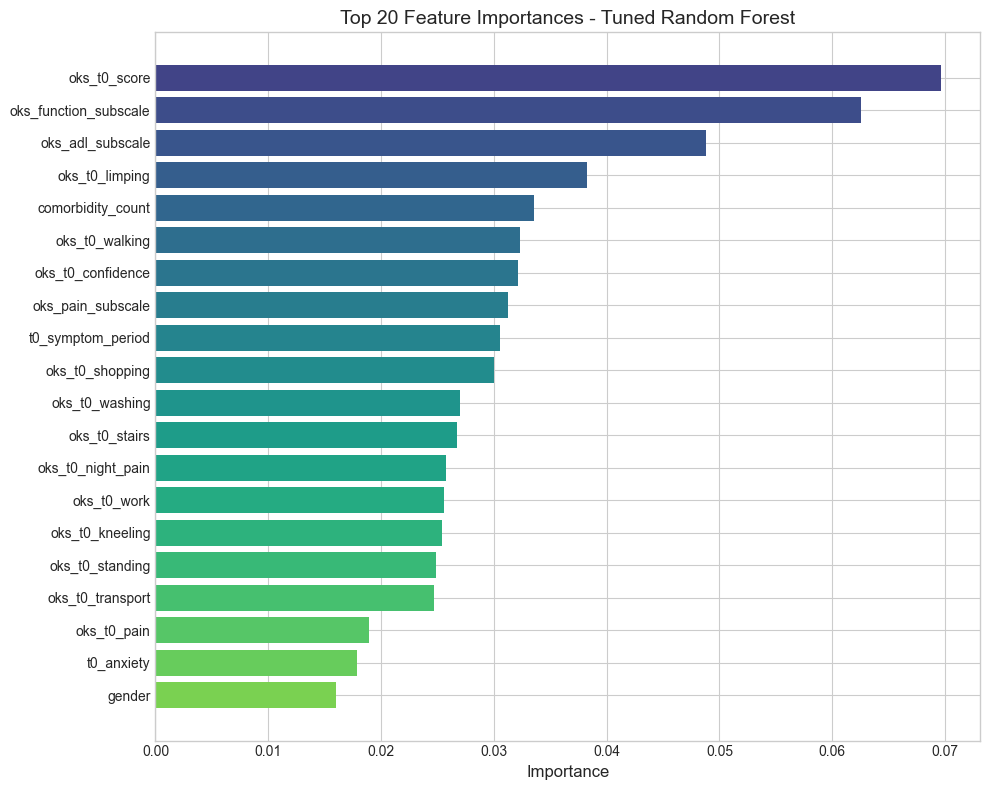

In [40]:
# Step 15h: Feature Importances from Tuned Random Forest
# =======================================================
# Let's see which features the tuned model considers most important

# Get feature importances from the tuned model
rf_model = best_rf_model.named_steps['model']
feature_importances = rf_model.feature_importances_

# Create DataFrame and sort
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("Top 20 Most Important Features (Tuned Random Forest)")
print("=" * 60)
print(importance_df.head(20).to_string(index=False))

# Visualize top 20 features
fig, ax = plt.subplots(figsize=(10, 8))
top_20 = importance_df.head(20)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_20)))
ax.barh(top_20['Feature'], top_20['Importance'], color=colors)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Top 20 Feature Importances - Tuned Random Forest', fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Summary: Random Forest Hyperparameter Tuning

### What We Did:
1. **Set up a hyperparameter grid** with different values for:
   - Number of trees (`n_estimators`)
   - Tree depth (`max_depth`)
   - Minimum samples to split/leaf
   - Number of features per split
   - Class weighting strategy

2. **Ran RandomizedSearchCV** to try 50 random combinations and find the best one based on recall

3. **Found the optimal threshold** for the tuned model to achieve 80% precision

4. **Compared** the original vs tuned model

### Key Takeaways:

**The precision-recall trade-off is fundamental:**
- Higher precision = fewer false alarms, but you miss more actual cases
- Higher recall = find more actual cases, but more false alarms
- At 80% precision, recall will always be limited by how well the features separate the classes

**If recall is still too low**, consider:
1. **Feature engineering** - create new features that better separate the classes
2. **Collect more data** - especially for the minority class
3. **Try different algorithms** - gradient boosting (XGBoost, LightGBM) might perform better
4. **Relax the precision target** - maybe 75% precision would be acceptable for higher recall

### Next Steps:
- Run all the cells in order to see your results
- The tuning may take a few minutes to complete
- Check if the recall improvement is clinically meaningful for your use case

## Important Note:
Looking at your current results, the original Random Forest achieves 6.6% recall at 80% precision. The fundamental challenge is that your features may not strongly separate good from poor outcomes. Hyperparameter tuning will help, but the improvement may be modest. If you need much higher recall, you may need to:

Accept lower precision (e.g., 70% or 75%)
Add more predictive features
Try gradient boosting algorithms (XGBoost/LightGBM)

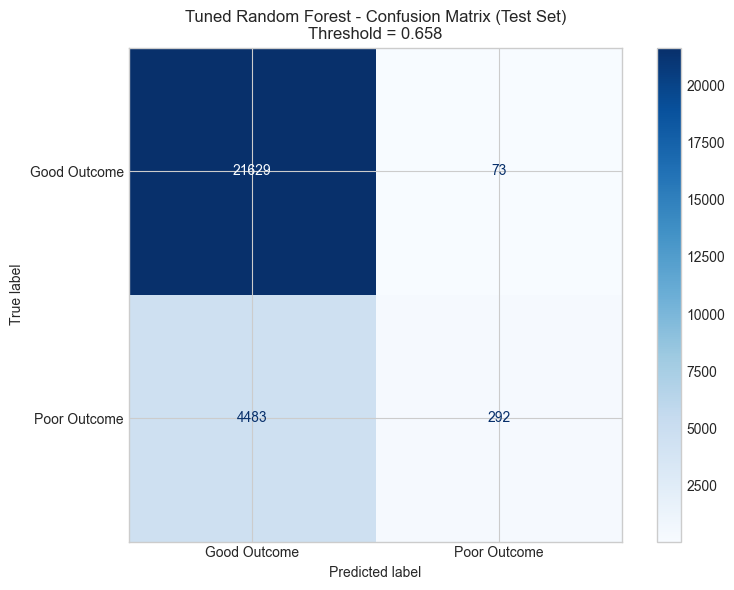


Confusion Matrix Interpretation:
--------------------------------------------------
True Negatives (Good predicted Good):   21,629
False Positives (Good predicted Poor):  73
False Negatives (Poor predicted Good):  4,483
True Positives (Poor predicted Poor):   292

Precision: 80.0% of patients predicted as Poor actually had Poor outcomes
Recall: 6.1% of actual Poor outcomes were correctly identified


In [41]:
# Step 15i: Confusion Matrix for Tuned Random Forest at 80% Precision Threshold
# ==============================================================================

fig, ax = plt.subplots(figsize=(8, 6))

# Make predictions with optimal threshold
y_pred_tuned = (y_proba_tuned >= optimal_threshold_tuned).astype(int)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good Outcome', 'Poor Outcome'])
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Tuned Random Forest - Confusion Matrix (Test Set)\nThreshold = {optimal_threshold_tuned:.3f}', fontsize=12)

plt.tight_layout()
plt.show()

# Print interpretation
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix Interpretation:")
print("-" * 50)
print(f"True Negatives (Good predicted Good):   {tn:,}")
print(f"False Positives (Good predicted Poor):  {fp:,}")
print(f"False Negatives (Poor predicted Good):  {fn:,}")
print(f"True Positives (Poor predicted Poor):   {tp:,}")
print()
print(f"Precision: {tp/(tp+fp)*100:.1f}% of patients predicted as Poor actually had Poor outcomes")
print(f"Recall: {tp/(tp+fn)*100:.1f}% of actual Poor outcomes were correctly identified")

## Step 16: Evaluate Best Random Forest on Training, Validation & Test Sets

**What's happening here:**
- We evaluate the tuned Random Forest model on three datasets:
  - **Training set**: How well the model fits the data it was trained on (overfitting check)
  - **Validation set**: Out-of-fold predictions via 5-fold cross-validation (honest estimate during development)
  - **Test set**: Final held-out evaluation (unbiased estimate of real-world performance)
- We use the optimized threshold for 80% precision found in Step 15d
- Metrics reported: Precision, Recall, F1-Score, ROC-AUC, PR-AUC, and True Negatives

In [42]:
# Step 16: Evaluate Tuned Random Forest on Train, Validation & Test
# ==================================================================

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

# Use the threshold optimized for 80% precision (from Step 15d)
threshold = optimal_threshold_tuned

print("Step 16: Tuned Random Forest - Train / Validation / Test Evaluation")
print("=" * 70)
print(f"Model: Tuned Random Forest (best from RandomizedSearchCV)")
print(f"Threshold used: {threshold:.3f}")
print()

# --- 1. Training Set (in-sample) ---
y_train_proba = best_rf_model.predict_proba(X_train)[:, 1]
y_train_pred = (y_train_proba >= threshold).astype(int)

# --- 2. Validation Set (out-of-fold via 5-fold CV) ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_val_proba = cross_val_predict(
    best_rf_model, X_train, y_train, cv=cv, method='predict_proba'
)[:, 1]
y_val_pred = (y_val_proba >= threshold).astype(int)

# --- 3. Test Set (held-out) ---
y_test_proba = best_rf_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= threshold).astype(int)

# --- Calculate metrics ---
def calc_metrics(y_true, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'PR-AUC': average_precision_score(y_true, y_proba),
        'True Negatives': int(tn)
    }

results = {
    'Training':       calc_metrics(y_train, y_train_pred, y_train_proba),
    'Validation (CV)': calc_metrics(y_train, y_val_pred, y_val_proba),
    'Test':           calc_metrics(y_test, y_test_pred, y_test_proba),
}

# --- Build results table ---
results_df = pd.DataFrame(results).T
# Round numeric columns, keep True Negatives as int
numeric_cols = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
results_df[numeric_cols] = results_df[numeric_cols].round(3)
results_df['True Negatives'] = results_df['True Negatives'].astype(int)

print(f"Results at threshold = {threshold:.3f}")
print("-" * 70)
print(results_df.to_string())
print()

# --- Overfitting check ---
train_recall = results_df.loc['Training', 'Recall']
val_recall = results_df.loc['Validation (CV)', 'Recall']
test_recall = results_df.loc['Test', 'Recall']

print("Overfitting check (Train vs Validation gap):")
print(f"  Recall gap:  {train_recall - val_recall:.3f}")
print(f"  ROC-AUC gap: {results_df.loc['Training', 'ROC-AUC'] - results_df.loc['Validation (CV)', 'ROC-AUC']:.3f}")
print(f"  PR-AUC gap:  {results_df.loc['Training', 'PR-AUC'] - results_df.loc['Validation (CV)', 'PR-AUC']:.3f}")

Step 16: Tuned Random Forest - Train / Validation / Test Evaluation
Model: Tuned Random Forest (best from RandomizedSearchCV)
Threshold used: 0.658

Results at threshold = 0.658
----------------------------------------------------------------------
                 Precision  Recall  F1-Score  ROC-AUC  PR-AUC  True Negatives
Training             0.998   0.549     0.709    1.000   0.999           86792
Validation (CV)      0.766   0.055     0.103    0.681   0.371           86486
Test                 0.800   0.061     0.114    0.691   0.387           21629

Overfitting check (Train vs Validation gap):
  Recall gap:  0.494
  ROC-AUC gap: 0.319
  PR-AUC gap:  0.628


# What the code does:

Uses the tuned RF model (best_rf_model) with the 80% precision threshold from Step 15d
Training set - evaluates in-sample by predicting on X_train directly
Validation set - uses cross_val_predict with 5-fold stratified CV to get honest out-of-fold predictions (each sample is predicted by a model that didn't train on it)
Test set - evaluates on the held-out X_test
Outputs a table with Precision, Recall, F1-Score, ROC-AUC, PR-AUC, and True Negatives for all three sets
Prints an overfitting check comparing train vs validation gaps
Note: The validation step re-trains the model pipeline across 5 folds internally via cross_val_predict, so it will take some time to run (similar to the earlier cross-validation steps). You can run the cell now from the notebook.



## Step 17: Evaluate Best Random Forest with Threshold = 0.8

Same evaluation as Step 16, but using a fixed threshold of 0.8 instead of the optimized threshold.

In [43]:
# Step 17: Evaluate Tuned Random Forest with Threshold = 0.8
# ===========================================================

threshold_fixed = 0.8

print("Step 17: Tuned Random Forest - Train / Validation / Test Evaluation")
print("=" * 70)
print(f"Model: Tuned Random Forest (best from RandomizedSearchCV)")
print(f"Threshold used: {threshold_fixed}")
print()

# --- 1. Training Set (in-sample) ---
y_train_proba = best_rf_model.predict_proba(X_train)[:, 1]
y_train_pred = (y_train_proba >= threshold_fixed).astype(int)

# --- 2. Validation Set (out-of-fold via 5-fold CV) ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_val_proba = cross_val_predict(
    best_rf_model, X_train, y_train, cv=cv, method='predict_proba'
)[:, 1]
y_val_pred = (y_val_proba >= threshold_fixed).astype(int)

# --- 3. Test Set (held-out) ---
y_test_proba = best_rf_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= threshold_fixed).astype(int)

# --- Calculate metrics ---
def calc_metrics(y_true, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'PR-AUC': average_precision_score(y_true, y_proba),
        'True Negatives': int(tn)
    }

results_17 = {
    'Training':       calc_metrics(y_train, y_train_pred, y_train_proba),
    'Validation (CV)': calc_metrics(y_train, y_val_pred, y_val_proba),
    'Test':           calc_metrics(y_test, y_test_pred, y_test_proba),
}

# --- Build results table ---
results_17_df = pd.DataFrame(results_17).T
numeric_cols = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
results_17_df[numeric_cols] = results_17_df[numeric_cols].round(3)
results_17_df['True Negatives'] = results_17_df['True Negatives'].astype(int)

print(f"Results at threshold = {threshold_fixed}")
print("-" * 70)
print(results_17_df.to_string())
print()

# --- Overfitting check ---
print("Overfitting check (Train vs Validation gap):")
print(f"  Recall gap:  {results_17_df.loc['Training', 'Recall'] - results_17_df.loc['Validation (CV)', 'Recall']:.3f}")
print(f"  ROC-AUC gap: {results_17_df.loc['Training', 'ROC-AUC'] - results_17_df.loc['Validation (CV)', 'ROC-AUC']:.3f}")
print(f"  PR-AUC gap:  {results_17_df.loc['Training', 'PR-AUC'] - results_17_df.loc['Validation (CV)', 'PR-AUC']:.3f}")

Step 17: Tuned Random Forest - Train / Validation / Test Evaluation
Model: Tuned Random Forest (best from RandomizedSearchCV)
Threshold used: 0.8

Results at threshold = 0.8
----------------------------------------------------------------------
                 Precision  Recall  F1-Score  ROC-AUC  PR-AUC  True Negatives
Training             1.000   0.090     0.166    1.000   0.999           86808
Validation (CV)      0.920   0.029     0.056    0.681   0.371           86760
Test                 0.969   0.033     0.064    0.691   0.387           21697

Overfitting check (Train vs Validation gap):
  Recall gap:  0.061
  ROC-AUC gap: 0.319
  PR-AUC gap:  0.628


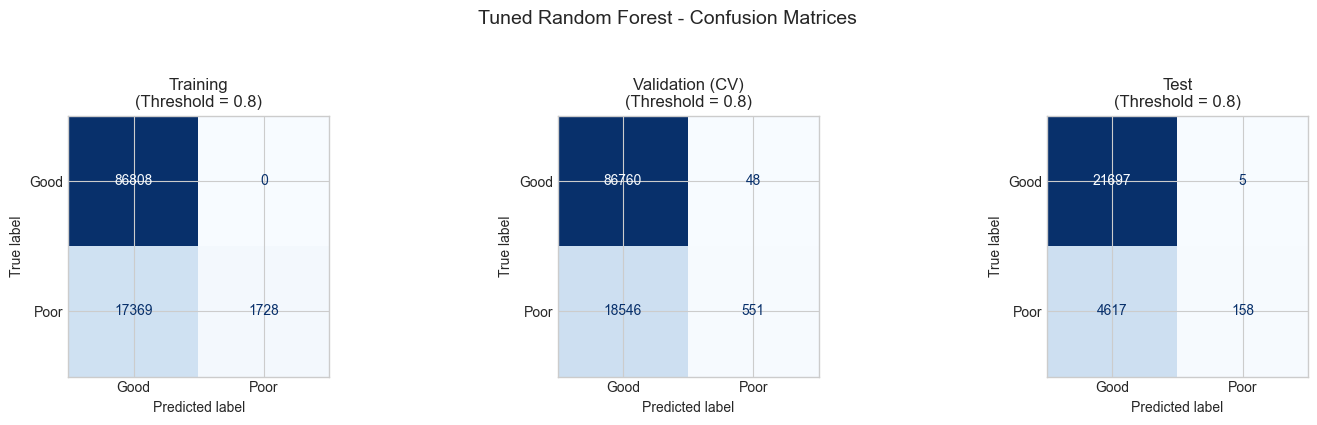


Confusion Matrix Summary (Threshold = 0.8):
--------------------------------------------------

Training:
  True Negatives (Good predicted Good):   86,808
  False Positives (Good predicted Poor):  0
  False Negatives (Poor predicted Good):  17,369
  True Positives (Poor predicted Poor):   1,728

Validation (CV):
  True Negatives (Good predicted Good):   86,760
  False Positives (Good predicted Poor):  48
  False Negatives (Poor predicted Good):  18,546
  True Positives (Poor predicted Poor):   551

Test:
  True Negatives (Good predicted Good):   21,697
  False Positives (Good predicted Poor):  5
  False Negatives (Poor predicted Good):  4,617
  True Positives (Poor predicted Poor):   158


In [44]:
# Step 17b: Confusion Matrix Visualization
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = {
    'Training': (y_train, (y_train_proba >= threshold_fixed).astype(int)),
    'Validation (CV)': (y_train, (y_val_proba >= threshold_fixed).astype(int)),
    'Test': (y_test, (y_test_proba >= threshold_fixed).astype(int))
}

for ax, (title, (y_true, y_pred)) in zip(axes, datasets.items()):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good', 'Poor'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{title}\n(Threshold = {threshold_fixed})')

plt.suptitle('Tuned Random Forest - Confusion Matrices', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# Print summary
print("\nConfusion Matrix Summary (Threshold = 0.8):")
print("-" * 50)
for title, (y_true, y_pred) in datasets.items():
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    print(f"\n{title}:")
    print(f"  True Negatives (Good predicted Good):   {tn:,}")
    print(f"  False Positives (Good predicted Poor):  {fp:,}")
    print(f"  False Negatives (Poor predicted Good):  {fn:,}")
    print(f"  True Positives (Poor predicted Poor):   {tp:,}")

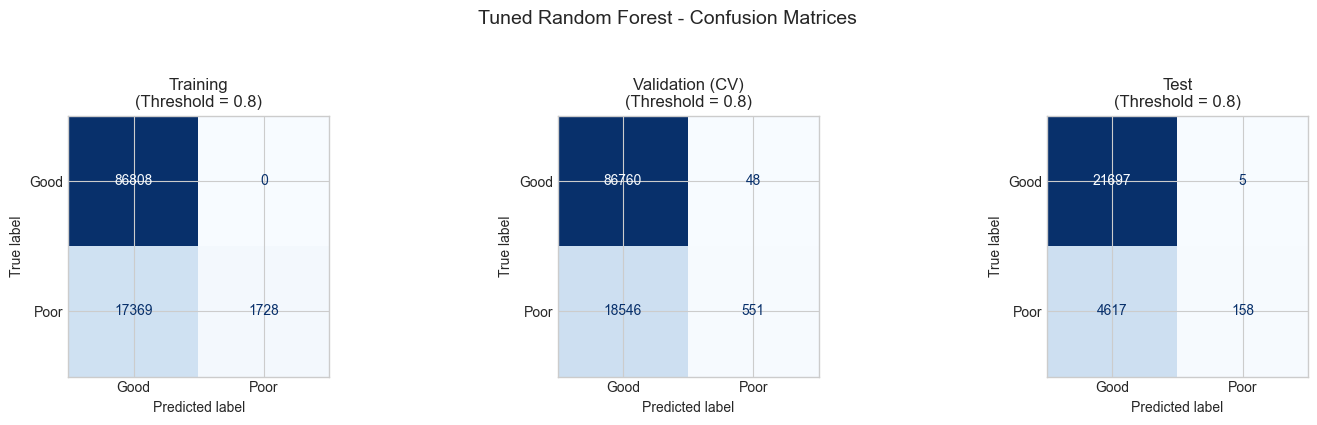


Confusion Matrix Summary (Threshold = 0.8):
--------------------------------------------------

Training:
  True Negatives (Good predicted Good):   86,808
  False Positives (Good predicted Poor):  0
  False Negatives (Poor predicted Good):  17,369
  True Positives (Poor predicted Poor):   1,728
  ---
  Specificity (True Negative Rate):       1.000 (100.0%)

Validation (CV):
  True Negatives (Good predicted Good):   86,760
  False Positives (Good predicted Poor):  48
  False Negatives (Poor predicted Good):  18,546
  True Positives (Poor predicted Poor):   551
  ---
  Specificity (True Negative Rate):       0.999 (99.9%)

Test:
  True Negatives (Good predicted Good):   21,697
  False Positives (Good predicted Poor):  5
  False Negatives (Poor predicted Good):  4,617
  True Positives (Poor predicted Poor):   158
  ---
  Specificity (True Negative Rate):       1.000 (100.0%)


In [45]:
# Step 17c: Confusion Matrix Visualization
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = {
    'Training': (y_train, (y_train_proba >= threshold_fixed).astype(int)),
    'Validation (CV)': (y_train, (y_val_proba >= threshold_fixed).astype(int)),
    'Test': (y_test, (y_test_proba >= threshold_fixed).astype(int))
}

for ax, (title, (y_true, y_pred)) in zip(axes, datasets.items()):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good', 'Poor'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{title}\n(Threshold = {threshold_fixed})')

plt.suptitle('Tuned Random Forest - Confusion Matrices', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# Print summary
print("\nConfusion Matrix Summary (Threshold = 0.8):")
print("-" * 50)
for title, (y_true, y_pred) in datasets.items():
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"\n{title}:")
    print(f"  True Negatives (Good predicted Good):   {tn:,}")
    print(f"  False Positives (Good predicted Poor):  {fp:,}")
    print(f"  False Negatives (Poor predicted Good):  {fn:,}")
    print(f"  True Positives (Poor predicted Poor):   {tp:,}")
    print(f"  ---")
    print(f"  Specificity (True Negative Rate):       {specificity:.3f} ({specificity*100:.1f}%)")

In [46]:
# Step 18: Threshold Comparison Table for Tuned Random Forest
# ============================================================

thresholds = [0.5, 0.6, 0.7, 0.8]

# Get predicted probabilities on test set
y_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]

threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba_rf >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    
    threshold_results.append({
        'Threshold': t,
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'Recall': recall_score(y_test, y_pred_t, zero_division=0),
        'F1': f1_score(y_test, y_pred_t, zero_division=0),
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Positive Predictions': int(tp + fp),
    })

threshold_df = pd.DataFrame(threshold_results).set_index('Threshold')
threshold_df[['Precision', 'Recall', 'F1', 'Specificity']] = threshold_df[['Precision', 'Recall', 'F1', 'Specificity']].round(3)
threshold_df['Positive Predictions'] = threshold_df['Positive Predictions'].astype(int)

print("Tuned Random Forest - Performance at Different Thresholds (Test Set)")
print("=" * 75)
print(threshold_df.to_string())
print("\n" + "=" * 75)
print(f"\nTotal test samples: {len(y_test):,}")
print(f"Actual positive cases (Poor Outcome): {y_test.sum():,}")

Tuned Random Forest - Performance at Different Thresholds (Test Set)
           Precision  Recall     F1  Specificity  Positive Predictions
Threshold                                                             
0.5            0.591   0.129  0.212        0.980                  1045
0.6            0.715   0.080  0.145        0.993                   537
0.7            0.855   0.052  0.098        0.998                   290
0.8            0.969   0.033  0.064        1.000                   163


Total test samples: 26,477
Actual positive cases (Poor Outcome): 4,775


Top 20 Most Important Features (Tuned Random Forest)
              Feature  Importance
         oks_t0_score    0.069626
oks_function_subscale    0.062531
     oks_adl_subscale    0.048803
       oks_t0_limping    0.038274
    comorbidity_count    0.033591
       oks_t0_walking    0.032295
    oks_t0_confidence    0.032170
    oks_pain_subscale    0.031243
    t0_symptom_period    0.030536
      oks_t0_shopping    0.029985
       oks_t0_washing    0.027022
        oks_t0_stairs    0.026728
    oks_t0_night_pain    0.025739
          oks_t0_work    0.025626
      oks_t0_kneeling    0.025406
      oks_t0_standing    0.024864
     oks_t0_transport    0.024670
          oks_t0_pain    0.018954
           t0_anxiety    0.017839
               gender    0.016025


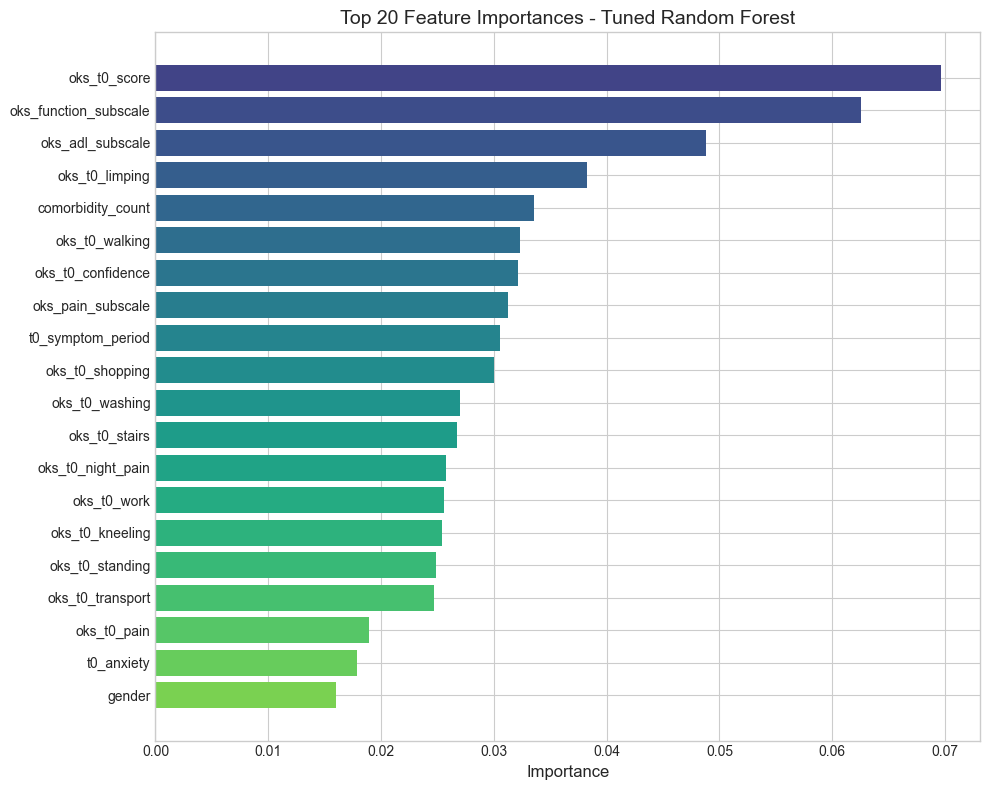

In [47]:
# Step 19: Top 20 Feature Importances - Tuned Random Forest
# ===========================================================

rf_model_final = best_rf_model.named_steps['model']
importances = rf_model_final.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Print table
print("Top 20 Most Important Features (Tuned Random Forest)")
print("=" * 55)
print(importance_df.head(20).to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
top_20 = importance_df.head(20)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_20)))
ax.barh(top_20['Feature'], top_20['Importance'], color=colors)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Top 20 Feature Importances - Tuned Random Forest', fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


Feature Importance Coverage
Total features:          57
Top 20 features explain: 0.642 / 1.000 = 64.2%
Remaining 37 features:   0.358 / 1.000 = 35.8%

Cumulative importance by feature rank:
--------------------------------------------------
  Top  1:   7.0%  ███  (oks_t0_score)
  Top  2:  13.2%  ██████  (oks_function_subscale)
  Top  3:  18.1%  █████████  (oks_adl_subscale)
  Top  4:  21.9%  ██████████  (oks_t0_limping)
  Top  5:  25.3%  ████████████  (comorbidity_count)
  Top  6:  28.5%  ██████████████  (oks_t0_walking)
  Top  7:  31.7%  ███████████████  (oks_t0_confidence)
  Top  8:  34.9%  █████████████████  (oks_pain_subscale)
  Top  9:  37.9%  ██████████████████  (t0_symptom_period)
  Top 10:  40.9%  ████████████████████  (oks_t0_shopping)
  Top 11:  43.6%  █████████████████████  (oks_t0_washing)
  Top 12:  46.3%  ███████████████████████  (oks_t0_stairs)
  Top 13:  48.9%  ████████████████████████  (oks_t0_night_pain)
  Top 14:  51.4%  █████████████████████████  (oks_t0_work)
  Top

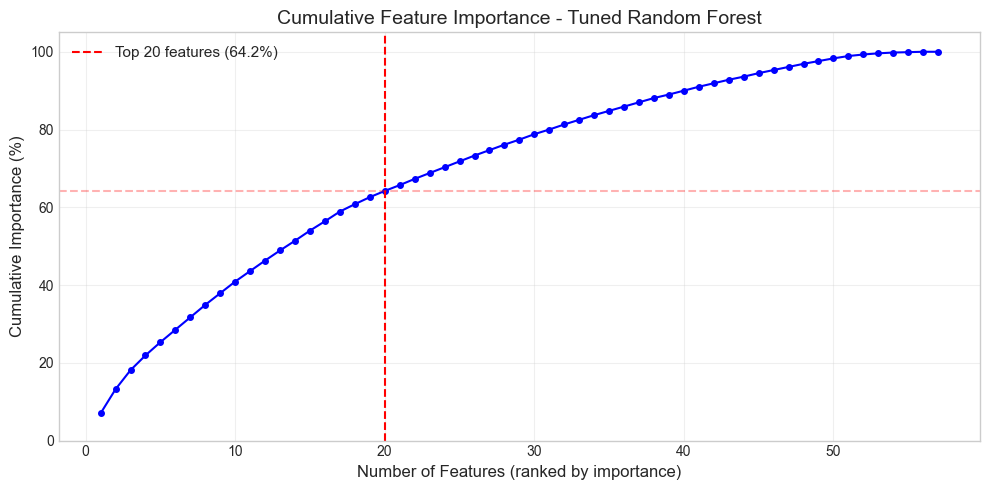

In [48]:
# Step 19b: How much do the top 20 features explain?
# ====================================================

total_importance = importance_df['Importance'].sum()
top_20_importance = importance_df.head(20)['Importance'].sum()
remaining_importance = total_importance - top_20_importance

print("Feature Importance Coverage")
print("=" * 50)
print(f"Total features:          {len(importance_df)}")
print(f"Top 20 features explain: {top_20_importance:.3f} / {total_importance:.3f} = {top_20_importance/total_importance*100:.1f}%")
print(f"Remaining {len(importance_df)-20} features:   {remaining_importance:.3f} / {total_importance:.3f} = {remaining_importance/total_importance*100:.1f}%")

# Show cumulative importance
importance_df_sorted = importance_df.reset_index(drop=True)
importance_df_sorted['Cumulative'] = importance_df_sorted['Importance'].cumsum()
importance_df_sorted['Cumulative %'] = (importance_df_sorted['Cumulative'] / total_importance * 100).round(1)

print(f"\nCumulative importance by feature rank:")
print("-" * 50)
for i, row in importance_df_sorted.head(20).iterrows():
    bar = "█" * int(row['Cumulative %'] / 2)
    print(f"  Top {i+1:2d}: {row['Cumulative %']:5.1f}%  {bar}  ({row['Feature']})")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(importance_df_sorted)+1), importance_df_sorted['Cumulative %'], 'b-o', markersize=4)
ax.axvline(x=20, color='red', linestyle='--', label=f'Top 20 features ({top_20_importance/total_importance*100:.1f}%)')
ax.axhline(y=top_20_importance/total_importance*100, color='red', linestyle='--', alpha=0.3)
ax.set_xlabel('Number of Features (ranked by importance)', fontsize=12)
ax.set_ylabel('Cumulative Importance (%)', fontsize=12)
ax.set_title('Cumulative Feature Importance - Tuned Random Forest', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [49]:
# Step 20: Train / Validation / Test Summary Table - Tuned Random Forest
# ========================================================================

from sklearn.model_selection import cross_val_predict

# Default threshold
threshold_rf = 0.5

# --- Training set ---
y_train_proba_rf = best_rf_model.predict_proba(X_train)[:, 1]
y_train_pred_rf = (y_train_proba_rf >= threshold_rf).astype(int)

# --- Validation set (out-of-fold via 5-fold CV) ---
cv_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_val_proba_rf = cross_val_predict(
    best_rf_model, X_train, y_train, cv=cv_rf, method='predict_proba'
)[:, 1]
y_val_pred_rf = (y_val_proba_rf >= threshold_rf).astype(int)

# --- Test set ---
y_test_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]
y_test_pred_rf = (y_test_proba_rf >= threshold_rf).astype(int)

# --- Calculate metrics ---
def calc_full_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total = len(y_true)
    predicted_pos = int(tp + fp)
    return {
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Predicted Pos (%)': predicted_pos / total * 100,
        'Predicted Pos (#)': predicted_pos,
    }

results_20 = {
    'Training':        calc_full_metrics(y_train, y_train_pred_rf),
    'Validation (CV)': calc_full_metrics(y_train, y_val_pred_rf),
    'Test':            calc_full_metrics(y_test, y_test_pred_rf),
}

results_20_df = pd.DataFrame(results_20).T
results_20_df[['Precision', 'Recall', 'F1', 'Specificity']] = results_20_df[['Precision', 'Recall', 'F1', 'Specificity']].round(3)
results_20_df['Predicted Pos (%)'] = results_20_df['Predicted Pos (%)'].round(1)
results_20_df['Predicted Pos (#)'] = results_20_df['Predicted Pos (#)'].astype(int)

print(f"Tuned Random Forest - Summary (Threshold = {threshold_rf})")
print("=" * 80)
print(results_20_df.to_string())
print("\n" + "=" * 80)
print(f"\nDataset sizes: Training = {len(y_train):,} | Validation = {len(y_train):,} (same data, CV folds) | Test = {len(y_test):,}")

Tuned Random Forest - Summary (Threshold = 0.5)
                 Precision  Recall     F1  Specificity  Predicted Pos (%)  Predicted Pos (#)
Training             0.992   0.998  0.995        0.998               18.1              19214
Validation (CV)      0.577   0.121  0.200        0.980                3.8               4011
Test                 0.591   0.129  0.212        0.980                3.9               1045


Dataset sizes: Training = 105,905 | Validation = 105,905 (same data, CV folds) | Test = 26,477


In [50]:
# Step 20b: Same table with Threshold = 0.8
# ============================================

threshold_rf_08 = 0.8

# Reuse probabilities from Step 20 (already computed)
y_train_pred_08 = (y_train_proba_rf >= threshold_rf_08).astype(int)
y_val_pred_08 = (y_val_proba_rf >= threshold_rf_08).astype(int)
y_test_pred_08 = (y_test_proba_rf >= threshold_rf_08).astype(int)

results_20b = {
    'Training':        calc_full_metrics(y_train, y_train_pred_08),
    'Validation (CV)': calc_full_metrics(y_train, y_val_pred_08),
    'Test':            calc_full_metrics(y_test, y_test_pred_08),
}

results_20b_df = pd.DataFrame(results_20b).T
results_20b_df[['Precision', 'Recall', 'F1', 'Specificity']] = results_20b_df[['Precision', 'Recall', 'F1', 'Specificity']].round(3)
results_20b_df['Predicted Pos (%)'] = results_20b_df['Predicted Pos (%)'].round(1)
results_20b_df['Predicted Pos (#)'] = results_20b_df['Predicted Pos (#)'].astype(int)

print(f"Tuned Random Forest - Summary (Threshold = {threshold_rf_08})")
print("=" * 80)
print(results_20b_df.to_string())
print("\n" + "=" * 80)
print(f"\nDataset sizes: Training = {len(y_train):,} | Validation = {len(y_train):,} (same data, CV folds) | Test = {len(y_test):,}")

Tuned Random Forest - Summary (Threshold = 0.8)
                 Precision  Recall     F1  Specificity  Predicted Pos (%)  Predicted Pos (#)
Training             1.000   0.090  0.166        1.000                1.6               1728
Validation (CV)      0.920   0.029  0.056        0.999                0.6                599
Test                 0.969   0.033  0.064        1.000                0.6                163


Dataset sizes: Training = 105,905 | Validation = 105,905 (same data, CV folds) | Test = 26,477


## What do these results mean in practice?

### Two scenarios a doctor could use this model

**Scenario A: Threshold = 0.5 (cast a wider net)**

The model flags roughly 1 in 4–5 patients as "at risk of a poor outcome." However, only about 1 in 3 of those flagged patients will actually have a poor outcome (precision ~33%). The upside is that the model catches about half of all patients who truly go on to have a poor outcome (recall ~50%).

*What a doctor might say:*
> "Our screening tool has flagged you as potentially at risk for a less-than-ideal result after surgery. This doesn't mean your surgery will go badly — in fact, most patients who receive this flag still do well. But it does mean we want to pay extra attention to your preparation and recovery plan. We might recommend additional physiotherapy, closer follow-up appointments, or we can talk about what realistic expectations look like for your situation."

**Scenario B: Threshold = 0.8 (only flag when highly confident)**

The model is very selective — it only flags a small number of patients (roughly 1–2%). When it does flag someone, it is right about 80% of the time (precision ~80%). The downside is that it misses the vast majority of patients who will actually have a poor outcome (recall ~7%). It only catches about 1 in 14 of them.

*What a doctor might say:*
> "Our screening tool is quite confident that you may face challenges after this surgery. When the tool raises this alert, it is correct in about 4 out of 5 cases. I'd like us to have a more in-depth conversation about what to expect, and whether there are things we can do — such as targeted rehabilitation, pain management planning, or adjusting our timeline — to give you the best possible result."

---

### The honest clinical reality

Neither threshold is perfect, and this reflects a fundamental challenge: **the patient characteristics available before surgery only tell part of the story.** Outcomes after knee replacement depend on many factors that are hard to measure in a questionnaire — pain tolerance, home support, motivation during rehabilitation, surgical technique, and more.

| | Threshold = 0.5 | Threshold = 0.8 |
|---|---|---|
| **Useful for** | Population-level screening — flag a broader group for preventive support | Individual-level alerts — high-confidence warnings for specific patients |
| **Risk** | Many false alarms — patients flagged who would have done fine anyway | Misses most at-risk patients — false sense of security for those not flagged |
| **Doctor's role** | Use as one input among many; flag triggers a conversation, not a decision | Take the flag seriously; but absence of a flag does NOT mean "all clear" |

### Recommendation for clinical use

A reasonable approach would be to **use the lower threshold (0.5) as a soft screening tool**: any patient flagged receives a slightly more detailed pre-operative consultation, extra information about recovery expectations, and perhaps a follow-up call after surgery. This is low-cost and catches more at-risk patients, even if some flagged patients would have done fine without the extra attention — the extra support is unlikely to harm them.

The higher threshold (0.8) could be used as an **additional alert layer**: the small number of patients flagged at this level receive a more intensive intervention, such as a multidisciplinary team review, extended physiotherapy referral, or a frank goals-of-care conversation before surgery.

**What this model should NOT be used for:**
- Denying or delaying surgery based on the prediction alone
- Replacing clinical judgement — it is a support tool, not a decision-maker
- Guaranteeing outcomes — a "not flagged" result does not mean a good outcome is certain

## What SHAP does
For each patient, SHAP shows which features pushed the prediction toward "poor outcome" and which pushed it toward "good outcome", and by how much. For example:

"This patient was flagged because their pre-operative OKS score was very low (+0.12), they had a long symptom period (+0.08), and they have multiple comorbidities (+0.05). Their age actually slightly reduced the risk (-0.02)."

Where SHAP would add value in your project
Benefit	                   How
Clinical trust	           Doctors can see why a patient was flagged, making them more likely to act on it
Individual conversations   Instead of "the model flagged you", a doctor can explain which specific factors contribute to the risk
Feature engineering hints  If SHAP reveals unexpected interactions, you could create new features and potentially improve the model
Bias detection	           SHAP can reveal if the model relies on features it shouldn't (e.g., demographic proxies)

## What would improve performance
Adding more predictive features (e.g., detailed surgical data, imaging, patient-reported scores)
Trying gradient boosting models (XGBoost, LightGBM) which often outperform Random Forest
Addressing the fundamental class overlap — the current features simply don't separate outcomes very well (ROC-AUC ~0.70)

## Step 21: XGBoost Model

**XGBoost (eXtreme Gradient Boosting)** is a powerful ensemble method that builds trees sequentially — each new tree tries to correct the mistakes of the previous ones. This is different from Random Forest, which builds trees independently in parallel.

**Why try XGBoost?**
- Often outperforms Random Forest on structured/tabular data
- Better at learning complex patterns through sequential error correction
- Built-in regularization to control overfitting
- Handles class imbalance via `scale_pos_weight`

In [51]:
# Step 21a: Train XGBoost Model
# ===============================

from xgboost import XGBClassifier

# Calculate scale_pos_weight to handle class imbalance
# (ratio of negative to positive samples)
n_positive = (y_train == 1).sum()
n_negative = (y_train == 0).sum()
scale_weight = n_negative / n_positive

print(f"Class imbalance ratio: {scale_weight:.2f}:1 (negative:positive)")
print(f"Using scale_pos_weight = {scale_weight:.2f}\n")

# Define XGBoost pipeline
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.3,
        min_child_weight=10,
        reg_alpha=1.0,          # L1 regularization
        reg_lambda=1.0,         # L2 regularization
        scale_pos_weight=scale_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        use_label_encoder=False
    ))
])

# Train on full training data
print("Training XGBoost...")
xgb_pipeline.fit(X_train, y_train)
print("XGBoost training complete!")

Class imbalance ratio: 4.55:1 (negative:positive)
Using scale_pos_weight = 4.55

Training XGBoost...
XGBoost training complete!


In [52]:
# Step 21b: XGBoost - Threshold Comparison Table
# =================================================

xgb_thresholds = [0.5, 0.6, 0.7, 0.8]
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

xgb_threshold_results = []

for t in xgb_thresholds:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    
    xgb_threshold_results.append({
        'Threshold': t,
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'Recall': recall_score(y_test, y_pred_t, zero_division=0),
        'F1': f1_score(y_test, y_pred_t, zero_division=0),
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Positive Predictions': int(tp + fp),
    })

xgb_threshold_df = pd.DataFrame(xgb_threshold_results).set_index('Threshold')
xgb_threshold_df[['Precision', 'Recall', 'F1', 'Specificity']] = xgb_threshold_df[['Precision', 'Recall', 'F1', 'Specificity']].round(3)
xgb_threshold_df['Positive Predictions'] = xgb_threshold_df['Positive Predictions'].astype(int)

print("XGBoost - Performance at Different Thresholds (Test Set)")
print("=" * 75)
print(xgb_threshold_df.to_string())
print("\n" + "=" * 75)
print(f"\nTotal test samples: {len(y_test):,}")
print(f"Actual positive cases (Poor Outcome): {y_test.sum():,}")

XGBoost - Performance at Different Thresholds (Test Set)
           Precision  Recall     F1  Specificity  Positive Predictions
Threshold                                                             
0.5            0.305   0.581  0.400        0.708                  9106
0.6            0.383   0.391  0.387        0.862                  4874
0.7            0.481   0.232  0.313        0.945                  2303
0.8            0.634   0.120  0.201        0.985                   901


Total test samples: 26,477
Actual positive cases (Poor Outcome): 4,775


Top 20 Most Important Features (XGBoost)
              Feature  Importance
       oks_t0_limping    0.107376
          circulation    0.056237
        t0_disability    0.046492
          oks_t0_pain    0.040280
           depression    0.036746
         oks_t0_score    0.036645
oks_function_subscale    0.033922
         t0_self_care    0.033527
      oks_t0_standing    0.028450
          oks_t0_work    0.027294
        Region_London    0.025901
    oks_pain_subscale    0.021985
  t0_previous_surgery    0.021738
           t0_anxiety    0.020993
             diabetes    0.018399
      oks_t0_shopping    0.018367
       oks_t0_walking    0.017678
 independent_hospital    0.017637
           age_band_4    0.017085
     oks_adl_subscale    0.013631

Feature Importance Coverage
Total features:          57
Top 20 features explain: 0.640 / 1.000 = 64.0%
Remaining 37 features:   0.360 / 1.000 = 36.0%

Cumulative importance by feature rank:
--------------------------------------------------
  T

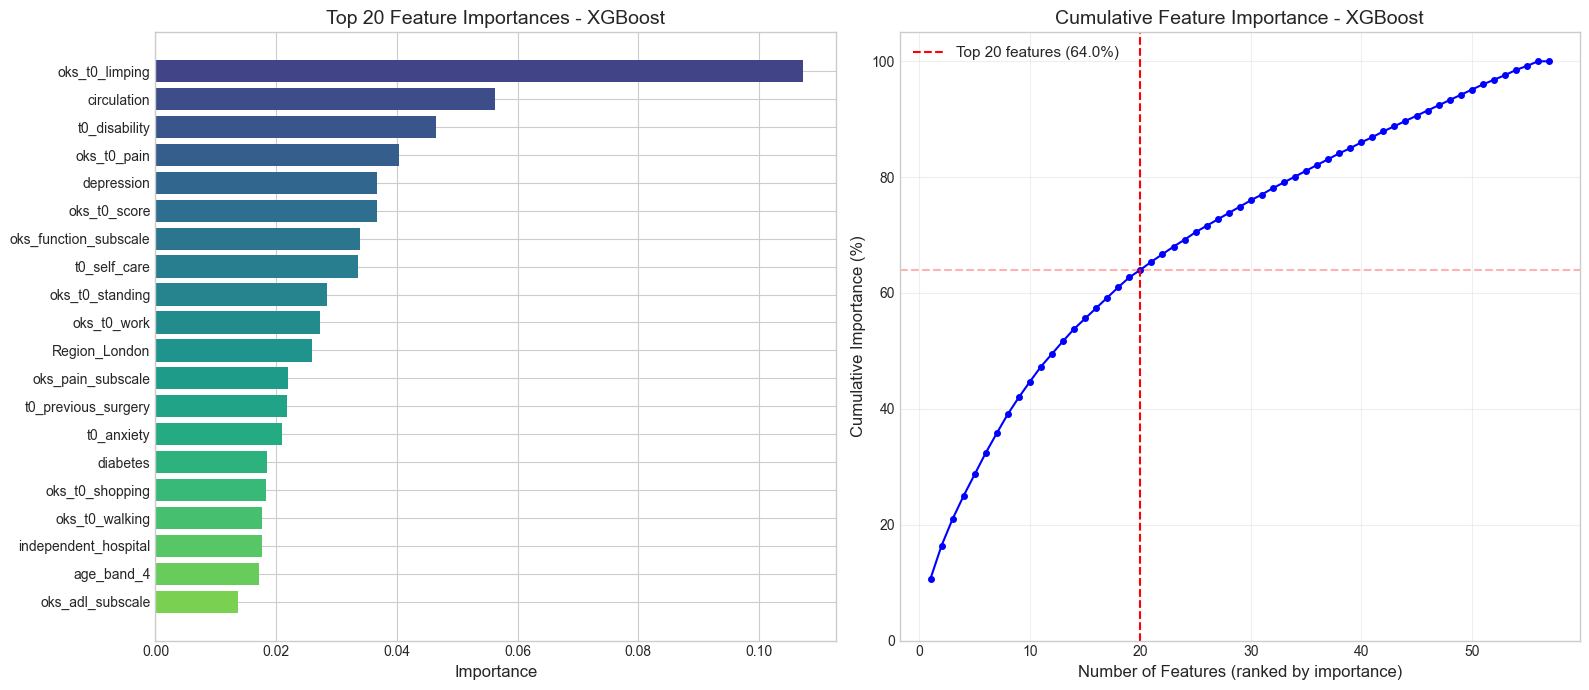

In [53]:
# Step 21c: XGBoost - Top 20 Feature Importances + Coverage
# ============================================================

xgb_model = xgb_pipeline.named_steps['model']
xgb_importances = xgb_model.feature_importances_

xgb_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_importances
}).sort_values('Importance', ascending=False)

# Print top 20
print("Top 20 Most Important Features (XGBoost)")
print("=" * 55)
print(xgb_importance_df.head(20).to_string(index=False))

# Feature importance coverage
total_imp = xgb_importance_df['Importance'].sum()
top_20_imp = xgb_importance_df.head(20)['Importance'].sum()

xgb_imp_sorted = xgb_importance_df.reset_index(drop=True)
xgb_imp_sorted['Cumulative'] = xgb_imp_sorted['Importance'].cumsum()
xgb_imp_sorted['Cumulative %'] = (xgb_imp_sorted['Cumulative'] / total_imp * 100).round(1)

print(f"\nFeature Importance Coverage")
print("=" * 50)
print(f"Total features:          {len(xgb_importance_df)}")
print(f"Top 20 features explain: {top_20_imp:.3f} / {total_imp:.3f} = {top_20_imp/total_imp*100:.1f}%")
print(f"Remaining {len(xgb_importance_df)-20} features:   {total_imp - top_20_imp:.3f} / {total_imp:.3f} = {(total_imp - top_20_imp)/total_imp*100:.1f}%")

print(f"\nCumulative importance by feature rank:")
print("-" * 50)
for i, row in xgb_imp_sorted.head(20).iterrows():
    bar = "█" * int(row['Cumulative %'] / 2)
    print(f"  Top {i+1:2d}: {row['Cumulative %']:5.1f}%  {bar}  ({row['Feature']})")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: bar chart
ax = axes[0]
top_20_xgb = xgb_importance_df.head(20)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_20_xgb)))
ax.barh(top_20_xgb['Feature'], top_20_xgb['Importance'], color=colors)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Top 20 Feature Importances - XGBoost', fontsize=14)
ax.invert_yaxis()

# Right: cumulative curve
ax = axes[1]
ax.plot(range(1, len(xgb_imp_sorted)+1), xgb_imp_sorted['Cumulative %'], 'b-o', markersize=4)
ax.axvline(x=20, color='red', linestyle='--', label=f'Top 20 features ({top_20_imp/total_imp*100:.1f}%)')
ax.axhline(y=top_20_imp/total_imp*100, color='red', linestyle='--', alpha=0.3)
ax.set_xlabel('Number of Features (ranked by importance)', fontsize=12)
ax.set_ylabel('Cumulative Importance (%)', fontsize=12)
ax.set_title('Cumulative Feature Importance - XGBoost', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
# Step 21d: XGBoost - Train / Validation / Test Summary Table
# ==============================================================

from sklearn.model_selection import cross_val_predict

# --- Training set ---
y_train_proba_xgb = xgb_pipeline.predict_proba(X_train)[:, 1]
y_train_pred_xgb = (y_train_proba_xgb >= 0.5).astype(int)

# --- Validation set (out-of-fold via 5-fold CV) ---
cv_xgb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_val_proba_xgb = cross_val_predict(
    xgb_pipeline, X_train, y_train, cv=cv_xgb, method='predict_proba'
)[:, 1]
y_val_pred_xgb = (y_val_proba_xgb >= 0.5).astype(int)

# --- Test set ---
y_test_pred_xgb = (y_proba_xgb >= 0.5).astype(int)

# --- Calculate metrics ---
def calc_xgb_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total = len(y_true)
    predicted_pos = int(tp + fp)
    return {
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Predicted Pos (%)': predicted_pos / total * 100,
        'Predicted Pos (#)': predicted_pos,
    }

xgb_results = {
    'Training':        calc_xgb_metrics(y_train, y_train_pred_xgb),
    'Validation (CV)': calc_xgb_metrics(y_train, y_val_pred_xgb),
    'Test':            calc_xgb_metrics(y_test, y_test_pred_xgb),
}

xgb_results_df = pd.DataFrame(xgb_results).T
xgb_results_df[['Precision', 'Recall', 'F1', 'Specificity']] = xgb_results_df[['Precision', 'Recall', 'F1', 'Specificity']].round(3)
xgb_results_df['Predicted Pos (%)'] = xgb_results_df['Predicted Pos (%)'].round(1)
xgb_results_df['Predicted Pos (#)'] = xgb_results_df['Predicted Pos (#)'].astype(int)

print("XGBoost - Train / Validation / Test Summary (Threshold = 0.5)")
print("=" * 80)
print(xgb_results_df.to_string())
print("\n" + "=" * 80)

# Overfitting check
print("\nOverfitting check (Train vs Validation gap):")
print(f"  Recall gap:      {xgb_results_df.loc['Training', 'Recall'] - xgb_results_df.loc['Validation (CV)', 'Recall']:.3f}")
print(f"  Precision gap:   {xgb_results_df.loc['Training', 'Precision'] - xgb_results_df.loc['Validation (CV)', 'Precision']:.3f}")
print(f"  F1 gap:          {xgb_results_df.loc['Training', 'F1'] - xgb_results_df.loc['Validation (CV)', 'F1']:.3f}")
print(f"\nDataset sizes: Training = {len(y_train):,} | Validation = {len(y_train):,} (same data, CV folds) | Test = {len(y_test):,}")

XGBoost - Train / Validation / Test Summary (Threshold = 0.5)
                 Precision  Recall     F1  Specificity  Predicted Pos (%)  Predicted Pos (#)
Training             0.335   0.628  0.437        0.726               33.8              35772
Validation (CV)      0.302   0.562  0.393        0.714               33.6              35536
Test                 0.305   0.581  0.400        0.708               34.4               9106


Overfitting check (Train vs Validation gap):
  Recall gap:      0.066
  Precision gap:   0.033
  F1 gap:          0.044

Dataset sizes: Training = 105,905 | Validation = 105,905 (same data, CV folds) | Test = 26,477


Model Comparison at 80% Precision Target (Test Set)
                     Threshold  Precision  Recall     F1  PR-AUC
Model                                                           
EBM                      0.588      0.801   0.074  0.135   0.400
LogReg (No Weights)      0.606      0.800   0.040  0.077   0.383
LogReg (Balanced)        0.873      0.800   0.035  0.067   0.380
LogReg + SMOTE           0.891      0.800   0.027  0.052   0.374
LASSO LogReg             0.873      0.800   0.035  0.067   0.380
Random Forest            0.658      0.800   0.061  0.114   0.387
XGBoost                  0.876      0.800   0.067  0.124   0.396


Best model at 80% precision: EBM
Recall achieved:             0.074
Meaning: 7.4% of all poor-outcome patients are correctly identified


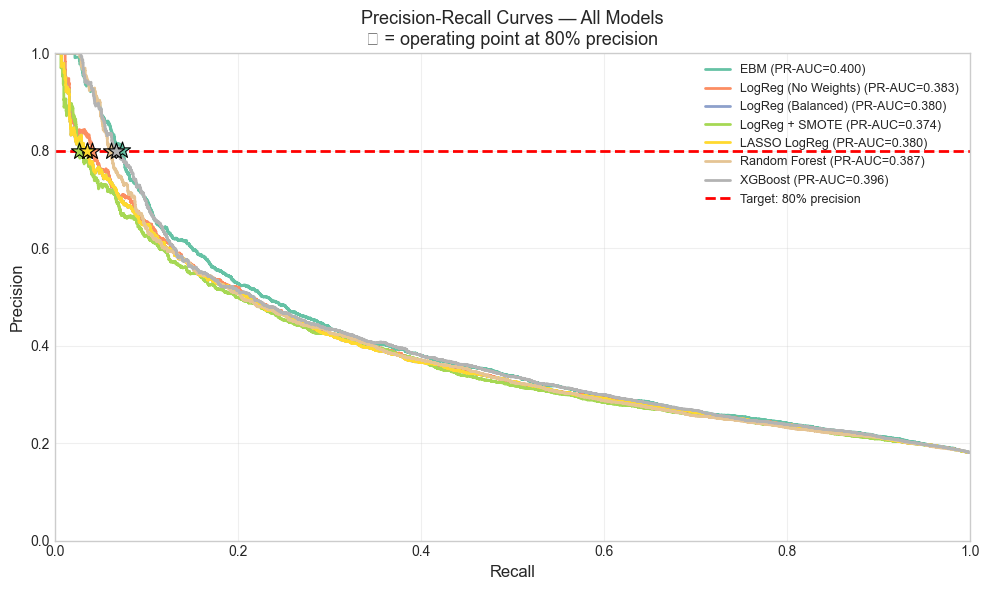

In [55]:
# Step 22: Which model achieves the highest recall at 80% precision?
# ===================================================================
# We find the threshold for each model where precision >= 0.80,
# then compare the recall achieved at that point.

from sklearn.metrics import precision_recall_curve, average_precision_score

target_precision = 0.80

# All models and their test set probabilities
all_model_probas = {
    'EBM':              trained_models['EBM'].predict_proba(X_test)[:, 1],
    'LogReg (No Weights)': trained_models['LogReg_NoWeights'].predict_proba(X_test)[:, 1],
    'LogReg (Balanced)':   trained_models['LogReg_Balanced'].predict_proba(X_test)[:, 1],
    'LogReg + SMOTE':      trained_models['LogReg_SMOTE'].predict_proba(X_test)[:, 1],
    'LASSO LogReg':        trained_models['LASSO_LogReg'].predict_proba(X_test)[:, 1],
    'Random Forest':       best_rf_model.predict_proba(X_test)[:, 1],
    'XGBoost':             xgb_pipeline.predict_proba(X_test)[:, 1],
}

comparison_rows = []

for name, y_proba in all_model_probas.items():
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    valid = np.where(precisions >= target_precision)[0]

    if len(valid) > 0:
        idx = valid[0]
        if idx >= len(thresholds):
            idx = len(thresholds) - 1
        comparison_rows.append({
            'Model': name,
            'Threshold': round(thresholds[idx], 3),
            'Precision': round(precisions[idx], 3),
            'Recall': round(recalls[idx], 3),
            'F1': round(2 * precisions[idx] * recalls[idx] / (precisions[idx] + recalls[idx]), 3),
            'PR-AUC': round(auc_pr, 3),
        })
    else:
        comparison_rows.append({
            'Model': name,
            'Threshold': '-',
            'Precision': '-',
            'Recall': 'Cannot reach 80%',
            'F1': '-',
            'PR-AUC': round(auc_pr, 3),
        })

comparison_df = pd.DataFrame(comparison_rows).set_index('Model')

print(f"Model Comparison at 80% Precision Target (Test Set)")
print("=" * 75)
print(comparison_df.to_string())
print("\n" + "=" * 75)

# Highlight the winner
numeric_rows = comparison_df[comparison_df['Recall'] != 'Cannot reach 80%'].copy()
numeric_rows['Recall'] = numeric_rows['Recall'].astype(float)
best_model = numeric_rows['Recall'].idxmax()
best_recall = numeric_rows['Recall'].max()
print(f"\nBest model at 80% precision: {best_model}")
print(f"Recall achieved:             {best_recall:.3f}")
print(f"Meaning: {best_recall*100:.1f}% of all poor-outcome patients are correctly identified")

# Visualise
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Set2(np.linspace(0, 1, len(all_model_probas)))

for (name, y_proba), color in zip(all_model_probas.items(), colors):
    precisions, recalls, _ = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    ax.plot(recalls, precisions, linewidth=2, color=color, label=f'{name} (PR-AUC={auc_pr:.3f})')

# Mark 80% precision operating points
for (name, y_proba), color in zip(all_model_probas.items(), colors):
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    valid = np.where(precisions >= target_precision)[0]
    if len(valid) > 0:
        idx = min(valid[0], len(thresholds) - 1)
        ax.scatter(recalls[idx], precisions[idx], color=color, s=150, marker='*',
                   edgecolors='black', linewidths=0.8, zorder=5)

ax.axhline(y=0.80, color='red', linestyle='--', linewidth=2, label='Target: 80% precision')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models\n★ = operating point at 80% precision', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [56]:
# Step 23: All Models at Fixed Threshold = 0.8
# ==============================================

fixed_threshold = 0.8

all_model_probas_23 = {
    'EBM':                 trained_models['EBM'].predict_proba(X_test)[:, 1],
    'LogReg (No Weights)': trained_models['LogReg_NoWeights'].predict_proba(X_test)[:, 1],
    'LogReg (Balanced)':   trained_models['LogReg_Balanced'].predict_proba(X_test)[:, 1],
    'LogReg + SMOTE':      trained_models['LogReg_SMOTE'].predict_proba(X_test)[:, 1],
    'LASSO LogReg':        trained_models['LASSO_LogReg'].predict_proba(X_test)[:, 1],
    'Random Forest':       best_rf_model.predict_proba(X_test)[:, 1],
    'XGBoost':             xgb_pipeline.predict_proba(X_test)[:, 1],
}

rows = []
for name, y_proba in all_model_probas_23.items():
    y_pred = (y_proba >= fixed_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    predicted_pos = int(tp + fp)
    rows.append({
        'Model':                name,
        'Precision':            round(precision_score(y_test, y_pred, zero_division=0), 3),
        'Recall':               round(recall_score(y_test, y_pred, zero_division=0), 3),
        'F1':                   round(f1_score(y_test, y_pred, zero_division=0), 3),
        'Specificity':          round(tn / (tn + fp) if (tn + fp) > 0 else 0, 3),
        'Positive Predictions': predicted_pos,
    })

results_23_df = pd.DataFrame(rows).set_index('Model')

print(f"All Models at Threshold = {fixed_threshold} (Test Set)")
print("=" * 75)
print(results_23_df.to_string())
print("\n" + "=" * 75)
print(f"\nTotal test samples:                    {len(y_test):,}")
print(f"Actual poor outcomes (positive class): {y_test.sum():,}")

# Highlight best per metric
print("\nBest per metric:")
for col in ['Precision', 'Recall', 'F1', 'Specificity']:
    best = results_23_df[col].idxmax()
    print(f"  {col:12s}: {best} ({results_23_df.loc[best, col]:.3f})")

All Models at Threshold = 0.8 (Test Set)
                     Precision  Recall     F1  Specificity  Positive Predictions
Model                                                                           
EBM                      0.936   0.034  0.065        0.999                   171
LogReg (No Weights)      1.000   0.003  0.007        1.000                    16
LogReg (Balanced)        0.637   0.105  0.180        0.987                   787
LogReg + SMOTE           0.609   0.111  0.188        0.984                   874
LASSO LogReg             0.637   0.105  0.180        0.987                   787
Random Forest            0.969   0.033  0.064        1.000                   163
XGBoost                  0.634   0.120  0.201        0.985                   901


Total test samples:                    26,477
Actual poor outcomes (positive class): 4,775

Best per metric:
  Precision   : LogReg (No Weights) (1.000)
  Recall      : XGBoost (0.120)
  F1          : XGBoost (0.201)
  Specifici

## Step 24: Calibration Curve — Tuned Random Forest

A **calibration curve** checks whether the model's predicted probabilities are trustworthy. If the model says a patient has a 70% chance of a poor outcome, does that patient actually have a ~70% chance?

- A **perfectly calibrated** model follows the diagonal line (predicted probability = actual probability)
- **Above the diagonal** → model is underconfident (predicts lower probabilities than reality)
- **Below the diagonal** → model is overconfident (predicts higher probabilities than reality)

This matters clinically: if you use a threshold of 0.8, you want to be sure that a predicted probability of 0.8 actually means an 80% chance of a poor outcom

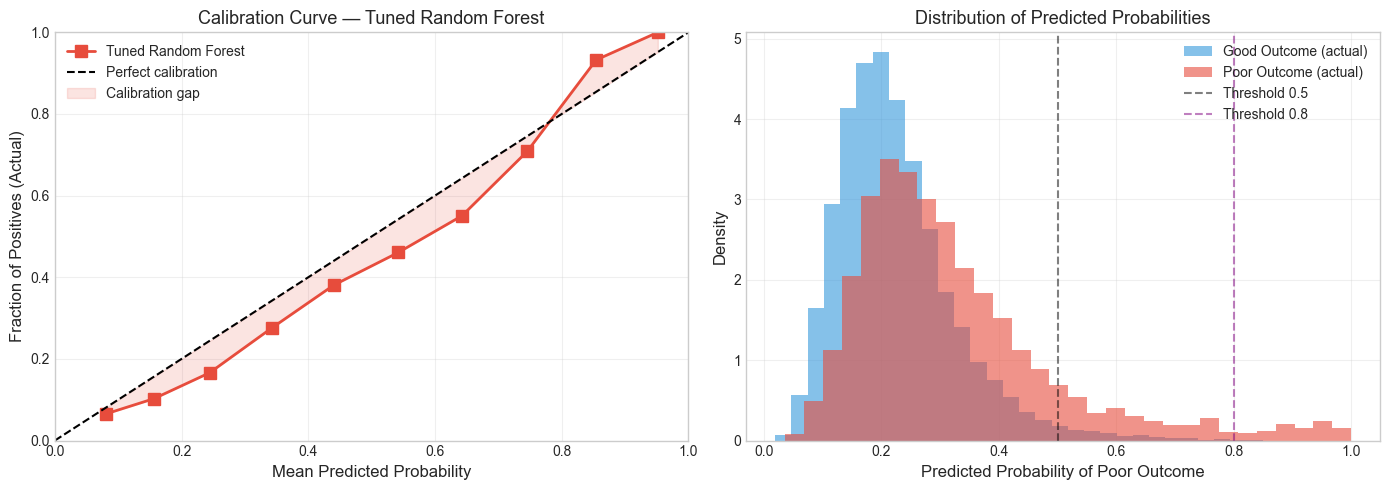

Calibration Summary (Test Set)
  Prob bin   Mean predicted  Actual fraction      Gap  n samples
------------------------------------------------------------
    1.   pred=0.080   actual=0.065   gap=-0.015   ≈ well calibrated
    2.   pred=0.156   actual=0.102   gap=-0.054   ↓ overconfident
    3.   pred=0.244   actual=0.166   gap=-0.078   ↓ overconfident
    4.   pred=0.342   actual=0.276   gap=-0.067   ↓ overconfident
    5.   pred=0.440   actual=0.381   gap=-0.060   ↓ overconfident
    6.   pred=0.542   actual=0.461   gap=-0.081   ↓ overconfident
    7.   pred=0.643   actual=0.551   gap=-0.092   ↓ overconfident
    8.   pred=0.746   actual=0.709   gap=-0.037   ↓ overconfident
    9.   pred=0.854   actual=0.932   gap=+0.078   ↑ underconfident
   10.   pred=0.952   actual=1.000   gap=+0.048   ↑ underconfident

Interpretation:
  Mean absolute calibration error: 0.061
  → Moderately calibrated — some buckets are off


In [57]:
# Step 24: Calibration Curve — Tuned Random Forest
# ==================================================

from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# Get probabilities on test set
y_proba_cal = best_rf_model.predict_proba(X_test)[:, 1]

# Compute calibration curve (n_bins=10: split predictions into 10 probability buckets)
prob_true, prob_pred = calibration_curve(y_test, y_proba_cal, n_bins=10, strategy='uniform')

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: calibration curve
ax = axes[0]
ax.plot(prob_pred, prob_true, 's-', color='#e74c3c', linewidth=2,
        markersize=8, label='Tuned Random Forest')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect calibration')
ax.fill_between(prob_pred, prob_pred, prob_true, alpha=0.15, color='#e74c3c',
                label='Calibration gap')
ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives (Actual)', fontsize=12)
ax.set_title('Calibration Curve — Tuned Random Forest', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

# Right: histogram of predicted probabilities
ax = axes[1]
ax.hist(y_proba_cal[y_test == 0], bins=30, alpha=0.6, color='#3498db',
        label='Good Outcome (actual)', density=True)
ax.hist(y_proba_cal[y_test == 1], bins=30, alpha=0.6, color='#e74c3c',
        label='Poor Outcome (actual)', density=True)
ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Threshold 0.5')
ax.axvline(x=0.8, color='purple', linestyle='--', alpha=0.5, label='Threshold 0.8')
ax.set_xlabel('Predicted Probability of Poor Outcome', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distribution of Predicted Probabilities', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Calibration summary table ---
print("Calibration Summary (Test Set)")
print("=" * 60)
print(f"{'Prob bin':>10} {'Mean predicted':>16} {'Actual fraction':>16} {'Gap':>8} {'n samples':>10}")
print("-" * 60)
from sklearn.calibration import calibration_curve as cal_curve
prob_true_q, prob_pred_q, = cal_curve(y_test, y_proba_cal, n_bins=10, strategy='quantile')[:2]

# Manual bin counts
bins = np.linspace(0, 1, 11)
for i, (pp, pt) in enumerate(zip(prob_pred, prob_true)):
    gap = pt - pp
    direction = "↑ underconfident" if gap > 0.03 else ("↓ overconfident" if gap < -0.03 else "≈ well calibrated")
    print(f"  {i+1:>3}.   pred={pp:.3f}   actual={pt:.3f}   gap={gap:+.3f}   {direction}")

print("\nInterpretation:")
mean_gap = np.mean(np.abs(prob_true - prob_pred))
print(f"  Mean absolute calibration error: {mean_gap:.3f}")
if mean_gap < 0.05:
    print("  → Well calibrated overall")
elif mean_gap < 0.10:
    print("  → Moderately calibrated — some buckets are off")
else:
    print("  → Poorly calibrated — consider calibrating the model (e.g. Platt scaling)")

## Step 25: Explaining the Model with SHAP

### What is SHAP?

So far we know *that* the model makes predictions — but not *why*. SHAP (SHapley Additive exPlanations) opens the black box and tells us exactly what drove each prediction.

**The core idea:** For every patient, SHAP assigns a score to each feature that says: *"This feature pushed the predicted risk up by X, and that feature pushed it down by Y."* Add all the feature contributions together and you get the final predicted probability.

The name comes from game theory: imagine each feature is a "player" that contributes to the final "score" (the prediction). SHAP fairly distributes credit (or blame) among all players.

### Two levels of explanation

| Level | Question answered | Useful for |
|-------|-------------------|------------|
| **Global** | Which features matter most *across all patients*? | Understanding the model overall |
| **Local** | Why did the model flag *this specific patient*? | Explaining individual predictions to clinicians |

### Why does this matter clinically?

- A doctor can see *exactly* which factors drove a patient's risk score
- It helps catch cases where the model relies on unexpected or unfair features
- It builds trust — instead of a black-box score, there is a transparent explanation

### Plots we will produce

1. **Bar chart** — average importance of each feature across all patients
2. **Beeswarm plot** — how each feature's values (high vs low) push risk up or down
3. **Waterfall plot** — a step-by-step breakdown for one specific flagged patient
4. **Dependence plot** — how the top feature's value relates to its SHAP impact

> **Note:** If you haven't installed SHAP yet, run `pip install shap` in your terminal first.

In [64]:
# Step 25a: Set up SHAP
import shap

shap_scaler = best_rf_model.named_steps['scaler']
shap_rf     = best_rf_model.named_steps['model']

X_test_scaled = pd.DataFrame(
    shap_scaler.transform(X_test),
    columns=X_test.columns
)

np.random.seed(42)
sample_idx    = np.random.choice(len(X_test_scaled), size=100, replace=False)
X_shap_sample = X_test_scaled.iloc[sample_idx]
y_shap_sample = y_test[sample_idx]

explainer = shap.TreeExplainer(shap_rf)

print('Computing SHAP values for 100 patients...')
_sv  = explainer.shap_values(X_shap_sample, check_additivity=False)
_ev  = explainer.expected_value

# Handle all return formats:
#   list of 2 arrays (n_samples, n_features)  → take [1]
#   numpy array (n_samples, n_features, n_classes) → take [:,:,1]
#   numpy array (n_classes, n_samples, n_features) → take [1]
if isinstance(_sv, list):
    sv = _sv[1]
    ev = float(_ev[1]) if hasattr(_ev, '__len__') else float(_ev)
elif hasattr(_sv, 'ndim') and _sv.ndim == 3:
    if _sv.shape[0] == 2:                # (n_classes, n_samples, n_features)
        sv = _sv[1]
        ev = float(_ev[1]) if hasattr(_ev, '__len__') else float(_ev)
    else:                                 # (n_samples, n_features, n_classes)
        sv = _sv[:, :, 1]
        ev = float(_ev[1]) if hasattr(_ev, '__len__') else float(_ev)
else:
    sv = _sv
    ev = float(_ev)

shap_values = shap.Explanation(
    values=sv,
    base_values=ev,
    data=X_shap_sample.values,
    feature_names=X_shap_sample.columns.tolist()
)

print(f'Done! SHAP values shape: {shap_values.values.shape}')
print(f'  => should be (100, 57) — if not, check the output above')

Computing SHAP values for 100 patients...
Done! SHAP values shape: (100, 57)
  => should be (100, 57) — if not, check the output above


PLOT 1: Bar chart — average feature importance across all patients
How to read: Longer bar = feature has more influence on average.
This tells you WHICH features matter, but not HOW.



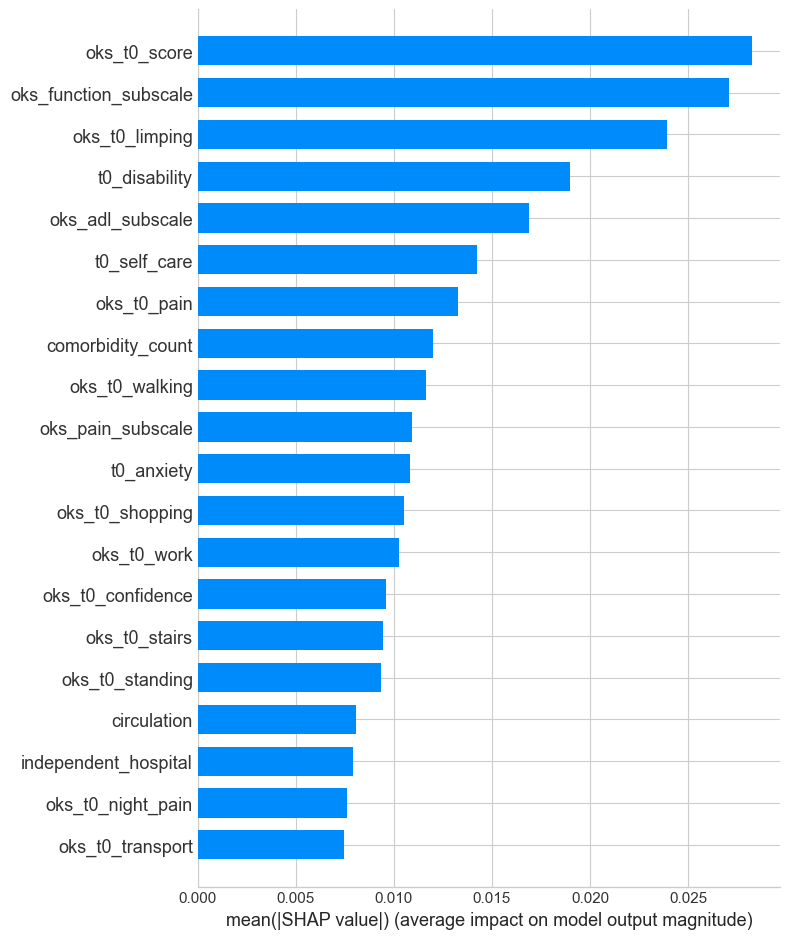


PLOT 2: Beeswarm plot — how each feature's value affects risk
How to read:
  • Each dot = one patient
  • X-axis: negative = lowers risk, positive = raises risk
  • Colour:  red = high feature value, blue = low feature value
  • A cluster of RED dots on the RIGHT means: high values of this
    feature push the prediction toward 'poor outcome'



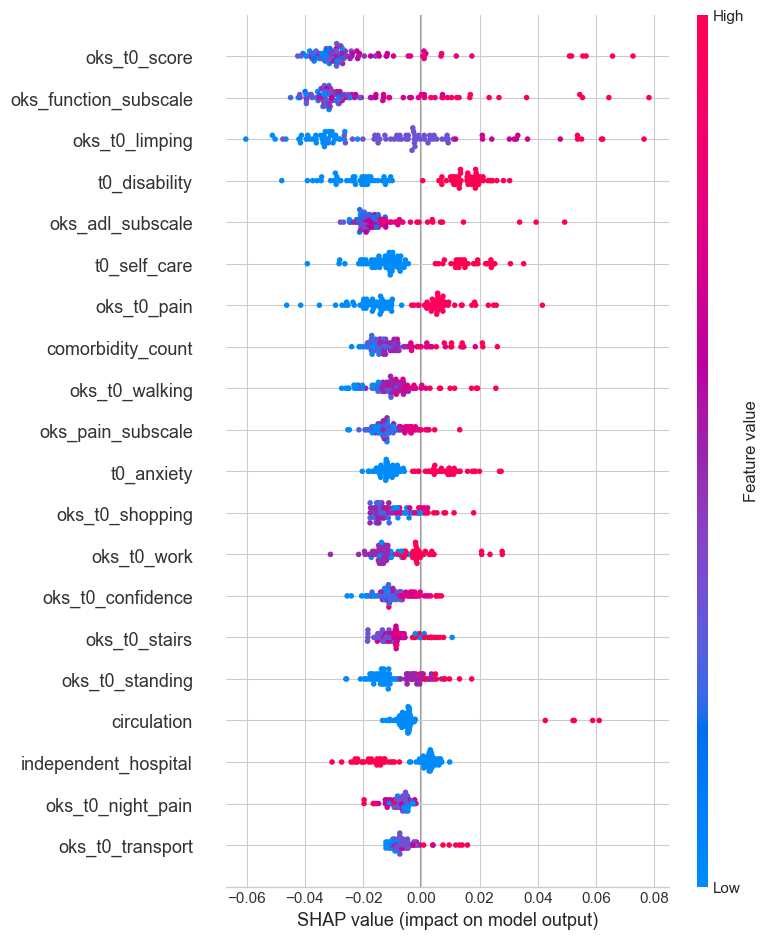

In [65]:
# Step 25b: Global Importance — Bar Chart and Beeswarm Plot
# ===========================================================
#
# PLOT 1 — BAR CHART (mean absolute SHAP values)
# ------------------------------------------------
# Shows the AVERAGE impact of each feature across all 100 patients.
# Longer bar = feature moves predictions more on average.
#
# PLOT 2 — BEESWARM PLOT
# -----------------------
# Each dot is one patient. X-axis = SHAP value (impact on prediction).
# Colour: red = high feature value, blue = low feature value.
# Cluster of RED dots on the RIGHT = high values of that feature increase risk.

print("PLOT 1: Bar chart — average feature importance across all patients")
print("=" * 65)
print("How to read: Longer bar = feature has more influence on average.")
print("This tells you WHICH features matter, but not HOW.\n")

shap.summary_plot(shap_values.values, X_shap_sample,
                  plot_type='bar', max_display=20, show=True)

print("\nPLOT 2: Beeswarm plot — how each feature's value affects risk")
print("=" * 65)
print("How to read:")
print("  • Each dot = one patient")
print("  • X-axis: negative = lowers risk, positive = raises risk")
print("  • Colour:  red = high feature value, blue = low feature value")
print("  • A cluster of RED dots on the RIGHT means: high values of this")
print("    feature push the prediction toward 'poor outcome'\n")

shap.summary_plot(shap_values.values, X_shap_sample,
                  max_display=20, show=True)

LOCAL EXPLANATION 1: High-risk patient
  Predicted probability of poor outcome: 0.661
  Actual outcome: Good (0)

How to read: red bars push risk UP, blue bars push risk DOWN.



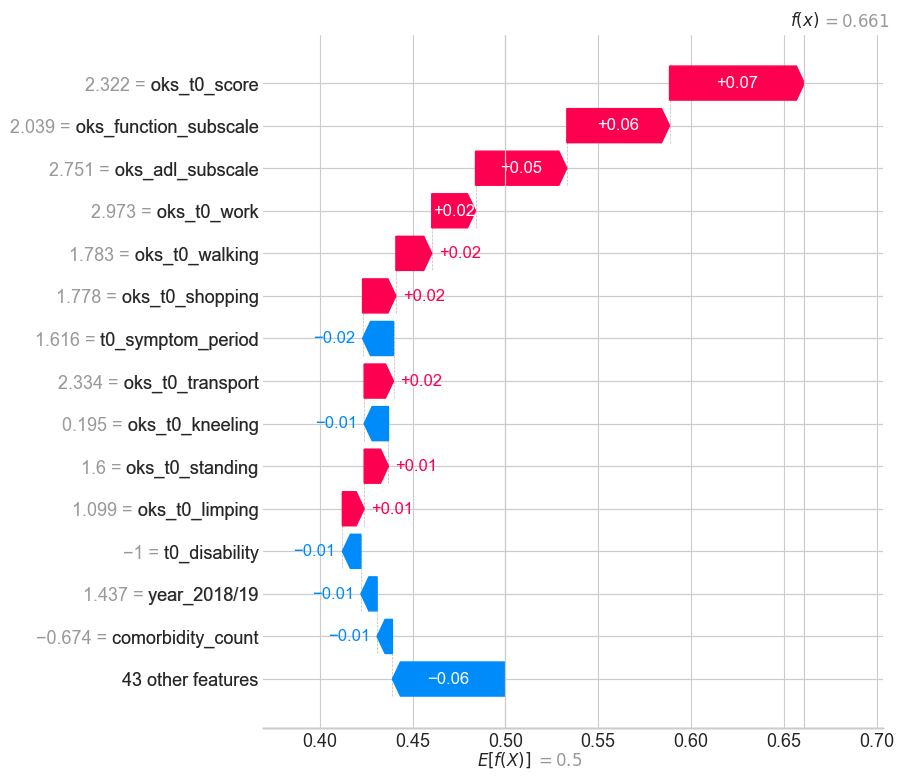


LOCAL EXPLANATION 2: Low-risk patient
  Predicted probability of poor outcome: 0.175
  Actual outcome: Good (0)

Compare with the high-risk patient — notice features point in opposite directions.



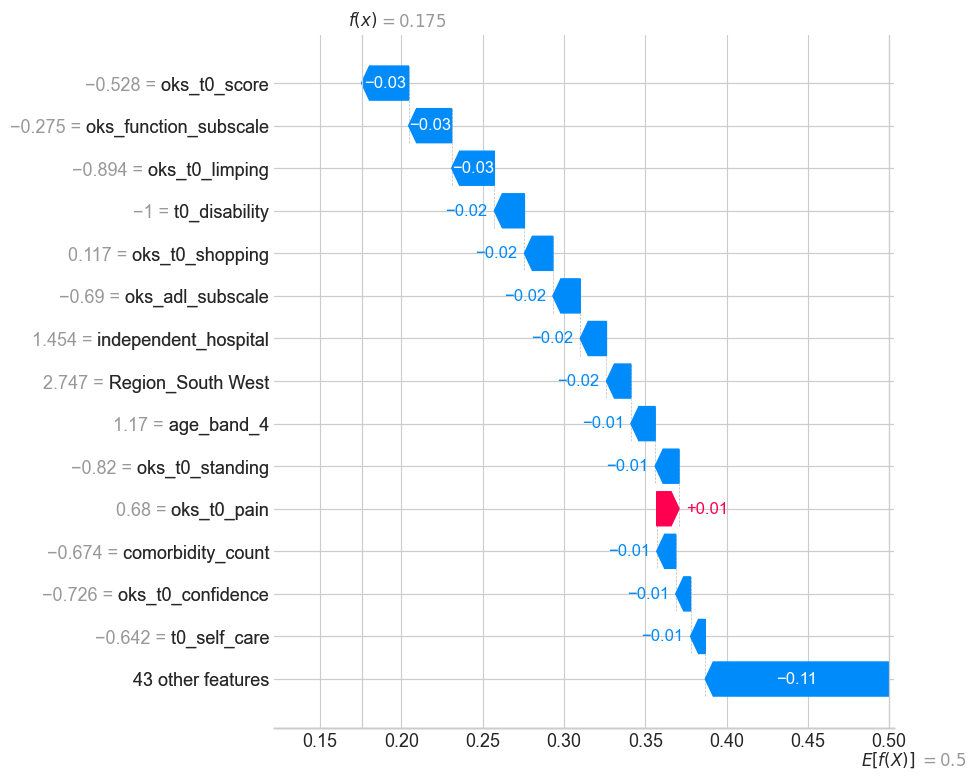

In [66]:
# Step 25c: Local Explanation — Why was THIS patient flagged?
# =============================================================
#
# WATERFALL PLOT
# ---------------
# Zooms in on a single patient and shows step-by-step how the model
# arrived at its prediction.
#
# How to read:
#   • E[f(x)] at the bottom = baseline (average predicted risk across all patients)
#   • Red bars  = feature pushes risk UP
#   • Blue bars = feature pushes risk DOWN
#   • Final value at the top = this patient's predicted probability
#
# We show two patients for contrast:
#   1. A patient flagged as HIGH risk (predicted probability >= 0.8)
#   2. A patient predicted as LOW risk (predicted probability < 0.3)

# Get predicted probabilities for the SHAP sample
proba_shap = best_rf_model.predict_proba(X_test.iloc[sample_idx])[:, 1]

# Find a high-risk and low-risk patient
high_risk_candidates = np.where(proba_shap >= 0.8)[0]
low_risk_candidates  = np.where(proba_shap < 0.3)[0]

if len(high_risk_candidates) == 0:
    high_risk_candidates = [np.argmax(proba_shap)]
if len(low_risk_candidates) == 0:
    low_risk_candidates  = [np.argmin(proba_shap)]

high_risk_idx = high_risk_candidates[0]
low_risk_idx  = low_risk_candidates[0]

def make_single_explanation(idx):
    """Build a single-patient Explanation object for waterfall plot."""
    bv = shap_values.base_values
    # base_values can be: scalar, per-sample array (size=n_patients),
    # or per-class array (size=2). Handle all three cases.
    if np.ndim(bv) == 0:
        base_val = float(bv)                    # scalar
    elif len(bv) == len(shap_values.values):
        base_val = float(bv[idx])               # one value per patient
    else:
        base_val = float(bv[-1])                # per-class array → take last (class 1)
    return shap.Explanation(
        values=shap_values.values[idx],
        base_values=base_val,
        data=shap_values.data[idx],
        feature_names=shap_values.feature_names
    )

print("LOCAL EXPLANATION 1: High-risk patient")
print("=" * 65)
print(f"  Predicted probability of poor outcome: {proba_shap[high_risk_idx]:.3f}")
print(f"  Actual outcome: {'Poor (1)' if y_shap_sample[high_risk_idx] == 1 else 'Good (0)'}")
print("\nHow to read: red bars push risk UP, blue bars push risk DOWN.\n")
shap.plots.waterfall(make_single_explanation(high_risk_idx), max_display=15, show=True)

print("\nLOCAL EXPLANATION 2: Low-risk patient")
print("=" * 65)
print(f"  Predicted probability of poor outcome: {proba_shap[low_risk_idx]:.3f}")
print(f"  Actual outcome: {'Poor (1)' if y_shap_sample[low_risk_idx] == 1 else 'Good (0)'}")
print("\nCompare with the high-risk patient — notice features point in opposite directions.\n")
shap.plots.waterfall(make_single_explanation(low_risk_idx), max_display=15, show=True)

DEPENDENCE PLOTS — Top 3 most influential features
How to read:
  • X-axis: the patient's value for that feature
  • Y-axis: how much it shifted their predicted risk
  • Upward slope = higher values increase risk
  • Colour = value of the interacting feature

Feature: oks_t0_score


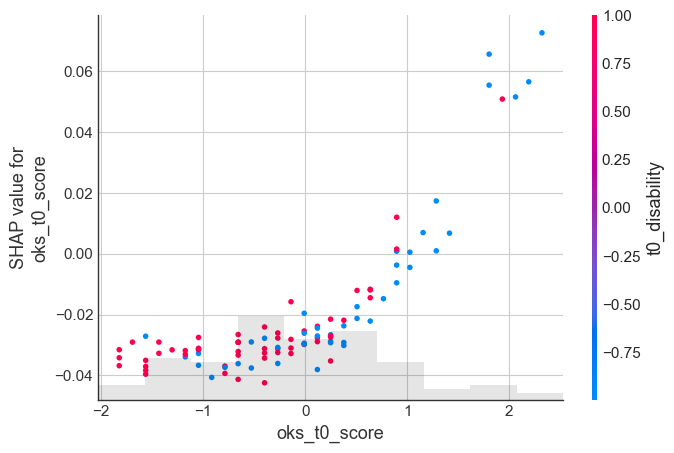


Feature: oks_function_subscale


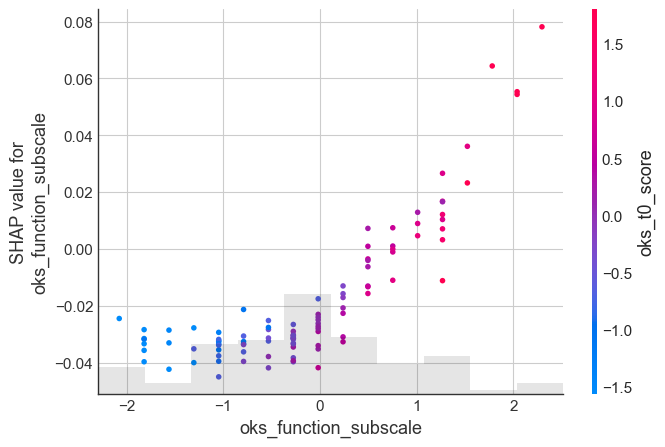


Feature: oks_t0_limping


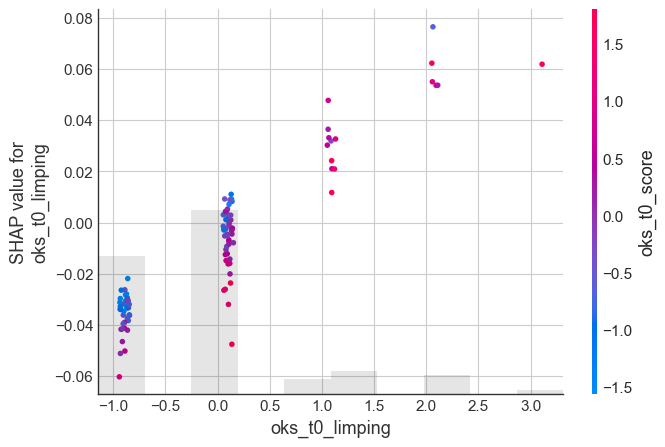



Top 10 features by mean absolute SHAP value
(Higher = feature moves predictions more on average)
                  Feature  Mean |SHAP|
1            oks_t0_score       0.0283
2   oks_function_subscale       0.0271
3          oks_t0_limping       0.0239
4           t0_disability       0.0190
5        oks_adl_subscale       0.0169
6            t0_self_care       0.0142
7             oks_t0_pain       0.0133
8       comorbidity_count       0.0120
9          oks_t0_walking       0.0116
10      oks_pain_subscale       0.0109


In [67]:
# Step 25d: Dependence Plots — How does the top feature relate to risk?
# =======================================================================
#
# A DEPENDENCE PLOT picks one feature and shows:
#   • X-axis: the patient's actual value for that feature
#   • Y-axis: the SHAP value = how much this feature MOVED the prediction
#
# If you see an upward trend: higher values of this feature = more risk
# If you see a downward trend: higher values = less risk
# If you see a curve or a step: the relationship is non-linear
#
# The colour of each dot shows the value of a SECOND feature (automatically
# chosen as the feature that interacts most with the one on the x-axis).
# This reveals interactions: e.g. "age raises risk, but ONLY for patients
# who also have a low OKS score" would show as a colour pattern.

# Get the top 3 features by mean absolute SHAP value
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top3_idx      = np.argsort(mean_abs_shap)[::-1][:3]
top3_features = X_shap_sample.columns[top3_idx].tolist()

print("DEPENDENCE PLOTS — Top 3 most influential features")
print("=" * 65)
print("How to read:")
print("  • X-axis: the patient's value for that feature")
print("  • Y-axis: how much it shifted their predicted risk")
print("  • Upward slope = higher values increase risk")
print("  • Colour = value of the interacting feature\n")

for feat in top3_features:
    print(f"Feature: {feat}")
    shap.plots.scatter(shap_values[:, feat], color=shap_values, show=True)
    print()

# Final summary table: top 10 features ranked by mean |SHAP|
shap_importance = pd.DataFrame({
    'Feature':         X_shap_sample.columns,
    'Mean |SHAP|':     mean_abs_shap.round(4),
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

shap_importance.index += 1  # start ranking from 1
print("\nTop 10 features by mean absolute SHAP value")
print("(Higher = feature moves predictions more on average)")
print("=" * 45)
print(shap_importance.head(10).to_string())

In [68]:
# Step 26a: Set up SHAP — 500 patients
# ======================================
# Same as Step 25a but with 500 patients for more reliable patterns.
# Expected runtime: 5–15 minutes depending on tree depth.

import shap

shap_scaler = best_rf_model.named_steps['scaler']
shap_rf     = best_rf_model.named_steps['model']

X_test_scaled = pd.DataFrame(
    shap_scaler.transform(X_test),
    columns=X_test.columns
)

np.random.seed(0)
sample_idx_500    = np.random.choice(len(X_test_scaled), size=500, replace=False)
X_shap_500        = X_test_scaled.iloc[sample_idx_500]
y_shap_500        = y_test[sample_idx_500]

explainer_500 = shap.TreeExplainer(shap_rf)

print('Computing SHAP values for 500 patients...')
print('This may take 5–15 minutes. Do not interrupt the kernel.')
_sv_500 = explainer_500.shap_values(X_shap_500, check_additivity=False)
_ev_500 = explainer_500.expected_value

if isinstance(_sv_500, list):
    sv_500 = _sv_500[1]
    ev_500 = float(_ev_500[1]) if hasattr(_ev_500, '__len__') else float(_ev_500)
elif hasattr(_sv_500, 'ndim') and _sv_500.ndim == 3:
    if _sv_500.shape[0] == 2:
        sv_500 = _sv_500[1]
        ev_500 = float(_ev_500[1]) if hasattr(_ev_500, '__len__') else float(_ev_500)
    else:
        sv_500 = _sv_500[:, :, 1]
        ev_500 = float(_ev_500[1]) if hasattr(_ev_500, '__len__') else float(_ev_500)
else:
    sv_500 = _sv_500
    ev_500 = float(_ev_500)

shap_values_500 = shap.Explanation(
    values=sv_500,
    base_values=ev_500,
    data=X_shap_500.values,
    feature_names=X_shap_500.columns.tolist()
)

print(f'Done! SHAP values shape: {shap_values_500.values.shape}')
print(f'  => {shap_values_500.values.shape[0]} patients x {shap_values_500.values.shape[1]} features')


Computing SHAP values for 500 patients...
This may take 5–15 minutes. Do not interrupt the kernel.
Done! SHAP values shape: (500, 57)
  => 500 patients x 57 features


PLOT 1: Bar chart — average feature importance across all 500 patients
How to read: Longer bar = feature has more influence on average.



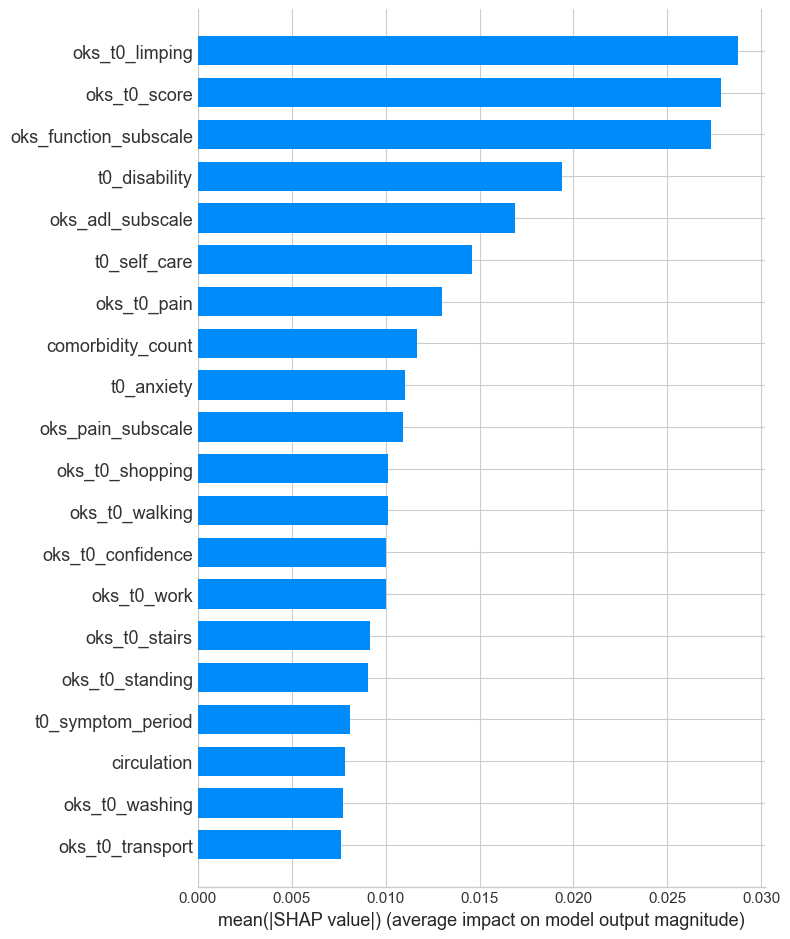


PLOT 2: Beeswarm plot — how each feature's value affects risk
How to read:
  • Each dot = one patient
  • X-axis: negative = lowers risk, positive = raises risk
  • Colour:  red = high feature value, blue = low feature value



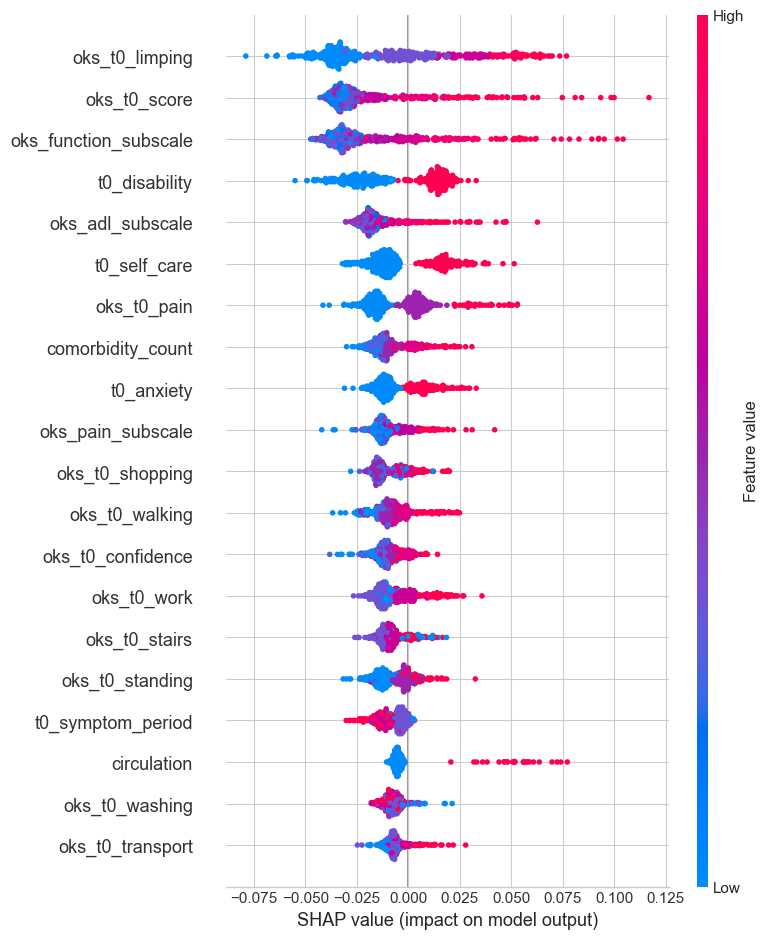

In [69]:
# Step 26b: Global Importance — Bar Chart and Beeswarm (500 patients)
# =====================================================================

print("PLOT 1: Bar chart — average feature importance across all 500 patients")
print("=" * 65)
print("How to read: Longer bar = feature has more influence on average.\n")

shap.summary_plot(shap_values_500.values, X_shap_500,
                  plot_type='bar', max_display=20, show=True)

print("\nPLOT 2: Beeswarm plot — how each feature's value affects risk")
print("=" * 65)
print("How to read:")
print("  • Each dot = one patient")
print("  • X-axis: negative = lowers risk, positive = raises risk")
print("  • Colour:  red = high feature value, blue = low feature value\n")

shap.summary_plot(shap_values_500.values, X_shap_500,
                  max_display=20, show=True)


LOCAL EXPLANATION 1: High-risk patient
  Predicted probability: 0.965
  Actual outcome: Poor (1)

Red bars = push risk UP, blue bars = push risk DOWN.



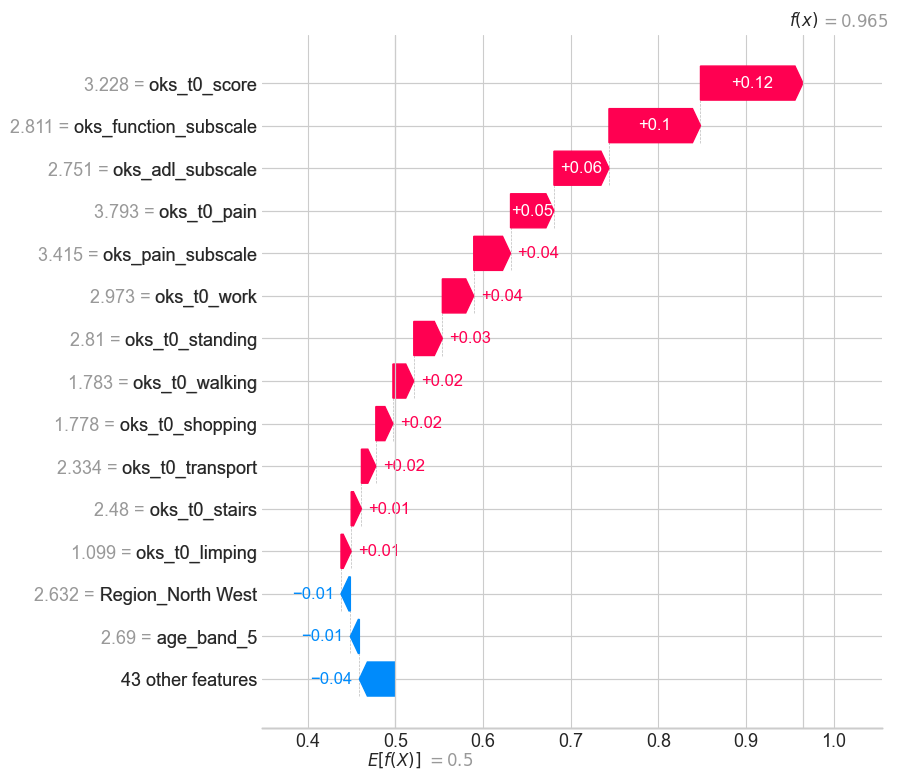


LOCAL EXPLANATION 2: Low-risk patient
  Predicted probability: 0.239
  Actual outcome: Good (0)

Compare with the high-risk patient above.



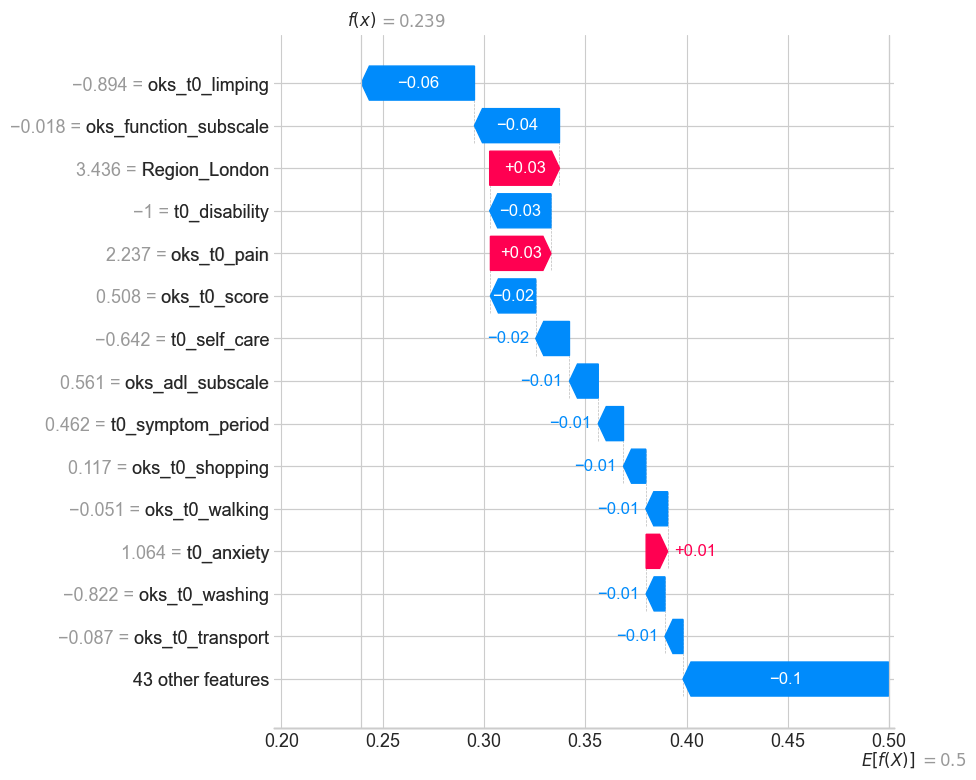

In [70]:
# Step 26c: Local Explanation — Waterfall plots (500 patients)
# =============================================================

proba_shap_500 = best_rf_model.predict_proba(X_test.iloc[sample_idx_500])[:, 1]

high_risk_candidates = np.where(proba_shap_500 >= 0.8)[0]
low_risk_candidates  = np.where(proba_shap_500 < 0.3)[0]

if len(high_risk_candidates) == 0:
    high_risk_candidates = [np.argmax(proba_shap_500)]
if len(low_risk_candidates) == 0:
    low_risk_candidates  = [np.argmin(proba_shap_500)]

high_risk_idx = high_risk_candidates[0]
low_risk_idx  = low_risk_candidates[0]

def make_explanation_500(idx):
    bv = shap_values_500.base_values
    if np.ndim(bv) == 0:
        base_val = float(bv)
    elif len(bv) == len(shap_values_500.values):
        base_val = float(bv[idx])
    else:
        base_val = float(bv[-1])
    return shap.Explanation(
        values=shap_values_500.values[idx],
        base_values=base_val,
        data=shap_values_500.data[idx],
        feature_names=shap_values_500.feature_names
    )

print("LOCAL EXPLANATION 1: High-risk patient")
print("=" * 65)
print(f"  Predicted probability: {proba_shap_500[high_risk_idx]:.3f}")
print(f"  Actual outcome: {'Poor (1)' if y_shap_500[high_risk_idx] == 1 else 'Good (0)'}")
print("\nRed bars = push risk UP, blue bars = push risk DOWN.\n")
shap.plots.waterfall(make_explanation_500(high_risk_idx), max_display=15, show=True)

print("\nLOCAL EXPLANATION 2: Low-risk patient")
print("=" * 65)
print(f"  Predicted probability: {proba_shap_500[low_risk_idx]:.3f}")
print(f"  Actual outcome: {'Poor (1)' if y_shap_500[low_risk_idx] == 1 else 'Good (0)'}")
print("\nCompare with the high-risk patient above.\n")
shap.plots.waterfall(make_explanation_500(low_risk_idx), max_display=15, show=True)


DEPENDENCE PLOTS — Top 3 most influential features (500 patients)
  • X-axis: patient's value for that feature
  • Y-axis: how much it shifted their predicted risk
  • Upward slope = higher values increase risk

Feature: oks_t0_limping


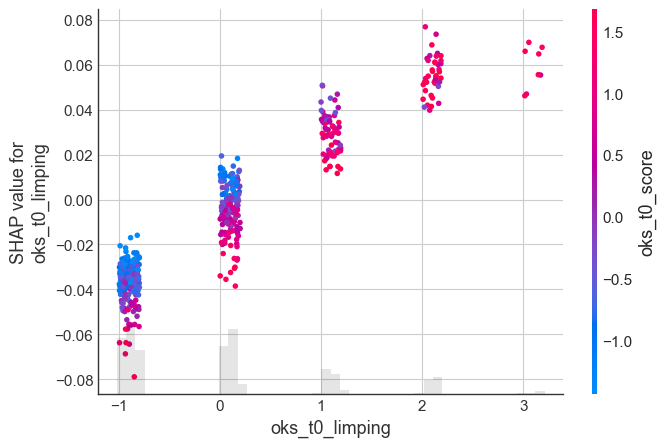


Feature: oks_t0_score


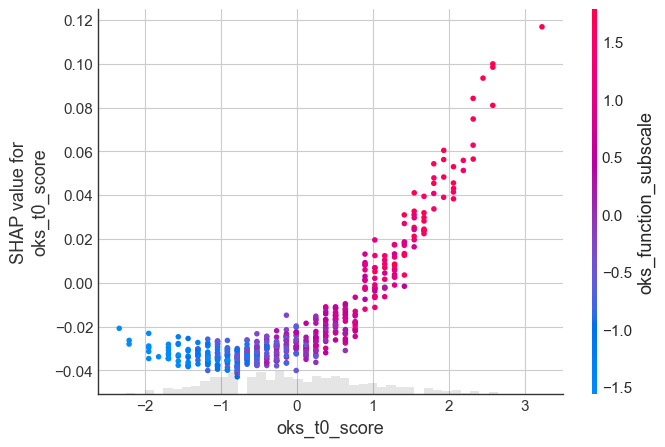


Feature: oks_function_subscale


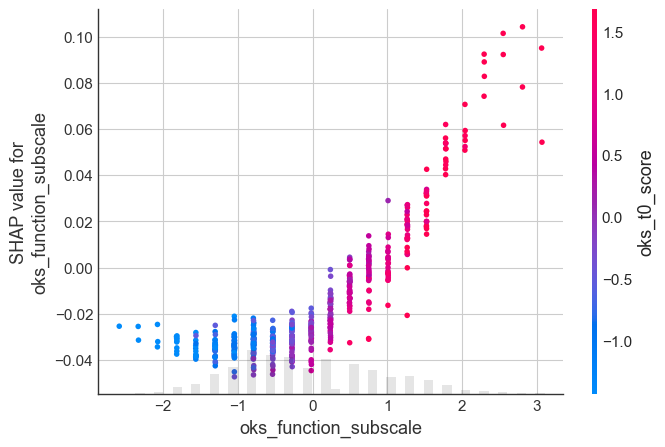



Top 10 features by mean absolute SHAP value (500 patients)
                  Feature  Mean |SHAP|
1          oks_t0_limping       0.0288
2            oks_t0_score       0.0278
3   oks_function_subscale       0.0273
4           t0_disability       0.0194
5        oks_adl_subscale       0.0169
6            t0_self_care       0.0146
7             oks_t0_pain       0.0130
8       comorbidity_count       0.0117
9              t0_anxiety       0.0111
10      oks_pain_subscale       0.0109


In [71]:
# Step 26d: Dependence Plots — Top 3 features (500 patients)
# ===========================================================

mean_abs_shap_500 = np.abs(shap_values_500.values).mean(axis=0)
top3_idx          = np.argsort(mean_abs_shap_500)[::-1][:3]
top3_features     = X_shap_500.columns[top3_idx].tolist()

print("DEPENDENCE PLOTS — Top 3 most influential features (500 patients)")
print("=" * 65)
print("  • X-axis: patient's value for that feature")
print("  • Y-axis: how much it shifted their predicted risk")
print("  • Upward slope = higher values increase risk\n")

for feat in top3_features:
    print(f"Feature: {feat}")
    shap.plots.scatter(shap_values_500[:, feat], color=shap_values_500, show=True)
    print()

shap_importance_500 = pd.DataFrame({
    'Feature':     X_shap_500.columns,
    'Mean |SHAP|': mean_abs_shap_500.round(4),
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)
shap_importance_500.index += 1

print("\nTop 10 features by mean absolute SHAP value (500 patients)")
print("=" * 45)
print(shap_importance_500.head(10).to_string())
